# **COMPREHENSIVE MODEL TRAINING WITH BALANCED DATA**


## **0. Library import**


In [1]:
import os
import sys

# Add the root path into the python path
root_path = os.path.abspath(os.path.join(".."))
if not root_path in sys.path:
    sys.path.insert(0, root_path)

In [2]:
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

from src.config import LOG_DIR, \
    RANDOM_OVER_SAMPLING_DATA_FILE_PATH, SMOTE_DATA_FILE_PATH, ADASYN_DATA_FILE_PATH, \
    RANDOM_UNDER_SAMPLING_DATA_FILE_PATH, TOMEK_LINKS_DATA_FILE_PATH, EDITED_NEIGHBORS_DATA_FILE_PATH, \
    SMOTE_TOMEK_LINKS_DATA_FILE_PATH, SMOTE_ENN_DATA_FILE_PATH, ADASYN_TOMEK_DATA_FILE_PATH, \
    TESTING_DATA_FILE_PATH, RANDOM_STATE, N_JOBS, \
    SGD_ALPHA, SGD_MAX_ITER, SGD_LOSS, SGD_PENALTY, SGD_LEARNING_RATE, \
    LR_C, LR_PENALTY, LR_CLASS_WEIGHT, LR_VERBOSE, LR_MAX_ITER, LR_SOLVER, \
    RF_N_ESTIMATORS, RF_MAX_DEPTH, RF_MIN_SAMPLES_SPLIT, RF_MIN_SAMPLES_LEAF, RF_CLASS_WEIGHT, \
    NB_ALPHA, NB_TYPE, NB_BINARIZE, NB_VAR_SMOOTHING, \
    XGB_N_ESTIMATORS, XGB_MAX_DEPTH, XGB_LEARNING_RATE, XGB_SUBSAMPLE, XGB_COLSAMPLE_BY_TREE, \
    LGBM_N_ESTIMATORS, LGBM_MAX_DEPTH, LGBM_LEARNING_RATE, LGBM_NUM_LEAVES, LGBM_SUBSAMPLE, LGBM_COLSAMPLE_BY_TREE, \
    BEST_ACCURACY_MODEL_FILE_PATH, BEST_ACCURACY_MODEL_SCALER_FILE_PATH, \
    BEST_F1_MODEL_FILE_PATH, BEST_F1_MODEL_SCALER_FILE_PATH, \
    BEST_PRECISION_MODEL_FILE_PATH, BEST_PRECISION_MODEL_SCALER_FILE_PATH, \
    BEST_RECALL_MODEL_FILE_PATH, BEST_RECALL_MODEL_SCALER_FILE_PATH
from src.utils import load_data, save_data
from src.visualization import plot_roc_auc, plot_compare_models
from src.evaluate import compare_models
from src.models import (
    DiabetesSGDClassifier, DiabetesLogisticRegression, 
    DiabetesRandomForest, DiabetesNaiveBayes, 
    DiabetesXGBoostClassifier, DiabetesLightGBMClassifier
)

## **1. Data preparation**

### **1.1 Load balanced datasets**

In [3]:
# Load all 6 balanced datasets
ros_data = load_data(path=RANDOM_OVER_SAMPLING_DATA_FILE_PATH)
smote_data = load_data(path=SMOTE_DATA_FILE_PATH)
adasyn_data = load_data(path=ADASYN_DATA_FILE_PATH)
rus_data = load_data(path=RANDOM_UNDER_SAMPLING_DATA_FILE_PATH)
tomek_data = load_data(path=TOMEK_LINKS_DATA_FILE_PATH)
enn_data = load_data(path=EDITED_NEIGHBORS_DATA_FILE_PATH)
smote_tomek_data = load_data(path=SMOTE_TOMEK_LINKS_DATA_FILE_PATH)
smote_enn_data = load_data(path=SMOTE_ENN_DATA_FILE_PATH)
adasyn_tomek_data = load_data(path=ADASYN_TOMEK_DATA_FILE_PATH)

### **1.2 Split features and target**

In [4]:
# Split features and target of each dataset
# Random Oversampling
ros_X_train = ros_data["X"]
ros_y_train = ros_data["y"]
# SMOTE
smote_X_train = smote_data["X"]
smote_y_train = smote_data["y"]
# ADASYN
adasyn_X_train = adasyn_data["X"]
adasyn_y_train = adasyn_data["y"]
# Random Undersampling
rus_X_train = rus_data["X"]
rus_y_train = rus_data["y"]
# Tomek Links
tomek_X_train = tomek_data["X"]
tomek_y_train = tomek_data["y"]
# Edited Nearest Neighbors
enn_X_train = enn_data["X"]
enn_y_train = enn_data["y"]
# SMOTE + Tomek Links
smote_tomek_X_train = smote_tomek_data["X"]
smote_tomek_y_train = smote_tomek_data["y"]
# SMOTE + ENN
smote_enn_X_train = smote_enn_data["X"]
smote_enn_y_train = smote_enn_data["y"]
# ADASYN + Tomek Links
adasyn_tomek_X_train = adasyn_tomek_data["X"]
adasyn_tomek_y_train = adasyn_tomek_data["y"]

In [5]:
# Load testing data
test_data = load_data(path=TESTING_DATA_FILE_PATH)

# Get testing features and target
X_test = test_data["X"]
y_test = test_data["y"]

### **1.3 Normalize features for each dataset**

In [6]:
# Initialize MinMaxScaler for each dataset
ros_scaler = MinMaxScaler()
smote_scaler = MinMaxScaler()
adasyn_scaler = MinMaxScaler()
rus_scaler = MinMaxScaler()
tomek_scaler = MinMaxScaler()
enn_scaler = MinMaxScaler()
smote_tomek_scaler = MinMaxScaler()
smote_enn_scaler = MinMaxScaler()
adasyn_tomek_scaler = MinMaxScaler()

In [7]:
def normalize_data(scaler, X_train, X_test):
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_train.columns)
    return X_train_scaled, X_test_scaled

In [8]:
# Transform dataset
ros_X_train_scaled, ros_X_test_scaled = normalize_data(ros_scaler, ros_X_train, X_test)
smote_X_train_scaled, smote_X_test_scaled = normalize_data(smote_scaler, smote_X_train, X_test)
adasyn_X_train_scaled, adasyn_X_test_scaled = normalize_data(adasyn_scaler, adasyn_X_train, X_test)
rus_X_train_scaled, rus_X_test_scaled = normalize_data(rus_scaler, rus_X_train, X_test)
tomek_X_train_scaled, tomek_X_test_scaled = normalize_data(tomek_scaler, tomek_X_train, X_test)
enn_X_train_scaled, enn_X_test_scaled = normalize_data(enn_scaler, enn_X_train, X_test)
smote_tomek_X_train_scaled, smote_tomek_X_test_scaled = normalize_data(smote_tomek_scaler, smote_tomek_X_train, X_test)
smote_enn_X_train_scaled, smote_enn_X_test_scaled = normalize_data(smote_enn_scaler, smote_enn_X_train, X_test)
adasyn_tomek_X_train_scaled, adasyn_tomek_X_test_scaled = normalize_data(adasyn_tomek_scaler, adasyn_tomek_X_train, X_test)

## **2. Model training by balancing method**

In [9]:
def train_evaluate_all_models(X_train, y_train, X_test, y_test, method_name):
    """
    Train and evaluate all 4 models on the given balanced dataset

    Parameters:
        X_train (np.ndarray): Training features
        y_train (np.ndarray): Training target
        X_test (np.ndarray): Testing features
        y_test (np.ndarray): Testing target
        method_name (str): Name of the balancing method

    Returns:
        results (dict): The evaluation results
        models (dict): The model's names and models
    """
    lowercase_method_name = method_name.lower().replace(" ", "_")
    log_file_path = f"{LOG_DIR}/5_model_training_with_enhanced_data.log"
    cv_scores = {}
    probabilities = {}

    # Initialize all models
    sgd_model = DiabetesSGDClassifier(
        loss=SGD_LOSS,
        penalty=SGD_PENALTY,
        alpha=SGD_ALPHA,
        max_iter=SGD_MAX_ITER,
        random_state=RANDOM_STATE,
        learning_rate=SGD_LEARNING_RATE,
        n_jobs=N_JOBS,
        logger_name=f"{lowercase_method_name}.sgd_classifier", 
        log_file=log_file_path,
    )
    lr_model = DiabetesLogisticRegression(
        C=LR_C,
        penalty=LR_PENALTY,
        class_weight=LR_CLASS_WEIGHT,
        max_iter=LR_MAX_ITER,
        solver=LR_SOLVER,
        random_state=RANDOM_STATE,
        verbose=LR_VERBOSE,
        n_jobs=N_JOBS, 
        logger_name=f"{lowercase_method_name}.logistic_regression", 
        log_file=log_file_path
    )
    nb_model = DiabetesNaiveBayes(
        nb_type=NB_TYPE,
        var_smoothing=NB_VAR_SMOOTHING,
        binarize=NB_BINARIZE,
        alpha=NB_ALPHA, 
        logger_name=f"{lowercase_method_name}.naive_bayes", 
        log_file=log_file_path,
    )
    rf_model = DiabetesRandomForest(
        n_estimators=RF_N_ESTIMATORS,
        max_depth=RF_MAX_DEPTH,
        min_samples_split=RF_MIN_SAMPLES_SPLIT,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF,
        class_weight=RF_CLASS_WEIGHT,
        random_state=RANDOM_STATE, 
        logger_name=f"{lowercase_method_name}.random_forest", 
        log_file=log_file_path,
    )
    xgb_model = DiabetesXGBoostClassifier(
        n_estimators=XGB_N_ESTIMATORS, 
        max_depth=XGB_MAX_DEPTH, 
        learning_rate=XGB_LEARNING_RATE, 
        subsample=XGB_SUBSAMPLE, 
        colsample_bytree=XGB_COLSAMPLE_BY_TREE, 
        logger_name=f"{lowercase_method_name}.xgboost", 
        log_file=log_file_path,
    )
    lgbm_model = DiabetesLightGBMClassifier(
        n_estimators=LGBM_N_ESTIMATORS, 
        max_depth=LGBM_MAX_DEPTH, 
        learning_rate=LGBM_LEARNING_RATE, 
        num_leaves=LGBM_NUM_LEAVES, 
        subsample=LGBM_SUBSAMPLE, 
        colsample_bytree=LGBM_COLSAMPLE_BY_TREE, 
        logger_name=f"{lowercase_method_name}.lightgbm", 
        log_file=log_file_path, 
    )

    model_dict = {
        "SGDClassifier": sgd_model,
        "LogisticRegression": lr_model,
        "NaiveBayes": nb_model,
        "RandomForest": rf_model,
        "XGBoost": xgb_model, 
        "LightGBM": lgbm_model, 
    }

    # Train and evaluate each model
    for name, model in model_dict.items():
        print(f"Training {name} on {method_name} data...")

        # Train
        model.train(X=X_train, y=y_train)

        # Predict and evaluate
        y_pred = model.predict(X_test)
        model.evaluate(y_test, y_pred)

        # Get class probabilites
        probabilities[name] = model.predict_proba(X_test)

        # Cross-validation
        cv_result = model.cross_validate(X_train, y_train)
        cv_scores[name] = {
            'cv_mean': cv_result.mean(),
            'cv_std': cv_result.std()
        }

    # Get evaluation comparation results
    evaluation_results = compare_models(
        models_dict=model_dict,
        X_test=X_test,
        y_true=y_test
    )

    # Convert cv_scores dict to DataFrame
    cv_df = pd.DataFrame.from_dict(cv_scores, orient='index').reset_index()
    cv_df.columns = ['Model', 'CV Mean', 'CV Std']

    # Merge into evaluation results
    evaluation_results = pd.merge(evaluation_results, cv_df, on='Model', how='left')

    return evaluation_results, probabilities, model_dict

### **2.1 Random Oversampling**

In [10]:
# Train and get evaluation results with the Random OVersampling method
ros_evaluation_results, ros_class_probabilities, ros_models = train_evaluate_all_models(
    X_train=ros_X_train_scaled, 
    y_train=ros_y_train, 
    X_test=ros_X_test_scaled, 
    y_test=y_test, 
    method_name="Random Oversampling"
)

2025-09-27 21:29:51,758 - [random_oversampling.sgd_classifier] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-09-27 21:29:51,759 - [random_oversampling.sgd_classifier] - INFO -   loss: log_loss
2025-09-27 21:29:51,759 - [random_oversampling.sgd_classifier] - INFO -   penalty: l2
2025-09-27 21:29:51,760 - [random_oversampling.sgd_classifier] - INFO -   alpha: 0.0001
2025-09-27 21:29:51,761 - [random_oversampling.sgd_classifier] - INFO -   learning_rate: constant
2025-09-27 21:29:51,762 - [random_oversampling.sgd_classifier] - INFO -   eta0: 0.01
2025-09-27 21:29:51,763 - [random_oversampling.sgd_classifier] - INFO -   max_iter: 1000
2025-09-27 21:29:51,764 - [random_oversampling.sgd_classifier] - INFO -   random_state: 42
2025-09-27 21:29:51,767 - [random_oversampling.logistic_regression] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-09-27 21:29:51,769 - [random_oversampling.logistic_regression] - INFO -   C: 1.0
2025-09-27 21:29:51,772 - [rando

Training SGDClassifier on Random Oversampling data...


2025-09-27 21:29:53,127 - [random_oversampling.sgd_classifier] - INFO - Model training completed. Training samples: 433416
2025-09-27 21:29:53,128 - [random_oversampling.sgd_classifier] - INFO - Number of iterations: 7
2025-09-27 21:29:53,143 - [random_oversampling.sgd_classifier] - INFO - Predictions made for 89841 samples
2025-09-27 21:29:53,177 - [random_oversampling.sgd_classifier] - INFO - Model Evaluation Results:
2025-09-27 21:29:53,177 - [random_oversampling.sgd_classifier] - INFO - Accuracy: 0.8288
2025-09-27 21:29:53,178 - [random_oversampling.sgd_classifier] - INFO - Precision: 0.5353
2025-09-27 21:29:53,179 - [random_oversampling.sgd_classifier] - INFO - Recall: 0.4627
2025-09-27 21:29:53,180 - [random_oversampling.sgd_classifier] - INFO - F1-Score: 0.4798
2025-09-27 21:29:53,284 - [random_oversampling.sgd_classifier] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.95      0.90     70854
         1.0     

Training LogisticRegression on Random Oversampling data...


2025-09-27 21:31:15,538 - [random_oversampling.logistic_regression] - INFO - Model training completed. Training samples: 433416
2025-09-27 21:31:15,550 - [random_oversampling.logistic_regression] - INFO - Predictions made for 89841 samples
2025-09-27 21:31:15,580 - [random_oversampling.logistic_regression] - INFO - Model Evaluation Results:
2025-09-27 21:31:15,584 - [random_oversampling.logistic_regression] - INFO - Accuracy: 0.8218
2025-09-27 21:31:15,589 - [random_oversampling.logistic_regression] - INFO - Precision: 0.6041
2025-09-27 21:31:15,590 - [random_oversampling.logistic_regression] - INFO - Recall: 0.4745
2025-09-27 21:31:15,591 - [random_oversampling.logistic_regression] - INFO - F1-Score: 0.4828
2025-09-27 21:31:15,656 - [random_oversampling.logistic_regression] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.93      0.90     70854
         1.0       0.36      0.01      0.02      2397
         2.0       

...

2025-09-27 21:40:24,186 - [random_oversampling.xgboost] - INFO - Model training completed. Training samples: 433416
2025-09-27 21:40:24,388 - [random_oversampling.xgboost] - INFO - Predictions made for 89841 samples
2025-09-27 21:40:24,426 - [random_oversampling.xgboost] - INFO - Model Evaluation Results:
2025-09-27 21:40:24,427 - [random_oversampling.xgboost] - INFO - Accuracy: 0.8947
2025-09-27 21:40:24,428 - [random_oversampling.xgboost] - INFO - Precision: 0.7715
2025-09-27 21:40:24,430 - [random_oversampling.xgboost] - INFO - Recall: 0.6542
2025-09-27 21:40:24,431 - [random_oversampling.xgboost] - INFO - F1-Score: 0.6969
2025-09-27 21:40:24,469 - [random_oversampling.xgboost] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94     70854
         1.0       0.59      0.31      0.41      2397
         2.0       0.81      0.69      0.74     16590

    accuracy                           0.89     89841
   mac

Training LightGBM on Random Oversampling data...
[LightGBM] [Info] Total Bins 467
[LightGBM] [Info] Number of data points in the train set: 433416, number of used features: 33
[LightGBM] [Info] Start training from score -0.424782
[LightGBM] [Info] Start training from score -2.159675
[LightGBM] [Info] Start training from score -1.466528


2025-09-27 21:41:14,469 - [random_oversampling.lightgbm] - INFO - Model training completed. Training samples: 433416
2025-09-27 21:41:15,190 - [random_oversampling.lightgbm] - INFO - Predictions made for 89841 samples
2025-09-27 21:41:15,234 - [random_oversampling.lightgbm] - INFO - Model Evaluation Results:
2025-09-27 21:41:15,235 - [random_oversampling.lightgbm] - INFO - Accuracy: 0.8937
2025-09-27 21:41:15,236 - [random_oversampling.lightgbm] - INFO - Precision: 0.7571
2025-09-27 21:41:15,237 - [random_oversampling.lightgbm] - INFO - Recall: 0.6576
2025-09-27 21:41:15,239 - [random_oversampling.lightgbm] - INFO - F1-Score: 0.6954
2025-09-27 21:41:15,284 - [random_oversampling.lightgbm] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94     70854
         1.0       0.55      0.32      0.40      2397
         2.0       0.80      0.69      0.74     16590

    accuracy                           0.89     8984

[LightGBM] [Info] Total Bins 469
[LightGBM] [Info] Number of data points in the train set: 346732, number of used features: 33
[LightGBM] [Info] Start training from score -0.424783
[LightGBM] [Info] Start training from score -2.159673
[LightGBM] [Info] Start training from score -1.466526
[LightGBM] [Info] Total Bins 467
[LightGBM] [Info] Number of data points in the train set: 346733, number of used features: 33
[LightGBM] [Info] Start training from score -0.424782
[LightGBM] [Info] Start training from score -2.159676
[LightGBM] [Info] Start training from score -1.466528
[LightGBM] [Info] Total Bins 466
[LightGBM] [Info] Number of data points in the train set: 346733, number of used features: 33
[LightGBM] [Info] Start training from score -0.424782
[LightGBM] [Info] Start training from score -2.159676
[LightGBM] [Info] Start training from score -1.466528
[LightGBM] [Info] Total Bins 467
[LightGBM] [Info] Number of data points in the train set: 346733, number of used features: 33
[Light

2025-09-27 21:41:51,563 - [random_oversampling.lightgbm] - INFO - Cross-validation results:
2025-09-27 21:41:51,565 - [random_oversampling.lightgbm] - INFO - Mean accuracy: 0.8300 (+/- 0.0013)
2025-09-27 21:41:51,585 - [random_oversampling.sgd_classifier] - INFO - Predictions made for 89841 samples
2025-09-27 21:41:51,641 - [random_oversampling.sgd_classifier] - INFO - Probabilities predicted for 89841 samples
2025-09-27 21:41:51,874 - [random_oversampling.logistic_regression] - INFO - Predictions made for 89841 samples
2025-09-27 21:41:51,899 - [random_oversampling.logistic_regression] - INFO - Probabilities predicted for 89841 samples
2025-09-27 21:41:52,142 - [random_oversampling.naive_bayes] - INFO - Predictions made for 89841 samples
2025-09-27 21:41:52,201 - [random_oversampling.naive_bayes] - INFO - Probabilities predicted for 89841 samples
2025-09-27 21:41:54,210 - [random_oversampling.random_forest] - INFO - Predictions made for 89841 samples
2025-09-27 21:41:55,932 - [random_

In [11]:
# The evaluation result of all models with the Random Oversampling method
ros_evaluation_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2,CV Mean,CV Std
0,SGDClassifier,0.8288,0.5353,0.4627,0.4798,0.7956,0.8574,0.1023,0.6461,0.9522,0.0167,0.4191,0.9023,0.0287,0.5084,0.720043,0.001015
1,LogisticRegression,0.8218,0.6041,0.4745,0.4828,0.7988,0.8656,0.3647,0.5820,0.9287,0.0129,0.4820,0.8961,0.0250,0.5273,0.720273,0.000950
2,NaiveBayes,0.7315,0.4679,0.5095,0.4788,0.7662,0.8892,0.0675,0.4470,0.7835,0.1519,0.5933,0.8330,0.0934,0.5099,0.665234,0.000904
3,RandomForest,0.8318,0.5899,0.6800,0.6213,0.9073,0.9532,0.2081,0.6083,0.8486,0.3642,0.8272,0.8979,0.2649,0.7011,0.854680,0.001415
4,XGBoost,0.8947,0.7715,0.6542,0.6969,0.9235,0.9160,0.5890,0.8095,0.9632,0.3133,0.6861,0.9390,0.4090,0.7427,0.826437,0.000672
5,LightGBM,0.8937,0.7571,0.6576,0.6954,0.9234,0.9183,0.5533,0.7998,0.9597,0.3183,0.6947,0.9385,0.4041,0.7436,0.829979,0.000668


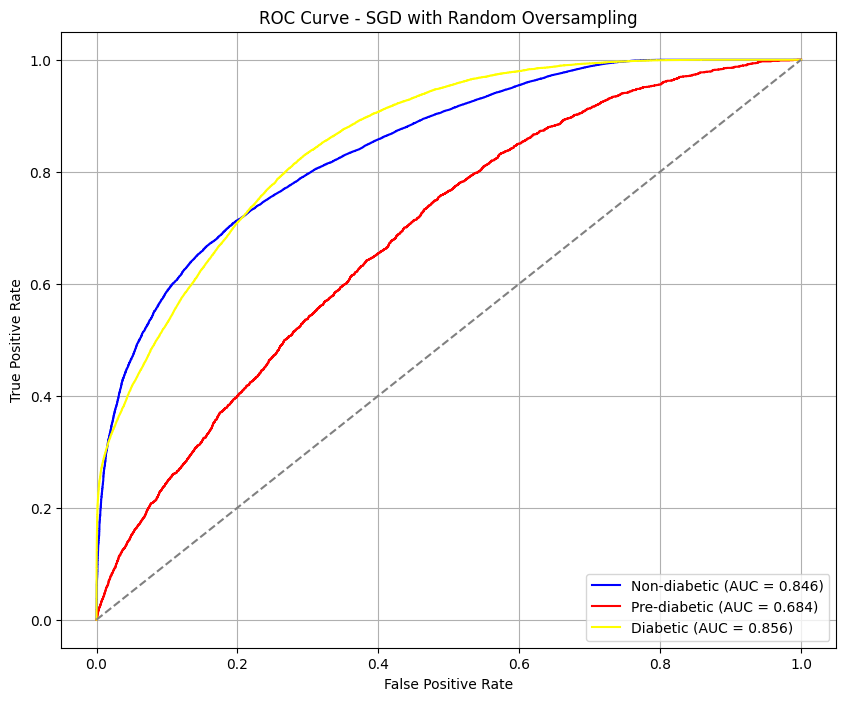

In [12]:
# Plot ROC and AUC of SGD model with Random Oversampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=ros_class_probabilities["SGDClassifier"],
    model_name="SGD with Random Oversampling"
)

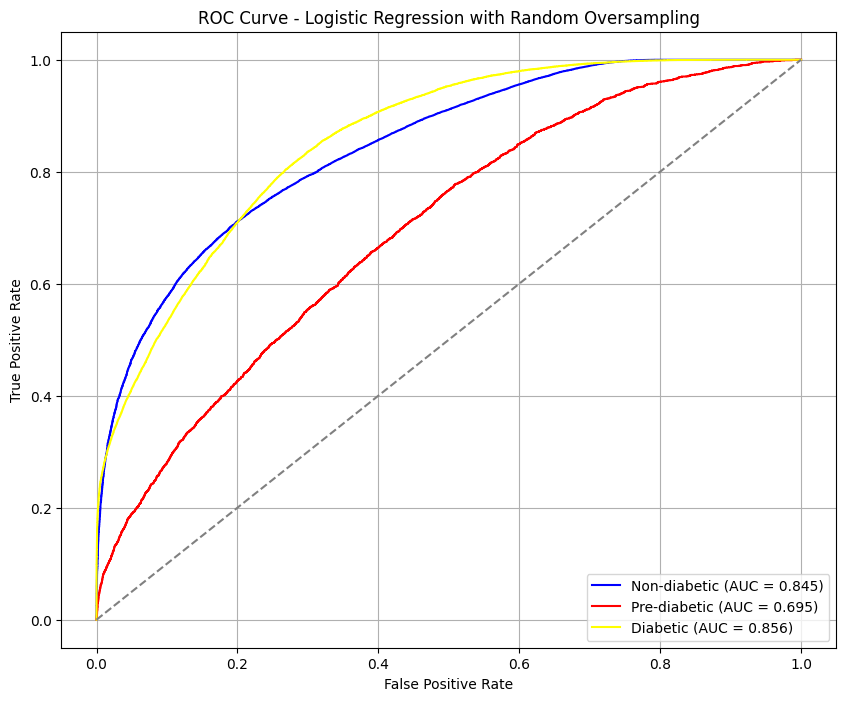

In [13]:
# Plot ROC and AUC of Logistic Regression model with Random Oversampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=ros_class_probabilities["LogisticRegression"],
    model_name="Logistic Regression with Random Oversampling"
)

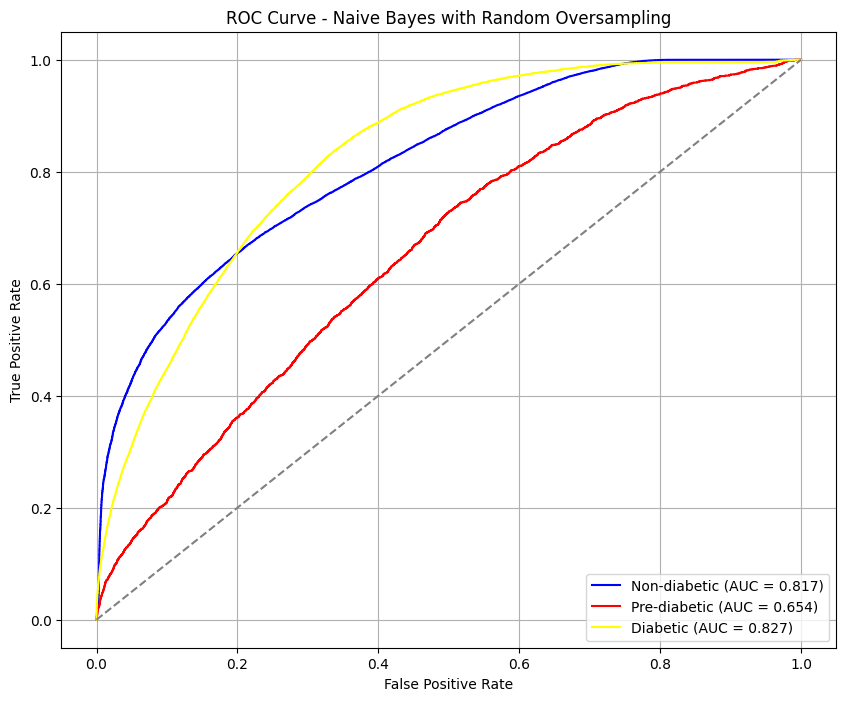

In [14]:
# Plot ROC and AUC of Naive Bayes model with Random Oversampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=ros_class_probabilities["NaiveBayes"],
    model_name="Naive Bayes with Random Oversampling"
)

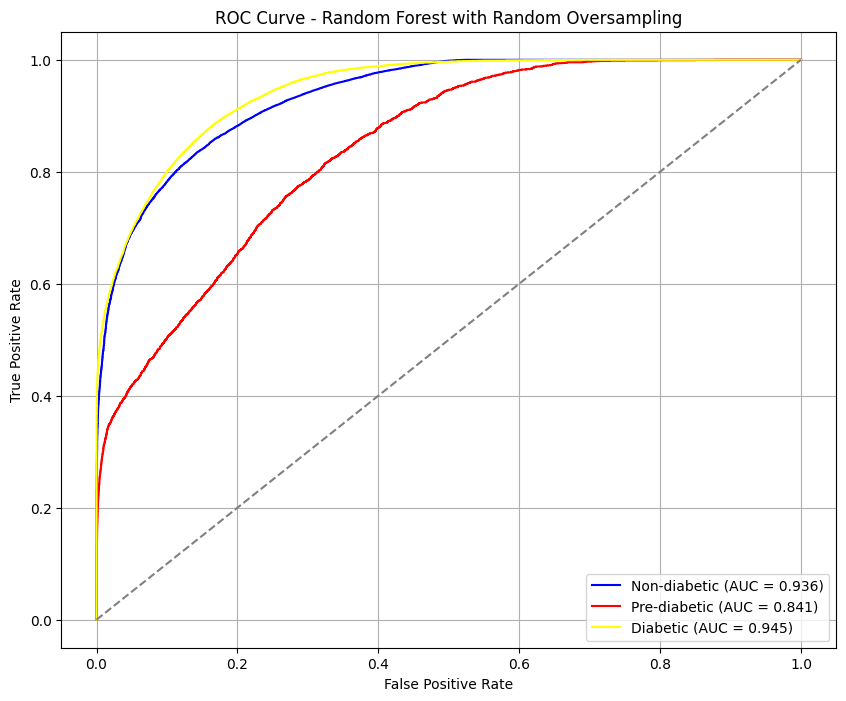

In [15]:
# Plot ROC and AUC of Random Forest model with Random Oversampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=ros_class_probabilities["RandomForest"],
    model_name="Random Forest with Random Oversampling"
)

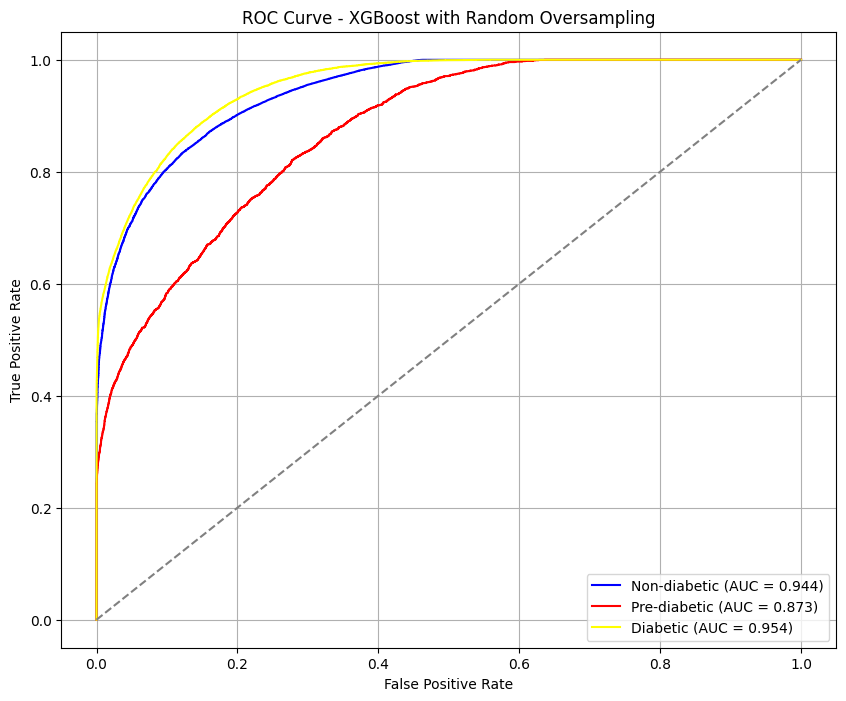

In [16]:
# Plot ROC and AUC of XGBoost model with Random Oversampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=ros_class_probabilities["XGBoost"],
    model_name="XGBoost with Random Oversampling"
)

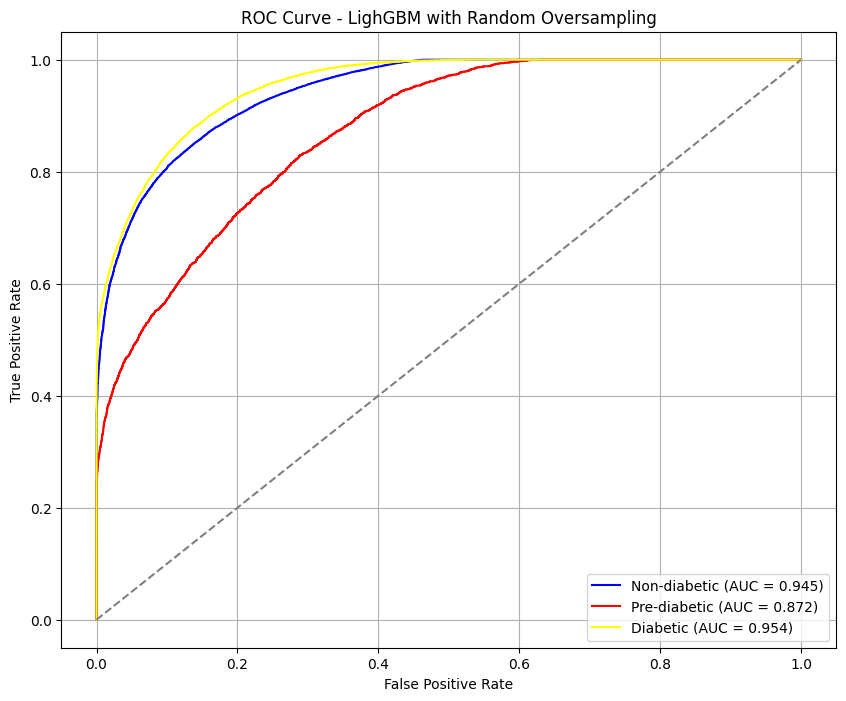

In [17]:
# Plot ROC and AUC of LightGBM model with Random Oversampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=ros_class_probabilities["LightGBM"],
    model_name="LighGBM with Random Oversampling"
)

### **2.2 SMOTE**

In [18]:
# Train and get evaluation results with the SMOTE method
smote_evaluation_results, smote_class_probabilities, smote_models = train_evaluate_all_models(
    X_train=smote_X_train_scaled, 
    y_train=smote_y_train, 
    X_test=smote_X_test_scaled, 
    y_test=y_test, 
    method_name="SMOTE"
)

2025-09-27 21:41:59,970 - [smote.sgd_classifier] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-09-27 21:41:59,972 - [smote.sgd_classifier] - INFO -   loss: log_loss
2025-09-27 21:41:59,972 - [smote.sgd_classifier] - INFO -   penalty: l2
2025-09-27 21:41:59,973 - [smote.sgd_classifier] - INFO -   alpha: 0.0001
2025-09-27 21:41:59,974 - [smote.sgd_classifier] - INFO -   learning_rate: constant
2025-09-27 21:41:59,975 - [smote.sgd_classifier] - INFO -   eta0: 0.01
2025-09-27 21:41:59,976 - [smote.sgd_classifier] - INFO -   max_iter: 1000
2025-09-27 21:41:59,977 - [smote.sgd_classifier] - INFO -   random_state: 42
2025-09-27 21:41:59,978 - [smote.logistic_regression] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-09-27 21:41:59,979 - [smote.logistic_regression] - INFO -   C: 1.0
2025-09-27 21:41:59,980 - [smote.logistic_regression] - INFO -   penalty: l2
2025-09-27 21:41:59,981 - [smote.logistic_regression] - INFO -   class_weight: None
2025-09-27 

Training SGDClassifier on SMOTE data...


2025-09-27 21:42:01,792 - [smote.sgd_classifier] - INFO - Model training completed. Training samples: 433416
2025-09-27 21:42:01,793 - [smote.sgd_classifier] - INFO - Number of iterations: 7
2025-09-27 21:42:01,805 - [smote.sgd_classifier] - INFO - Predictions made for 89841 samples
2025-09-27 21:42:01,860 - [smote.sgd_classifier] - INFO - Model Evaluation Results:
2025-09-27 21:42:01,861 - [smote.sgd_classifier] - INFO - Accuracy: 0.8222
2025-09-27 21:42:01,862 - [smote.sgd_classifier] - INFO - Precision: 0.5281
2025-09-27 21:42:01,862 - [smote.sgd_classifier] - INFO - Recall: 0.4720
2025-09-27 21:42:01,863 - [smote.sgd_classifier] - INFO - F1-Score: 0.4902
2025-09-27 21:42:01,923 - [smote.sgd_classifier] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.94      0.90     70854
         1.0       0.10      0.05      0.06      2397
         2.0       0.62      0.43      0.51     16590

    accuracy                      

Training LogisticRegression on SMOTE data...


2025-09-27 21:43:27,643 - [smote.logistic_regression] - INFO - Model training completed. Training samples: 433416
2025-09-27 21:43:27,652 - [smote.logistic_regression] - INFO - Predictions made for 89841 samples
2025-09-27 21:43:27,683 - [smote.logistic_regression] - INFO - Model Evaluation Results:
2025-09-27 21:43:27,684 - [smote.logistic_regression] - INFO - Accuracy: 0.8211
2025-09-27 21:43:27,686 - [smote.logistic_regression] - INFO - Precision: 0.5916
2025-09-27 21:43:27,686 - [smote.logistic_regression] - INFO - Recall: 0.4763
2025-09-27 21:43:27,687 - [smote.logistic_regression] - INFO - F1-Score: 0.4839
2025-09-27 21:43:27,721 - [smote.logistic_regression] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.93      0.90     70854
         1.0       0.33      0.01      0.03      2397
         2.0       0.58      0.49      0.53     16590

    accuracy                           0.82     89841
   macro avg       0.5

...

2025-09-27 21:54:18,180 - [smote.xgboost] - INFO - Model training completed. Training samples: 433416
2025-09-27 21:54:18,330 - [smote.xgboost] - INFO - Predictions made for 89841 samples
2025-09-27 21:54:18,369 - [smote.xgboost] - INFO - Model Evaluation Results:
2025-09-27 21:54:18,370 - [smote.xgboost] - INFO - Accuracy: 0.8995
2025-09-27 21:54:18,370 - [smote.xgboost] - INFO - Precision: 0.8970
2025-09-27 21:54:18,372 - [smote.xgboost] - INFO - Recall: 0.6252
2025-09-27 21:54:18,373 - [smote.xgboost] - INFO - F1-Score: 0.6874
2025-09-27 21:54:18,410 - [smote.xgboost] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.98      0.94     70854
         1.0       0.94      0.24      0.38      2397
         2.0       0.84      0.66      0.74     16590

    accuracy                           0.90     89841
   macro avg       0.90      0.63      0.69     89841
weighted avg       0.90      0.90      0.89     89841

2025-09-2

Training LightGBM on SMOTE data...
[LightGBM] [Info] Total Bins 8412
[LightGBM] [Info] Number of data points in the train set: 433416, number of used features: 33
[LightGBM] [Info] Start training from score -0.424782
[LightGBM] [Info] Start training from score -2.159675
[LightGBM] [Info] Start training from score -1.466528


2025-09-27 21:55:05,256 - [smote.lightgbm] - INFO - Model training completed. Training samples: 433416
2025-09-27 21:55:06,199 - [smote.lightgbm] - INFO - Predictions made for 89841 samples
2025-09-27 21:55:06,237 - [smote.lightgbm] - INFO - Model Evaluation Results:
2025-09-27 21:55:06,238 - [smote.lightgbm] - INFO - Accuracy: 0.9008
2025-09-27 21:55:06,239 - [smote.lightgbm] - INFO - Precision: 0.9120
2025-09-27 21:55:06,239 - [smote.lightgbm] - INFO - Recall: 0.6250
2025-09-27 21:55:06,240 - [smote.lightgbm] - INFO - F1-Score: 0.6904
2025-09-27 21:55:06,282 - [smote.lightgbm] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.98      0.94     70854
         1.0       0.97      0.24      0.39      2397
         2.0       0.86      0.65      0.74     16590

    accuracy                           0.90     89841
   macro avg       0.91      0.63      0.69     89841
weighted avg       0.90      0.90      0.89     89841

2

[LightGBM] [Info] Total Bins 8413
[LightGBM] [Info] Number of data points in the train set: 346732, number of used features: 33
[LightGBM] [Info] Start training from score -0.424783
[LightGBM] [Info] Start training from score -2.159673
[LightGBM] [Info] Start training from score -1.466526
[LightGBM] [Info] Total Bins 8412
[LightGBM] [Info] Number of data points in the train set: 346733, number of used features: 33
[LightGBM] [Info] Start training from score -0.424782
[LightGBM] [Info] Start training from score -2.159676
[LightGBM] [Info] Start training from score -1.466528
[LightGBM] [Info] Total Bins 8413
[LightGBM] [Info] Number of data points in the train set: 346733, number of used features: 33
[LightGBM] [Info] Start training from score -0.424782
[LightGBM] [Info] Start training from score -2.159676
[LightGBM] [Info] Start training from score -1.466528
[LightGBM] [Info] Total Bins 8411
[LightGBM] [Info] Number of data points in the train set: 346733, number of used features: 33
[L

2025-09-27 21:55:48,878 - [smote.lightgbm] - INFO - Cross-validation results:
2025-09-27 21:55:48,879 - [smote.lightgbm] - INFO - Mean accuracy: 0.8793 (+/- 0.0586)
2025-09-27 21:55:48,896 - [smote.sgd_classifier] - INFO - Predictions made for 89841 samples
2025-09-27 21:55:48,916 - [smote.sgd_classifier] - INFO - Probabilities predicted for 89841 samples
2025-09-27 21:55:49,192 - [smote.logistic_regression] - INFO - Predictions made for 89841 samples
2025-09-27 21:55:49,218 - [smote.logistic_regression] - INFO - Probabilities predicted for 89841 samples
2025-09-27 21:55:49,458 - [smote.naive_bayes] - INFO - Predictions made for 89841 samples
2025-09-27 21:55:49,514 - [smote.naive_bayes] - INFO - Probabilities predicted for 89841 samples
2025-09-27 21:55:51,750 - [smote.random_forest] - INFO - Predictions made for 89841 samples
2025-09-27 21:55:53,943 - [smote.random_forest] - INFO - Probabilities predicted for 89841 samples
2025-09-27 21:55:54,264 - [smote.xgboost] - INFO - Prediction

In [19]:
# The evaluation result of all models with the SMOTE method
smote_evaluation_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2,CV Mean,CV Std
0,SGDClassifier,0.8222,0.5281,0.4720,0.4902,0.7945,0.8620,0.0998,0.6224,0.9401,0.0451,0.4307,0.8994,0.0621,0.5091,0.720073,0.002554
1,LogisticRegression,0.8211,0.5916,0.4763,0.4839,0.7983,0.8668,0.3300,0.5779,0.9261,0.0138,0.4889,0.8955,0.0264,0.5297,0.721388,0.001643
2,NaiveBayes,0.7090,0.4676,0.5105,0.4697,0.7603,0.9014,0.0542,0.4472,0.7601,0.2082,0.5631,0.8247,0.0860,0.4985,0.648636,0.006194
3,RandomForest,0.8627,0.7215,0.6577,0.6632,0.9085,0.9427,0.5937,0.6281,0.8928,0.2591,0.8212,0.9171,0.3607,0.7118,0.849971,0.027584
4,XGBoost,0.8995,0.8970,0.6252,0.6874,0.9209,0.9088,0.9391,0.8432,0.9781,0.2382,0.6591,0.9422,0.3800,0.7399,0.866613,0.023851
5,LightGBM,0.9008,0.9120,0.6250,0.6904,0.9232,0.9071,0.9699,0.8589,0.9814,0.2420,0.6518,0.9428,0.3873,0.7411,0.879289,0.029311


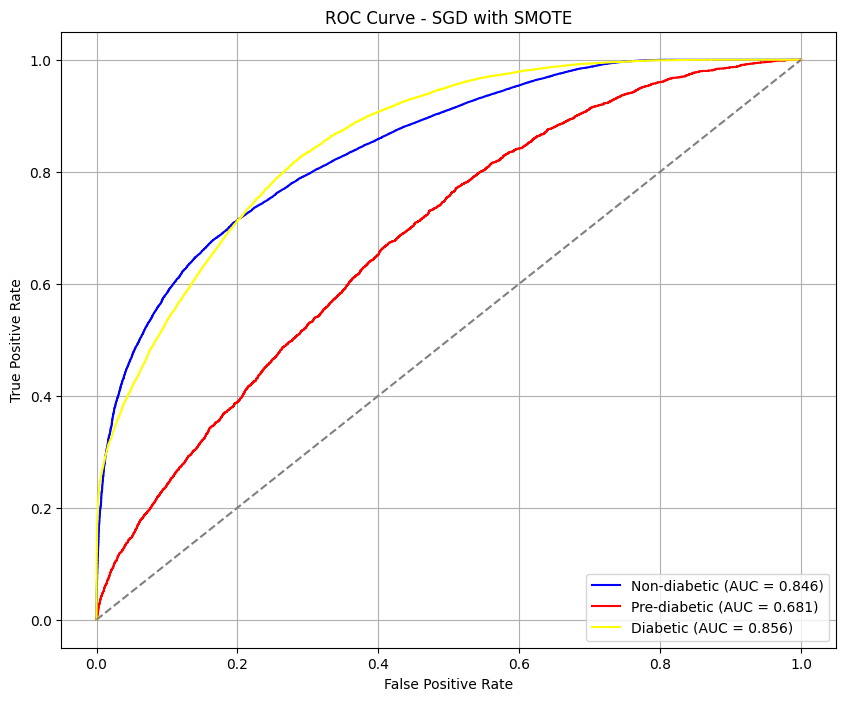

In [20]:
# Plot ROC and AUC of SGD model with SMOTE method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_class_probabilities["SGDClassifier"],
    model_name="SGD with SMOTE"
)

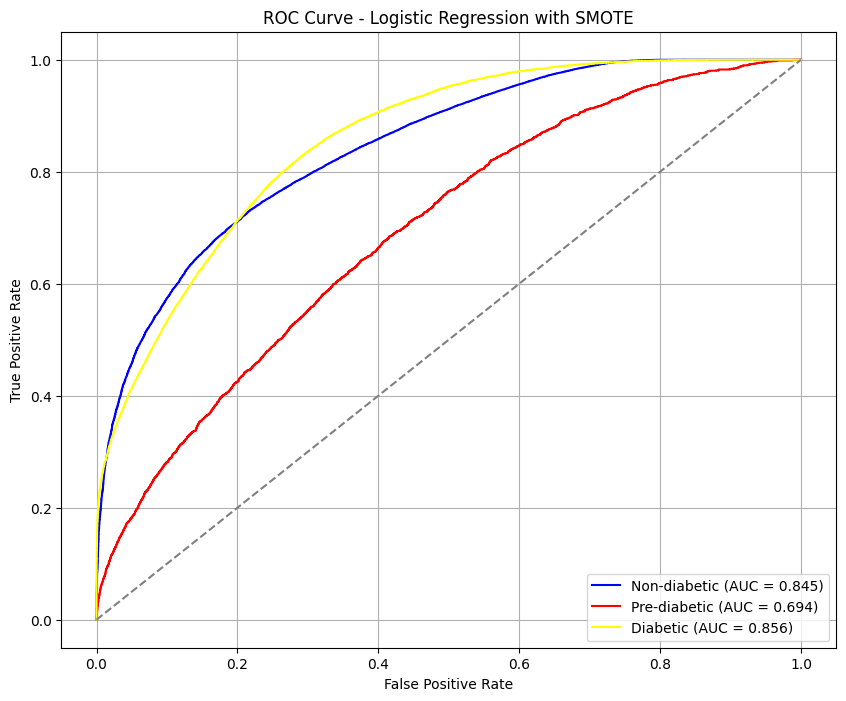

In [21]:
# Plot ROC and AUC of Logistic Regression model with SMOTE method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_class_probabilities["LogisticRegression"],
    model_name="Logistic Regression with SMOTE"
)

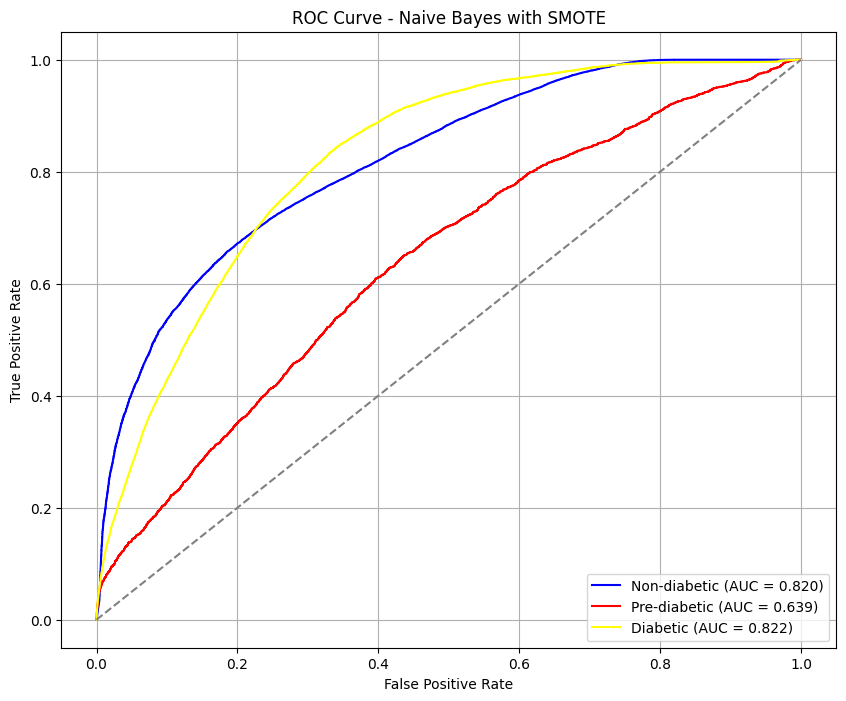

In [22]:
# Plot ROC and AUC of Naive Bayes model with SMOTE method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_class_probabilities["NaiveBayes"],
    model_name="Naive Bayes with SMOTE"
)

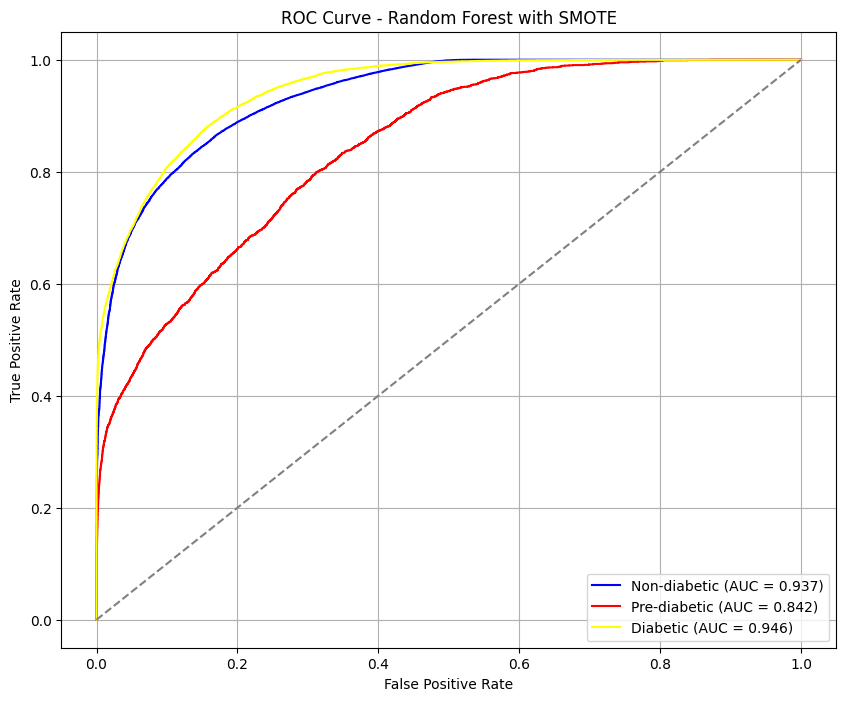

In [23]:
# Plot ROC and AUC of Random Forest model with SMOTE method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_class_probabilities["RandomForest"],
    model_name="Random Forest with SMOTE"
)

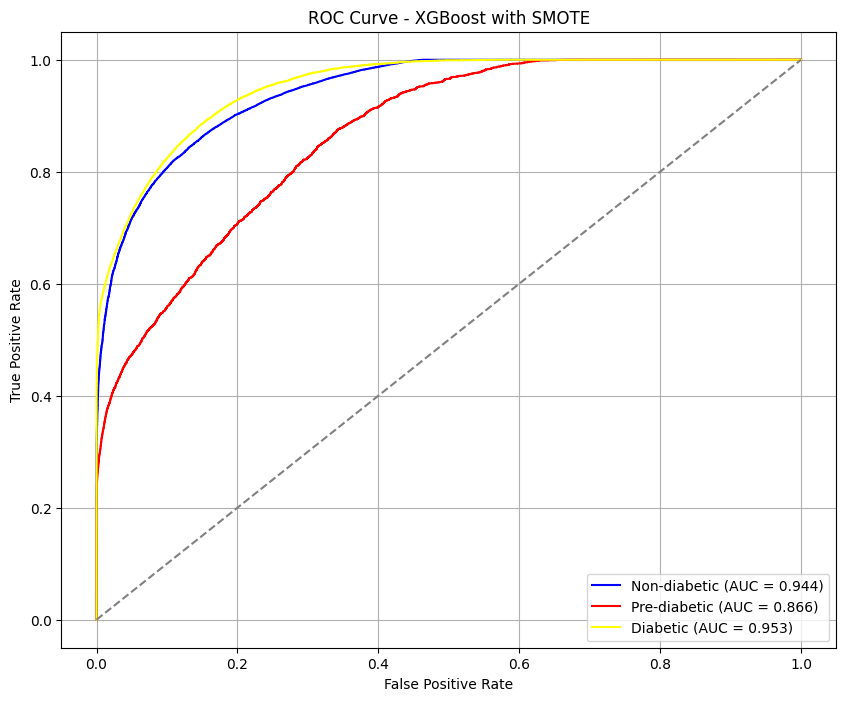

In [24]:
# Plot ROC and AUC of XGBoost model with SMOTE method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_class_probabilities["XGBoost"],
    model_name="XGBoost with SMOTE"
)

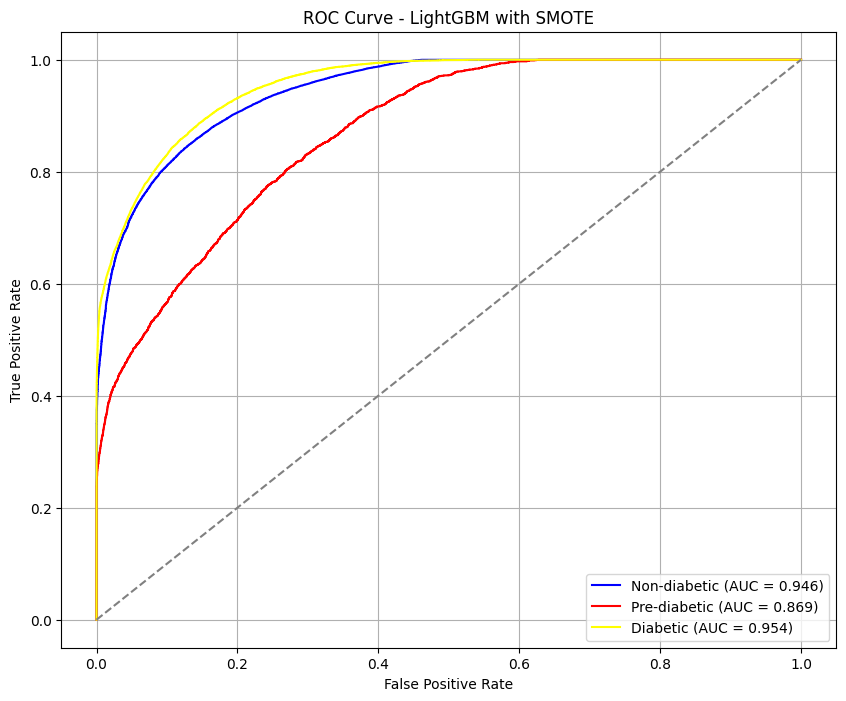

In [25]:
# Plot ROC and AUC of LightGBM model with SMOTE method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_class_probabilities["LightGBM"],
    model_name="LightGBM with SMOTE"
)

### **2.3 ADASYN**

In [26]:
# Train and get evaluation results with the ADASYN method
adasyn_evaluation_results, adasyn_class_probabilities, adasyn_models = train_evaluate_all_models(
    X_train=adasyn_X_train_scaled, 
    y_train=adasyn_y_train, 
    X_test=adasyn_X_test_scaled, 
    y_test=y_test, 
    method_name="ADASYN"
)

2025-09-27 21:55:59,090 - [adasyn.sgd_classifier] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-09-27 21:55:59,092 - [adasyn.sgd_classifier] - INFO -   loss: log_loss
2025-09-27 21:55:59,092 - [adasyn.sgd_classifier] - INFO -   penalty: l2
2025-09-27 21:55:59,093 - [adasyn.sgd_classifier] - INFO -   alpha: 0.0001
2025-09-27 21:55:59,095 - [adasyn.sgd_classifier] - INFO -   learning_rate: constant
2025-09-27 21:55:59,097 - [adasyn.sgd_classifier] - INFO -   eta0: 0.01
2025-09-27 21:55:59,098 - [adasyn.sgd_classifier] - INFO -   max_iter: 1000
2025-09-27 21:55:59,099 - [adasyn.sgd_classifier] - INFO -   random_state: 42
2025-09-27 21:55:59,100 - [adasyn.logistic_regression] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-09-27 21:55:59,101 - [adasyn.logistic_regression] - INFO -   C: 1.0
2025-09-27 21:55:59,102 - [adasyn.logistic_regression] - INFO -   penalty: l2
2025-09-27 21:55:59,103 - [adasyn.logistic_regression] - INFO -   class_weight: None

Training SGDClassifier on ADASYN data...


2025-09-27 21:56:00,675 - [adasyn.sgd_classifier] - INFO - Model training completed. Training samples: 429230
2025-09-27 21:56:00,676 - [adasyn.sgd_classifier] - INFO - Number of iterations: 7
2025-09-27 21:56:00,689 - [adasyn.sgd_classifier] - INFO - Predictions made for 89841 samples
2025-09-27 21:56:00,742 - [adasyn.sgd_classifier] - INFO - Model Evaluation Results:
2025-09-27 21:56:00,743 - [adasyn.sgd_classifier] - INFO - Accuracy: 0.8198
2025-09-27 21:56:00,745 - [adasyn.sgd_classifier] - INFO - Precision: 0.6136
2025-09-27 21:56:00,748 - [adasyn.sgd_classifier] - INFO - Recall: 0.4726
2025-09-27 21:56:00,750 - [adasyn.sgd_classifier] - INFO - F1-Score: 0.4755
2025-09-27 21:56:00,799 - [adasyn.sgd_classifier] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.92      0.89     70854
         1.0       0.40      0.00      0.00      2397
         2.0       0.57      0.49      0.53     16590

    accuracy             

Training LogisticRegression on ADASYN data...


2025-09-27 21:57:20,205 - [adasyn.logistic_regression] - INFO - Model training completed. Training samples: 429230
2025-09-27 21:57:20,217 - [adasyn.logistic_regression] - INFO - Predictions made for 89841 samples
2025-09-27 21:57:20,248 - [adasyn.logistic_regression] - INFO - Model Evaluation Results:
2025-09-27 21:57:20,250 - [adasyn.logistic_regression] - INFO - Accuracy: 0.8176
2025-09-27 21:57:20,250 - [adasyn.logistic_regression] - INFO - Precision: 0.5839
2025-09-27 21:57:20,251 - [adasyn.logistic_regression] - INFO - Recall: 0.4768
2025-09-27 21:57:20,252 - [adasyn.logistic_regression] - INFO - F1-Score: 0.4795
2025-09-27 21:57:20,289 - [adasyn.logistic_regression] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.92      0.89     70854
         1.0       0.32      0.01      0.01      2397
         2.0       0.56      0.51      0.53     16590

    accuracy                           0.82     89841
   macro avg  

...

2025-09-27 22:08:22,130 - [adasyn.xgboost] - INFO - Model training completed. Training samples: 429230
2025-09-27 22:08:22,395 - [adasyn.xgboost] - INFO - Predictions made for 89841 samples
2025-09-27 22:08:22,444 - [adasyn.xgboost] - INFO - Model Evaluation Results:
2025-09-27 22:08:22,445 - [adasyn.xgboost] - INFO - Accuracy: 0.8989
2025-09-27 22:08:22,446 - [adasyn.xgboost] - INFO - Precision: 0.8929
2025-09-27 22:08:22,447 - [adasyn.xgboost] - INFO - Recall: 0.6271
2025-09-27 22:08:22,448 - [adasyn.xgboost] - INFO - F1-Score: 0.6875
2025-09-27 22:08:22,485 - [adasyn.xgboost] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.98      0.94     70854
         1.0       0.94      0.24      0.38      2397
         2.0       0.83      0.67      0.74     16590

    accuracy                           0.90     89841
   macro avg       0.89      0.63      0.69     89841
weighted avg       0.90      0.90      0.89     89841

2

Training LightGBM on ADASYN data...
[LightGBM] [Info] Total Bins 8360
[LightGBM] [Info] Number of data points in the train set: 429230, number of used features: 33
[LightGBM] [Info] Start training from score -0.415077
[LightGBM] [Info] Start training from score -2.162974
[LightGBM] [Info] Start training from score -1.492864


2025-09-27 22:09:18,805 - [adasyn.lightgbm] - INFO - Model training completed. Training samples: 429230
2025-09-27 22:09:19,696 - [adasyn.lightgbm] - INFO - Predictions made for 89841 samples
2025-09-27 22:09:19,734 - [adasyn.lightgbm] - INFO - Model Evaluation Results:
2025-09-27 22:09:19,735 - [adasyn.lightgbm] - INFO - Accuracy: 0.9012
2025-09-27 22:09:19,736 - [adasyn.lightgbm] - INFO - Precision: 0.9159
2025-09-27 22:09:19,737 - [adasyn.lightgbm] - INFO - Recall: 0.6244
2025-09-27 22:09:19,740 - [adasyn.lightgbm] - INFO - F1-Score: 0.6902
2025-09-27 22:09:19,780 - [adasyn.lightgbm] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.98      0.94     70854
         1.0       0.98      0.24      0.39      2397
         2.0       0.86      0.65      0.74     16590

    accuracy                           0.90     89841
   macro avg       0.92      0.62      0.69     89841
weighted avg       0.90      0.90      0.89     

[LightGBM] [Info] Total Bins 8375
[LightGBM] [Info] Number of data points in the train set: 343384, number of used features: 33
[LightGBM] [Info] Start training from score -0.415081
[LightGBM] [Info] Start training from score -2.162954
[LightGBM] [Info] Start training from score -1.492864
[LightGBM] [Info] Total Bins 8367
[LightGBM] [Info] Number of data points in the train set: 343384, number of used features: 33
[LightGBM] [Info] Start training from score -0.415076
[LightGBM] [Info] Start training from score -2.162979
[LightGBM] [Info] Start training from score -1.492864
[LightGBM] [Info] Total Bins 8368
[LightGBM] [Info] Number of data points in the train set: 343384, number of used features: 33
[LightGBM] [Info] Start training from score -0.415076
[LightGBM] [Info] Start training from score -2.162979
[LightGBM] [Info] Start training from score -1.492864
[LightGBM] [Info] Total Bins 8346
[LightGBM] [Info] Number of data points in the train set: 343384, number of used features: 33
[L

2025-09-27 22:10:01,700 - [adasyn.lightgbm] - INFO - Cross-validation results:
2025-09-27 22:10:01,701 - [adasyn.lightgbm] - INFO - Mean accuracy: 0.8676 (+/- 0.0489)
2025-09-27 22:10:01,723 - [adasyn.sgd_classifier] - INFO - Predictions made for 89841 samples
2025-09-27 22:10:01,743 - [adasyn.sgd_classifier] - INFO - Probabilities predicted for 89841 samples
2025-09-27 22:10:01,977 - [adasyn.logistic_regression] - INFO - Predictions made for 89841 samples
2025-09-27 22:10:02,001 - [adasyn.logistic_regression] - INFO - Probabilities predicted for 89841 samples
2025-09-27 22:10:02,240 - [adasyn.naive_bayes] - INFO - Predictions made for 89841 samples
2025-09-27 22:10:02,294 - [adasyn.naive_bayes] - INFO - Probabilities predicted for 89841 samples
2025-09-27 22:10:04,158 - [adasyn.random_forest] - INFO - Predictions made for 89841 samples
2025-09-27 22:10:05,686 - [adasyn.random_forest] - INFO - Probabilities predicted for 89841 samples
2025-09-27 22:10:05,889 - [adasyn.xgboost] - INFO -

In [27]:
# The evaluation result of all models with the ADASYN method
adasyn_evaluation_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2,CV Mean,CV Std
0,SGDClassifier,0.8198,0.6136,0.4726,0.4755,0.7862,0.8659,0.4000,0.5749,0.9240,0.0008,0.4931,0.8940,0.0017,0.5309,0.704149,0.022464
1,LogisticRegression,0.8176,0.5839,0.4768,0.4795,0.7973,0.8684,0.3200,0.5634,0.9180,0.0067,0.5055,0.8925,0.0131,0.5329,0.702954,0.021886
2,NaiveBayes,0.6818,0.4669,0.5145,0.4615,0.7562,0.9181,0.0482,0.4346,0.7206,0.2432,0.5796,0.8074,0.0804,0.4967,0.618820,0.023639
3,RandomForest,0.8526,0.7109,0.6574,0.6551,0.9083,0.9470,0.5868,0.5990,0.8753,0.2553,0.8415,0.9098,0.3558,0.6998,0.827188,0.034673
4,XGBoost,0.8989,0.8929,0.6271,0.6875,0.9207,0.9103,0.9362,0.8321,0.9755,0.2386,0.6670,0.9418,0.3803,0.7405,0.852110,0.021911
5,LightGBM,0.9012,0.9159,0.6244,0.6902,0.9233,0.9069,0.9779,0.8630,0.9823,0.2403,0.6505,0.9431,0.3858,0.7418,0.867591,0.024457


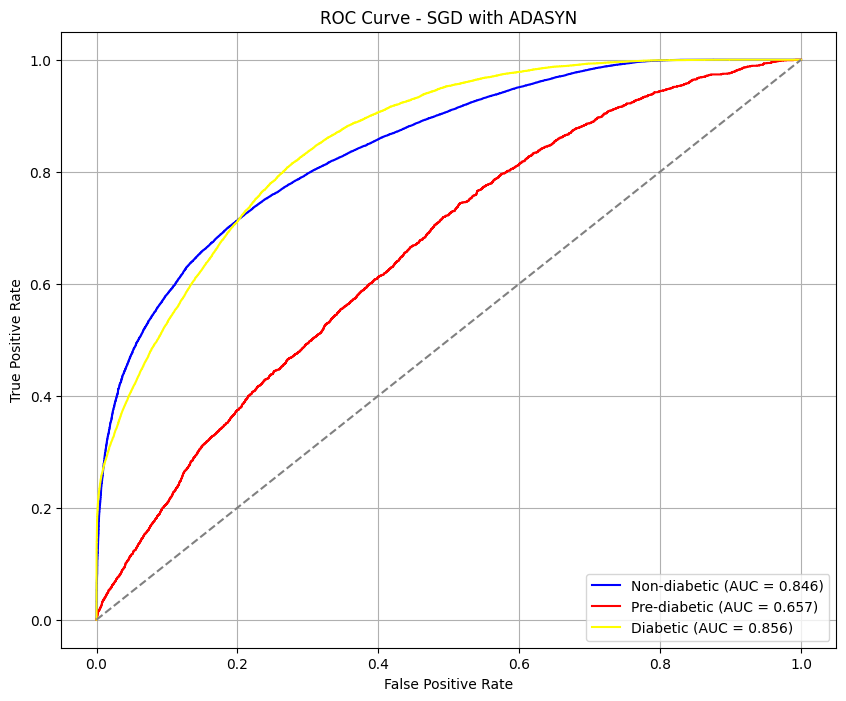

In [28]:
# Plot ROC and AUC of SGD model with ADASYN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_class_probabilities["SGDClassifier"],
    model_name="SGD with ADASYN"
)

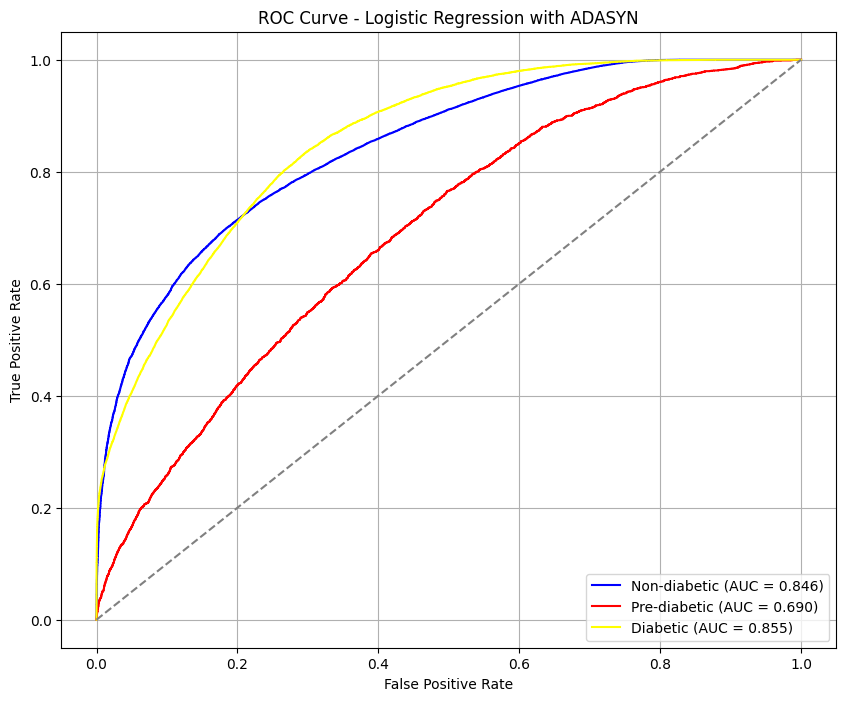

In [29]:
# Plot ROC and AUC of Logistic Regression model with ADASYN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_class_probabilities["LogisticRegression"],
    model_name="Logistic Regression with ADASYN"
)

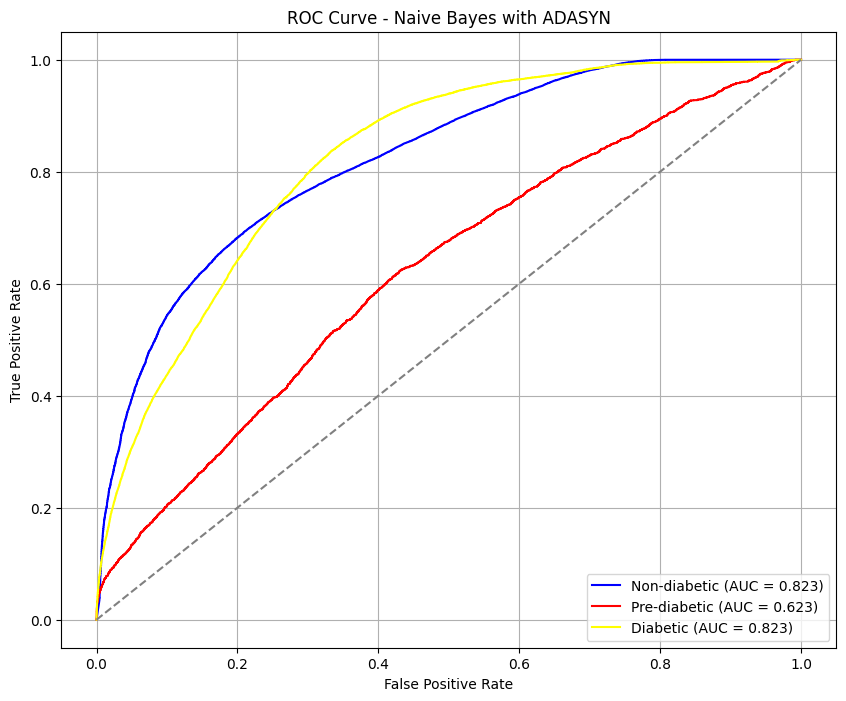

In [30]:
# Plot ROC and AUC of Naive Bayes model with ADASYN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_class_probabilities["NaiveBayes"],
    model_name="Naive Bayes with ADASYN"
)

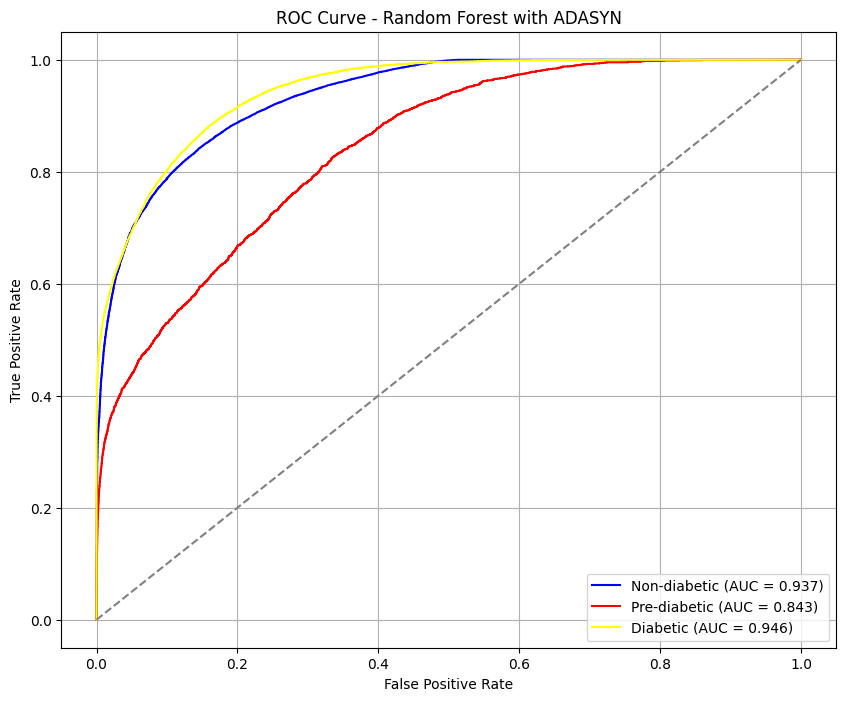

In [31]:
# Plot ROC and AUC of Random Forest model with ADASYN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_class_probabilities["RandomForest"],
    model_name="Random Forest with ADASYN"
)

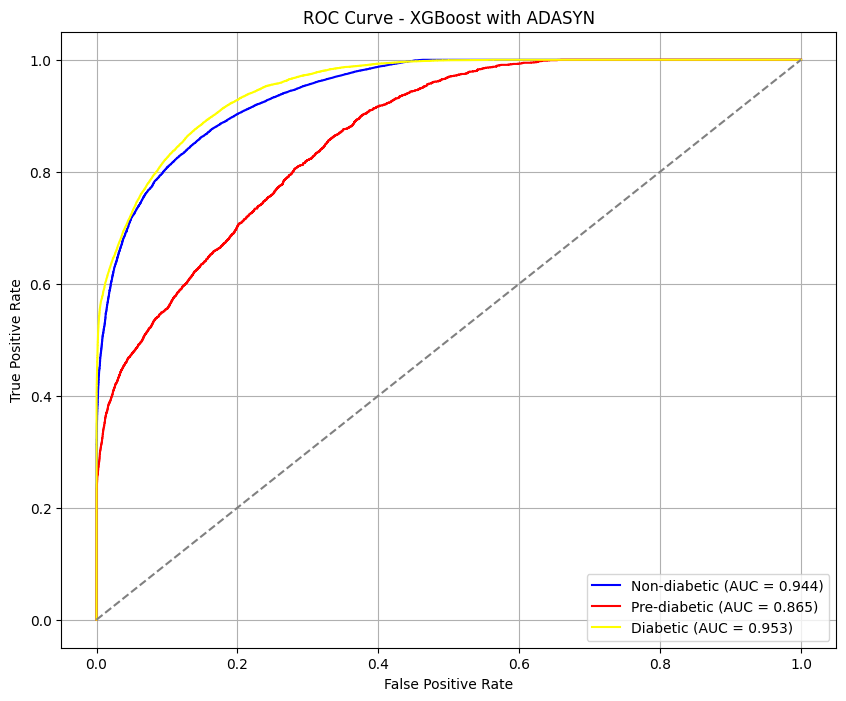

In [32]:
# Plot ROC and AUC of XGBoost model with ADASYN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_class_probabilities["XGBoost"],
    model_name="XGBoost with ADASYN"
)

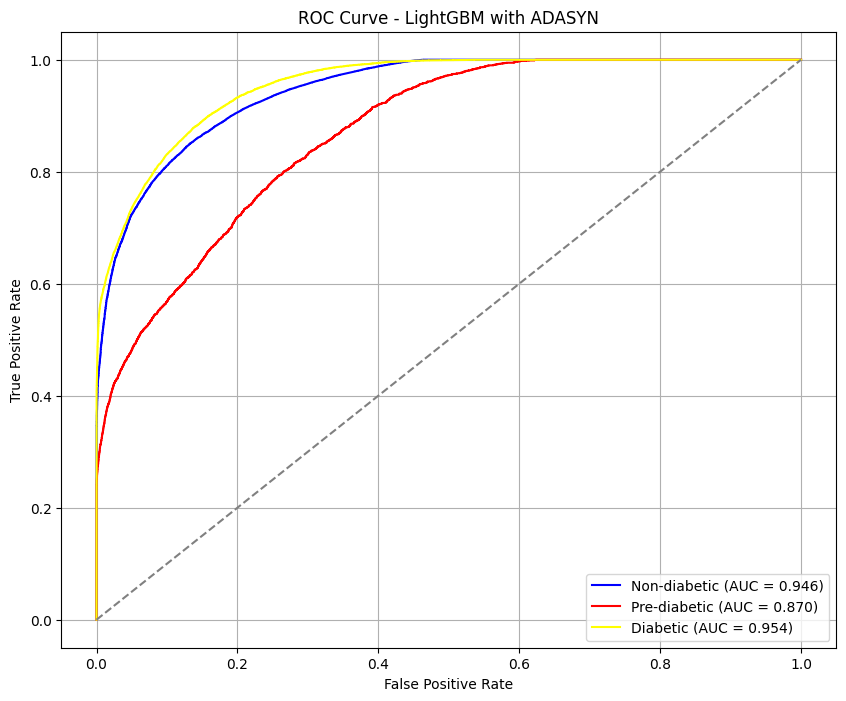

In [33]:
# Plot ROC and AUC of LightGBM model with ADASYN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_class_probabilities["LightGBM"],
    model_name="LightGBM with ADASYN"
)

### **2.4 Random Undersampling**

In [34]:
# Train and get evaluation results with the Random Undersamling method
rus_evaluation_results, rus_class_probabilities, rus_models = train_evaluate_all_models(
    X_train=rus_X_train_scaled, 
    y_train=rus_y_train, 
    X_test=rus_X_test_scaled, 
    y_test=y_test, 
    method_name="Random Undersampling"
)

2025-09-27 22:10:10,032 - [random_undersampling.sgd_classifier] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-09-27 22:10:10,033 - [random_undersampling.sgd_classifier] - INFO -   loss: log_loss
2025-09-27 22:10:10,034 - [random_undersampling.sgd_classifier] - INFO -   penalty: l2
2025-09-27 22:10:10,034 - [random_undersampling.sgd_classifier] - INFO -   alpha: 0.0001
2025-09-27 22:10:10,036 - [random_undersampling.sgd_classifier] - INFO -   learning_rate: constant
2025-09-27 22:10:10,037 - [random_undersampling.sgd_classifier] - INFO -   eta0: 0.01
2025-09-27 22:10:10,037 - [random_undersampling.sgd_classifier] - INFO -   max_iter: 1000
2025-09-27 22:10:10,038 - [random_undersampling.sgd_classifier] - INFO -   random_state: 42
2025-09-27 22:10:10,040 - [random_undersampling.logistic_regression] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-09-27 22:10:10,042 - [random_undersampling.logistic_regression] - INFO -   C: 1.0
2025-09-27 22:10:10,04

Training SGDClassifier on Random Undersampling data...


2025-09-27 22:10:10,913 - [random_undersampling.sgd_classifier] - INFO - Model training completed. Training samples: 225948
2025-09-27 22:10:10,914 - [random_undersampling.sgd_classifier] - INFO - Number of iterations: 7
2025-09-27 22:10:10,925 - [random_undersampling.sgd_classifier] - INFO - Predictions made for 89841 samples
2025-09-27 22:10:10,977 - [random_undersampling.sgd_classifier] - INFO - Model Evaluation Results:
2025-09-27 22:10:10,978 - [random_undersampling.sgd_classifier] - INFO - Accuracy: 0.8079
2025-09-27 22:10:10,978 - [random_undersampling.sgd_classifier] - INFO - Precision: 0.4678
2025-09-27 22:10:10,979 - [random_undersampling.sgd_classifier] - INFO - Recall: 0.4872
2025-09-27 22:10:10,980 - [random_undersampling.sgd_classifier] - INFO - F1-Score: 0.4772
2025-09-27 22:10:11,035 - [random_undersampling.sgd_classifier] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.89      0.89     70854
        

Training LogisticRegression on Random Undersampling data...


2025-09-27 22:10:55,684 - [random_undersampling.logistic_regression] - INFO - Model training completed. Training samples: 225948
2025-09-27 22:10:55,696 - [random_undersampling.logistic_regression] - INFO - Predictions made for 89841 samples
2025-09-27 22:10:55,729 - [random_undersampling.logistic_regression] - INFO - Model Evaluation Results:
2025-09-27 22:10:55,730 - [random_undersampling.logistic_regression] - INFO - Accuracy: 0.8113
2025-09-27 22:10:55,733 - [random_undersampling.logistic_regression] - INFO - Precision: 0.4705
2025-09-27 22:10:55,734 - [random_undersampling.logistic_regression] - INFO - Recall: 0.4838
2025-09-27 22:10:55,735 - [random_undersampling.logistic_regression] - INFO - F1-Score: 0.4770
2025-09-27 22:10:55,779 - [random_undersampling.logistic_regression] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.90      0.89     70854
         1.0       0.00      0.00      0.00      2397
         2.

...

2025-09-27 22:15:23,176 - [random_undersampling.xgboost] - INFO - Model training completed. Training samples: 225948
2025-09-27 22:15:23,323 - [random_undersampling.xgboost] - INFO - Predictions made for 89841 samples
2025-09-27 22:15:23,369 - [random_undersampling.xgboost] - INFO - Model Evaluation Results:
2025-09-27 22:15:23,370 - [random_undersampling.xgboost] - INFO - Accuracy: 0.8930
2025-09-27 22:15:23,371 - [random_undersampling.xgboost] - INFO - Precision: 0.8858
2025-09-27 22:15:23,371 - [random_undersampling.xgboost] - INFO - Recall: 0.6460
2025-09-27 22:15:23,372 - [random_undersampling.xgboost] - INFO - F1-Score: 0.6899
2025-09-27 22:15:23,407 - [random_undersampling.xgboost] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.95      0.94     70854
         1.0       0.99      0.24      0.38      2397
         2.0       0.74      0.75      0.75     16590

    accuracy                           0.89     8984

Training LightGBM on Random Undersampling data...
[LightGBM] [Info] Total Bins 468
[LightGBM] [Info] Number of data points in the train set: 225948, number of used features: 33
[LightGBM] [Info] Start training from score -0.409670
[LightGBM] [Info] Start training from score -3.160001
[LightGBM] [Info] Start training from score -1.225180


2025-09-27 22:15:44,011 - [random_undersampling.lightgbm] - INFO - Model training completed. Training samples: 225948
2025-09-27 22:15:44,727 - [random_undersampling.lightgbm] - INFO - Predictions made for 89841 samples
2025-09-27 22:15:44,767 - [random_undersampling.lightgbm] - INFO - Model Evaluation Results:
2025-09-27 22:15:44,768 - [random_undersampling.lightgbm] - INFO - Accuracy: 0.8934
2025-09-27 22:15:44,768 - [random_undersampling.lightgbm] - INFO - Precision: 0.8771
2025-09-27 22:15:44,769 - [random_undersampling.lightgbm] - INFO - Recall: 0.6493
2025-09-27 22:15:44,771 - [random_undersampling.lightgbm] - INFO - F1-Score: 0.6929
2025-09-27 22:15:44,813 - [random_undersampling.lightgbm] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.95      0.94     70854
         1.0       0.96      0.25      0.39      2397
         2.0       0.74      0.75      0.75     16590

    accuracy                           0.89 

[LightGBM] [Info] Total Bins 468
[LightGBM] [Info] Number of data points in the train set: 180758, number of used features: 33
[LightGBM] [Info] Start training from score -0.409667
[LightGBM] [Info] Start training from score -3.160103
[LightGBM] [Info] Start training from score -1.225171
[LightGBM] [Info] Total Bins 468
[LightGBM] [Info] Number of data points in the train set: 180758, number of used features: 33
[LightGBM] [Info] Start training from score -0.409667
[LightGBM] [Info] Start training from score -3.159973
[LightGBM] [Info] Start training from score -1.225189
[LightGBM] [Info] Total Bins 467
[LightGBM] [Info] Number of data points in the train set: 180758, number of used features: 33
[LightGBM] [Info] Start training from score -0.409667
[LightGBM] [Info] Start training from score -3.159973
[LightGBM] [Info] Start training from score -1.225189
[LightGBM] [Info] Total Bins 467
[LightGBM] [Info] Number of data points in the train set: 180759, number of used features: 33
[Light

2025-09-27 22:16:02,941 - [random_undersampling.lightgbm] - INFO - Cross-validation results:
2025-09-27 22:16:02,942 - [random_undersampling.lightgbm] - INFO - Mean accuracy: 0.8615 (+/- 0.0029)
2025-09-27 22:16:02,968 - [random_undersampling.sgd_classifier] - INFO - Predictions made for 89841 samples
2025-09-27 22:16:03,020 - [random_undersampling.sgd_classifier] - INFO - Probabilities predicted for 89841 samples
2025-09-27 22:16:03,340 - [random_undersampling.logistic_regression] - INFO - Predictions made for 89841 samples
2025-09-27 22:16:03,364 - [random_undersampling.logistic_regression] - INFO - Probabilities predicted for 89841 samples
2025-09-27 22:16:03,590 - [random_undersampling.naive_bayes] - INFO - Predictions made for 89841 samples
2025-09-27 22:16:03,645 - [random_undersampling.naive_bayes] - INFO - Probabilities predicted for 89841 samples
2025-09-27 22:16:05,306 - [random_undersampling.random_forest] - INFO - Predictions made for 89841 samples
2025-09-27 22:16:06,687 -

In [35]:
# The evaluation result of all models with the Random Undersampling method
rus_evaluation_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2,CV Mean,CV Std
0,SGDClassifier,0.8079,0.8011,0.4872,0.4772,0.7921,0.8794,1.0000,0.5241,0.8907,0.0000,0.5710,0.8850,0.0000,0.5465,0.758360,0.001418
1,LogisticRegression,0.8113,0.8038,0.4838,0.4770,0.7989,0.8762,1.0000,0.5353,0.8995,0.0000,0.5518,0.8877,0.0000,0.5434,0.759790,0.001778
2,NaiveBayes,0.7429,0.4699,0.5060,0.4811,0.7666,0.8889,0.0875,0.4332,0.7926,0.1022,0.6233,0.8380,0.0943,0.5111,0.711889,0.001387
3,RandomForest,0.8277,0.5920,0.6821,0.6235,0.9075,0.9555,0.2343,0.5863,0.8400,0.3642,0.8420,0.8940,0.2852,0.6913,0.820012,0.000805
4,XGBoost,0.8930,0.8858,0.6460,0.6899,0.9233,0.9265,0.9862,0.7446,0.9485,0.2390,0.7505,0.9373,0.3848,0.7475,0.860494,0.001186
5,LightGBM,0.8934,0.8771,0.6493,0.6929,0.9239,0.9273,0.9594,0.7447,0.9481,0.2466,0.7533,0.9376,0.3923,0.7490,0.861512,0.001474


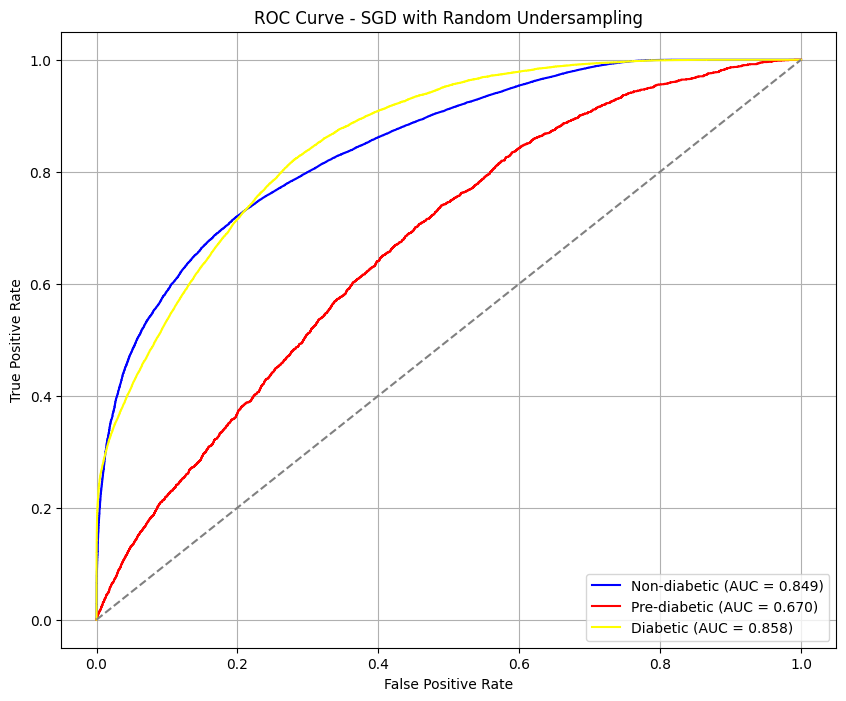

In [36]:
# Plot ROC and AUC of SGD model with Random Undersampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=rus_class_probabilities["SGDClassifier"],
    model_name="SGD with Random Undersampling"
)

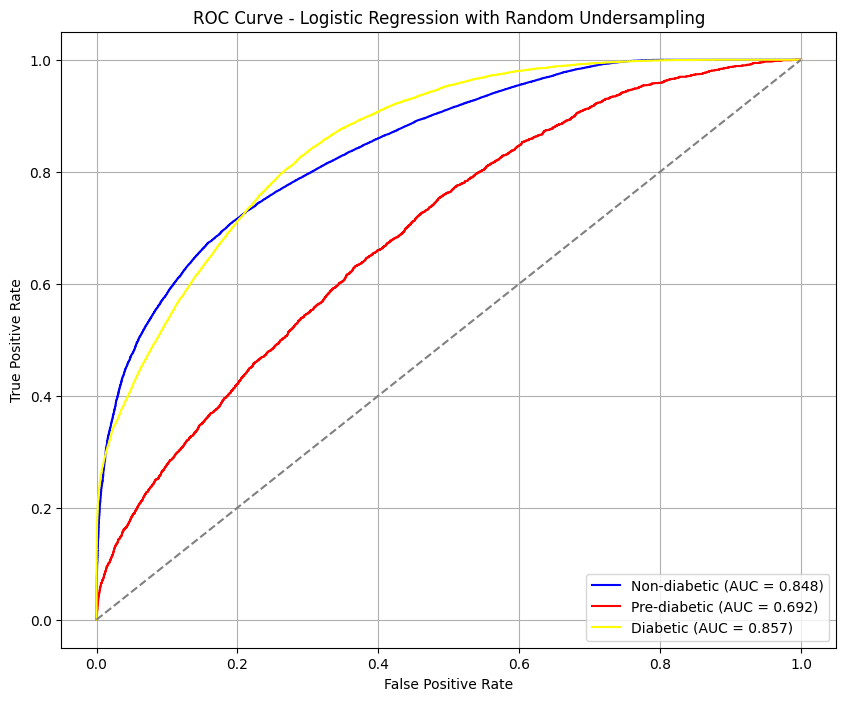

In [37]:
# Plot ROC and AUC of Logistic Regression model with Random Undersampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=rus_class_probabilities["LogisticRegression"],
    model_name="Logistic Regression with Random Undersampling"
)

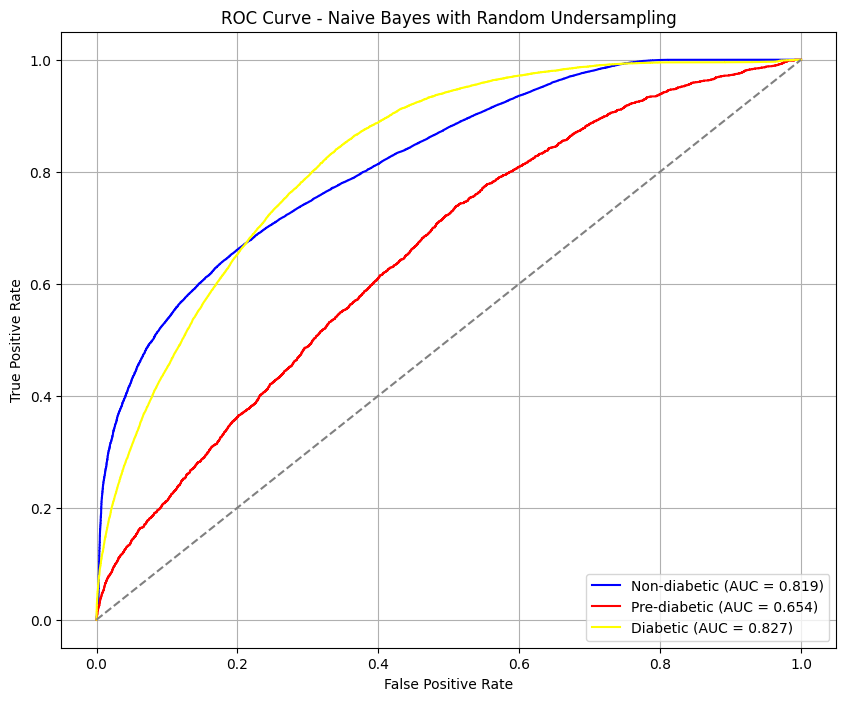

In [38]:
# Plot ROC and AUC of Naive Bayes model with Random Undersampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=rus_class_probabilities["NaiveBayes"],
    model_name="Naive Bayes with Random Undersampling"
)

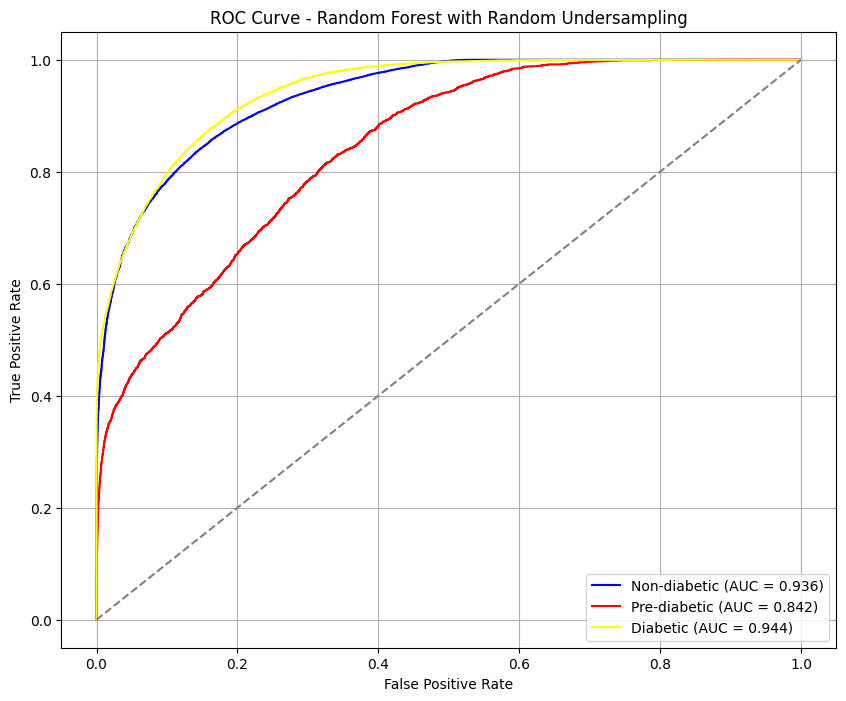

In [39]:
# Plot ROC and AUC of Random Forest model with Random Undersampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=rus_class_probabilities["RandomForest"],
    model_name="Random Forest with Random Undersampling"
)

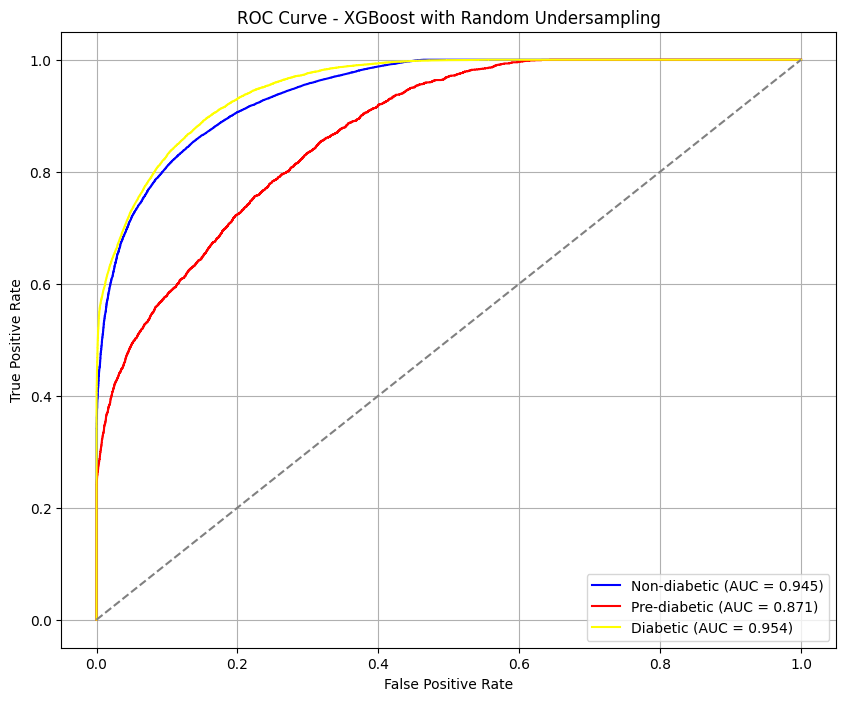

In [40]:
# Plot ROC and AUC of XGBoost model with Random Undersampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=rus_class_probabilities["XGBoost"], 
    model_name="XGBoost with Random Undersampling", 
)

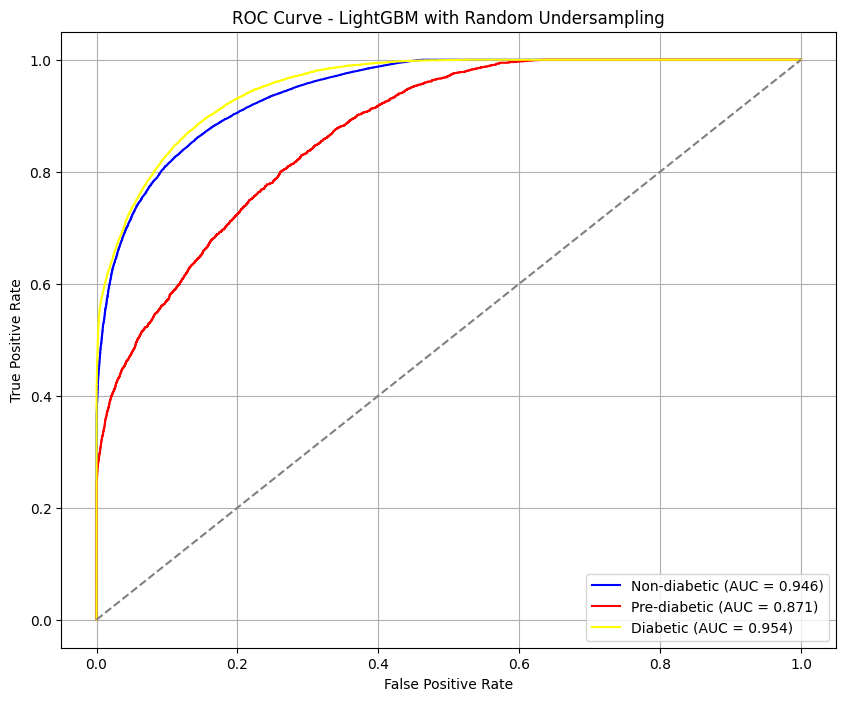

In [41]:
# Plot ROC and AUC of LightGBM model with Random Undersampling method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=rus_class_probabilities["LightGBM"], 
    model_name="LightGBM with Random Undersampling", 
)

### **2.5 Tomek Links**

In [42]:
# Train and get evaluation results with the Tomek Links method
tomek_evaluation_results, tomek_class_probabilities, tomek_models = train_evaluate_all_models(
    X_train=tomek_X_train_scaled, 
    y_train=tomek_y_train, 
    X_test=tomek_X_test_scaled, 
    y_test=y_test, 
    method_name="Tomek Links"
)

2025-09-27 22:16:10,560 - [tomek_links.sgd_classifier] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-09-27 22:16:10,560 - [tomek_links.sgd_classifier] - INFO -   loss: log_loss
2025-09-27 22:16:10,561 - [tomek_links.sgd_classifier] - INFO -   penalty: l2
2025-09-27 22:16:10,562 - [tomek_links.sgd_classifier] - INFO -   alpha: 0.0001
2025-09-27 22:16:10,562 - [tomek_links.sgd_classifier] - INFO -   learning_rate: constant
2025-09-27 22:16:10,563 - [tomek_links.sgd_classifier] - INFO -   eta0: 0.01
2025-09-27 22:16:10,564 - [tomek_links.sgd_classifier] - INFO -   max_iter: 1000
2025-09-27 22:16:10,565 - [tomek_links.sgd_classifier] - INFO -   random_state: 42
2025-09-27 22:16:10,567 - [tomek_links.logistic_regression] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-09-27 22:16:10,567 - [tomek_links.logistic_regression] - INFO -   C: 1.0
2025-09-27 22:16:10,568 - [tomek_links.logistic_regression] - INFO -   penalty: l2
2025-09-27 22:16:10,568 - [to

Training SGDClassifier on Tomek Links data...


2025-09-27 22:16:11,934 - [tomek_links.sgd_classifier] - INFO - Model training completed. Training samples: 341544
2025-09-27 22:16:11,935 - [tomek_links.sgd_classifier] - INFO - Number of iterations: 7
2025-09-27 22:16:11,951 - [tomek_links.sgd_classifier] - INFO - Predictions made for 89841 samples
2025-09-27 22:16:11,995 - [tomek_links.sgd_classifier] - INFO - Model Evaluation Results:
2025-09-27 22:16:11,997 - [tomek_links.sgd_classifier] - INFO - Accuracy: 0.8323
2025-09-27 22:16:12,000 - [tomek_links.sgd_classifier] - INFO - Precision: 0.5057
2025-09-27 22:16:12,002 - [tomek_links.sgd_classifier] - INFO - Recall: 0.4567
2025-09-27 22:16:12,005 - [tomek_links.sgd_classifier] - INFO - F1-Score: 0.4703
2025-09-27 22:16:12,064 - [tomek_links.sgd_classifier] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.96      0.90     70854
         1.0       0.00      0.00      0.00      2397
         2.0       0.66      0.41  

Training LogisticRegression on Tomek Links data...


2025-09-27 22:17:15,046 - [tomek_links.logistic_regression] - INFO - Model training completed. Training samples: 341544
2025-09-27 22:17:15,061 - [tomek_links.logistic_regression] - INFO - Predictions made for 89841 samples
2025-09-27 22:17:15,135 - [tomek_links.logistic_regression] - INFO - Model Evaluation Results:
2025-09-27 22:17:15,139 - [tomek_links.logistic_regression] - INFO - Accuracy: 0.8366
2025-09-27 22:17:15,141 - [tomek_links.logistic_regression] - INFO - Precision: 0.5237
2025-09-27 22:17:15,142 - [tomek_links.logistic_regression] - INFO - Recall: 0.4488
2025-09-27 22:17:15,143 - [tomek_links.logistic_regression] - INFO - F1-Score: 0.4662
2025-09-27 22:17:15,204 - [tomek_links.logistic_regression] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.97      0.91     70854
         1.0       0.00      0.00      0.00      2397
         2.0       0.72      0.37      0.49     16590

    accuracy                

...

2025-09-27 22:24:15,441 - [tomek_links.xgboost] - INFO - Model training completed. Training samples: 341544
2025-09-27 22:24:15,598 - [tomek_links.xgboost] - INFO - Predictions made for 89841 samples
2025-09-27 22:24:15,645 - [tomek_links.xgboost] - INFO - Model Evaluation Results:
2025-09-27 22:24:15,646 - [tomek_links.xgboost] - INFO - Accuracy: 0.9012
2025-09-27 22:24:15,646 - [tomek_links.xgboost] - INFO - Precision: 0.9300
2025-09-27 22:24:15,647 - [tomek_links.xgboost] - INFO - Recall: 0.6161
2025-09-27 22:24:15,647 - [tomek_links.xgboost] - INFO - F1-Score: 0.6869
2025-09-27 22:24:15,684 - [tomek_links.xgboost] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.99      0.94     70854
         1.0       0.99      0.24      0.38      2397
         2.0       0.90      0.62      0.73     16590

    accuracy                           0.90     89841
   macro avg       0.93      0.62      0.69     89841
weighted avg    

Training LightGBM on Tomek Links data...
[LightGBM] [Info] Total Bins 465
[LightGBM] [Info] Number of data points in the train set: 341544, number of used features: 33
[LightGBM] [Info] Start training from score -0.219692
[LightGBM] [Info] Start training from score -3.573173
[LightGBM] [Info] Start training from score -1.776868


2025-09-27 22:24:44,929 - [tomek_links.lightgbm] - INFO - Model training completed. Training samples: 341544
2025-09-27 22:24:45,619 - [tomek_links.lightgbm] - INFO - Predictions made for 89841 samples
2025-09-27 22:24:45,655 - [tomek_links.lightgbm] - INFO - Model Evaluation Results:
2025-09-27 22:24:45,656 - [tomek_links.lightgbm] - INFO - Accuracy: 0.9011
2025-09-27 22:24:45,657 - [tomek_links.lightgbm] - INFO - Precision: 0.9180
2025-09-27 22:24:45,658 - [tomek_links.lightgbm] - INFO - Recall: 0.6218
2025-09-27 22:24:45,659 - [tomek_links.lightgbm] - INFO - F1-Score: 0.6900
2025-09-27 22:24:45,700 - [tomek_links.lightgbm] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.99      0.94     70854
         1.0       0.97      0.24      0.39      2397
         2.0       0.88      0.64      0.74     16590

    accuracy                           0.90     89841
   macro avg       0.92      0.62      0.69     89841
weighted

[LightGBM] [Info] Total Bins 467
[LightGBM] [Info] Number of data points in the train set: 273235, number of used features: 33
[LightGBM] [Info] Start training from score -0.219691
[LightGBM] [Info] Start training from score -3.573146
[LightGBM] [Info] Start training from score -1.776876
[LightGBM] [Info] Total Bins 467
[LightGBM] [Info] Number of data points in the train set: 273235, number of used features: 33
[LightGBM] [Info] Start training from score -0.219691
[LightGBM] [Info] Start training from score -3.573146
[LightGBM] [Info] Start training from score -1.776876
[LightGBM] [Info] Total Bins 466
[LightGBM] [Info] Number of data points in the train set: 273235, number of used features: 33
[LightGBM] [Info] Start training from score -0.219691
[LightGBM] [Info] Start training from score -3.573146
[LightGBM] [Info] Start training from score -1.776876
[LightGBM] [Info] Total Bins 466
[LightGBM] [Info] Number of data points in the train set: 273235, number of used features: 33
[Light

2025-09-27 22:25:12,355 - [tomek_links.lightgbm] - INFO - Cross-validation results:
2025-09-27 22:25:12,356 - [tomek_links.lightgbm] - INFO - Mean accuracy: 0.9162 (+/- 0.0026)
2025-09-27 22:25:12,380 - [tomek_links.sgd_classifier] - INFO - Predictions made for 89841 samples
2025-09-27 22:25:12,406 - [tomek_links.sgd_classifier] - INFO - Probabilities predicted for 89841 samples
2025-09-27 22:25:12,610 - [tomek_links.logistic_regression] - INFO - Predictions made for 89841 samples
2025-09-27 22:25:12,634 - [tomek_links.logistic_regression] - INFO - Probabilities predicted for 89841 samples
2025-09-27 22:25:12,863 - [tomek_links.naive_bayes] - INFO - Predictions made for 89841 samples
2025-09-27 22:25:12,913 - [tomek_links.naive_bayes] - INFO - Probabilities predicted for 89841 samples
2025-09-27 22:25:14,553 - [tomek_links.random_forest] - INFO - Predictions made for 89841 samples
2025-09-27 22:25:15,949 - [tomek_links.random_forest] - INFO - Probabilities predicted for 89841 samples
2

In [43]:
# The evaluation result of all models with the Tomek Links method
tomek_evaluation_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2,CV Mean,CV Std
0,SGDClassifier,0.8323,0.8391,0.4567,0.4703,0.7922,0.8542,1.0000,0.6630,0.9592,0.0000,0.4108,0.9036,0.0000,0.5073,0.850906,0.002122
1,LogisticRegression,0.8366,0.8571,0.4488,0.4662,0.7996,0.8486,1.0000,0.7225,0.9735,0.0000,0.3728,0.9068,0.0000,0.4918,0.852385,0.000913
2,NaiveBayes,0.7521,0.4728,0.5011,0.4828,0.7667,0.8838,0.0908,0.4437,0.8114,0.0985,0.5936,0.8460,0.0945,0.5078,0.763108,0.001022
3,RandomForest,0.8409,0.5988,0.6751,0.6275,0.9061,0.9482,0.2210,0.6271,0.8653,0.3525,0.8075,0.9049,0.2717,0.7059,0.858437,0.002437
4,XGBoost,0.9012,0.9300,0.6161,0.6869,0.9233,0.9013,0.9930,0.8955,0.9891,0.2378,0.6215,0.9432,0.3837,0.7337,0.915780,0.001185
5,LightGBM,0.9011,0.9180,0.6218,0.6900,0.9242,0.9044,0.9733,0.8763,0.9852,0.2432,0.6369,0.9431,0.3892,0.7377,0.916175,0.001312


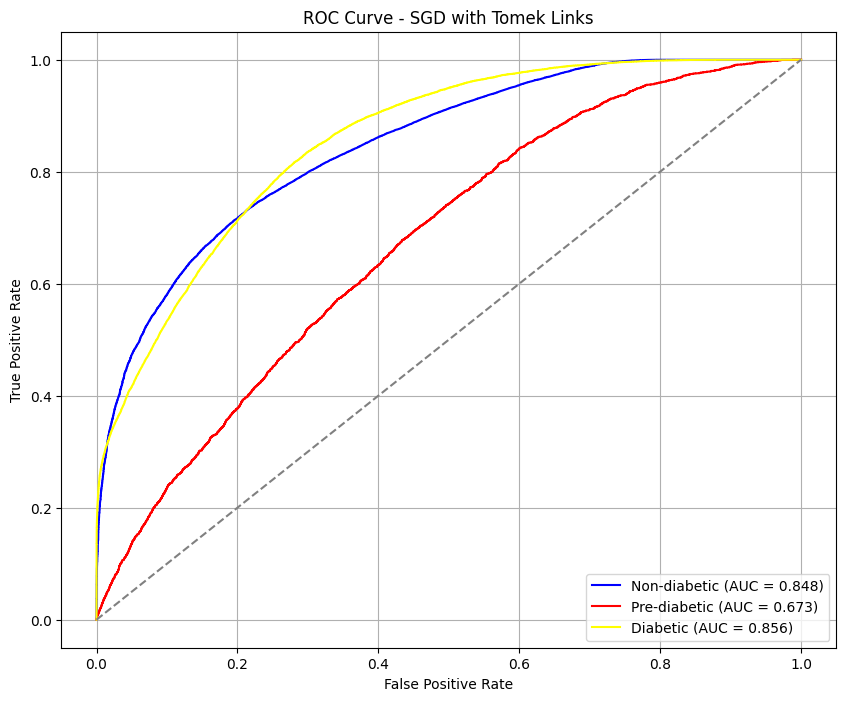

In [44]:
# Plot ROC and AUC of SGD model with Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=tomek_class_probabilities["SGDClassifier"],
    model_name="SGD with Tomek Links"
)

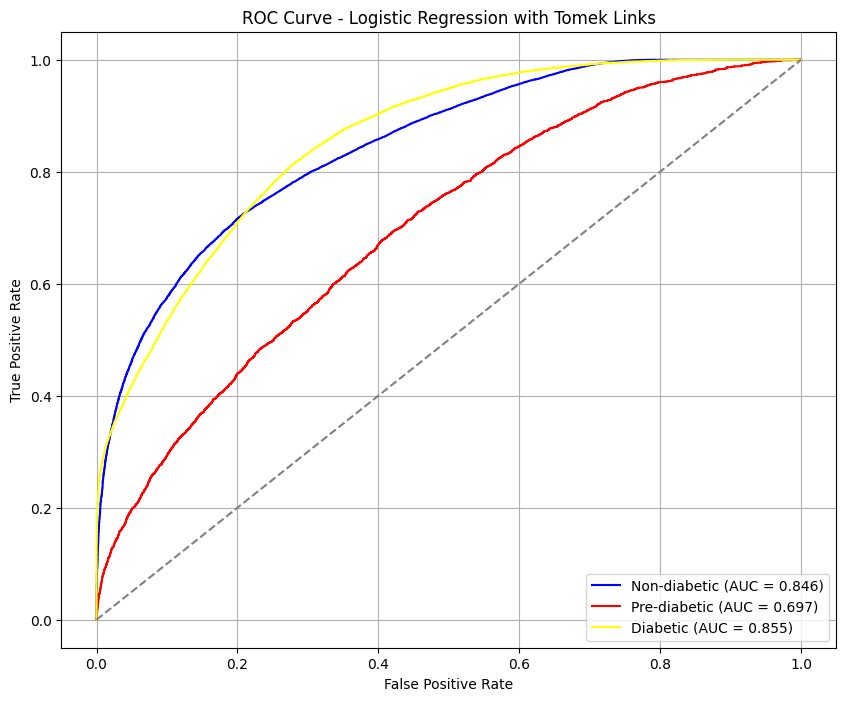

In [45]:
# Plot ROC and AUC of Logistic Regression model with Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=tomek_class_probabilities["LogisticRegression"],
    model_name="Logistic Regression with Tomek Links"
)

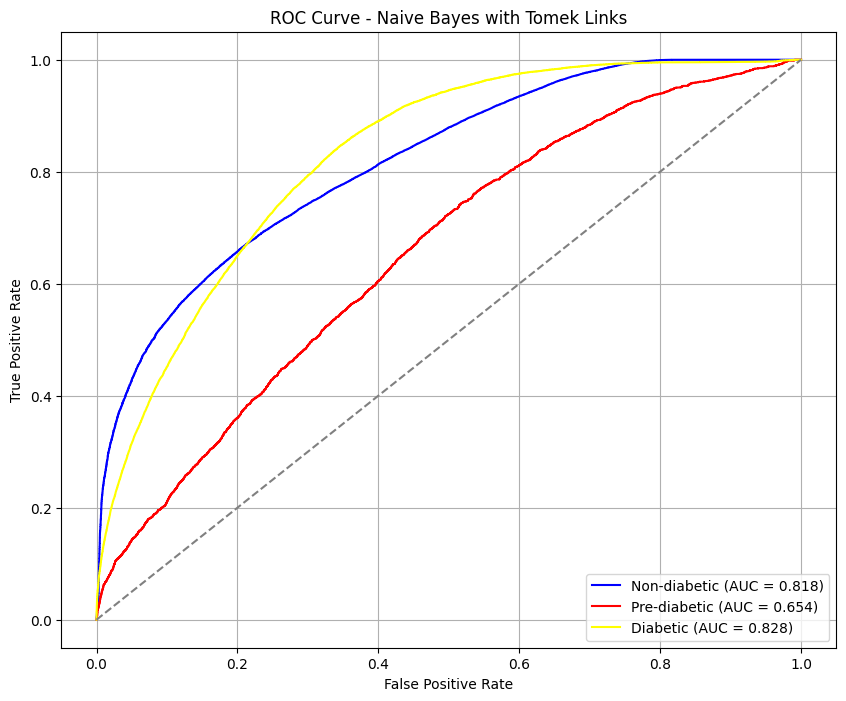

In [46]:
# Plot ROC and AUC of Naive Bayes model with Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=tomek_class_probabilities["NaiveBayes"],
    model_name="Naive Bayes with Tomek Links"
)

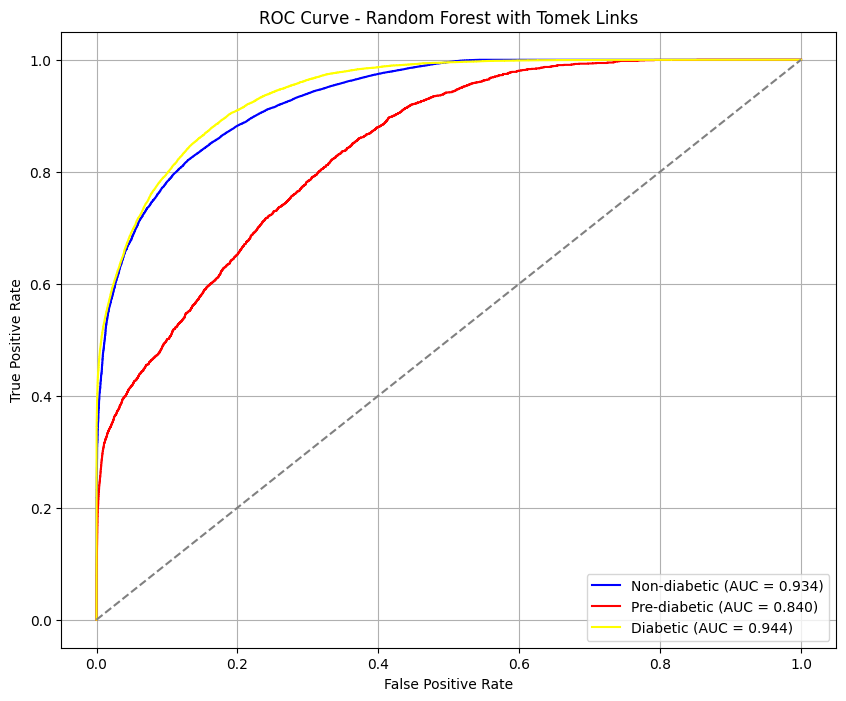

In [47]:
# Plot ROC and AUC of Random Forest model with Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=tomek_class_probabilities["RandomForest"],
    model_name="Random Forest with Tomek Links"
)

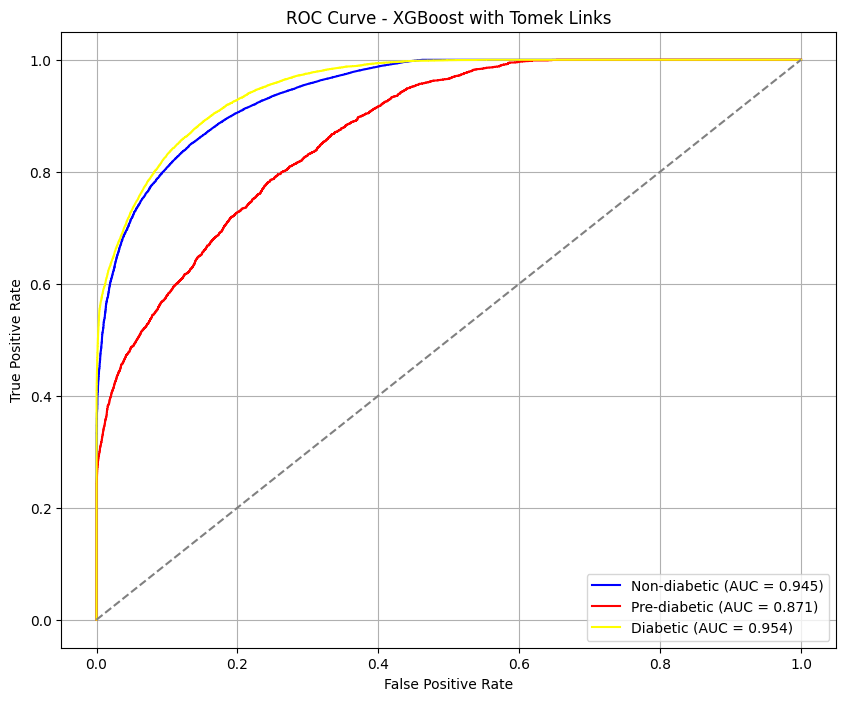

In [48]:
# Plot ROC and AUC of XGBoost model with Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=tomek_class_probabilities["XGBoost"],
    model_name="XGBoost with Tomek Links"
)

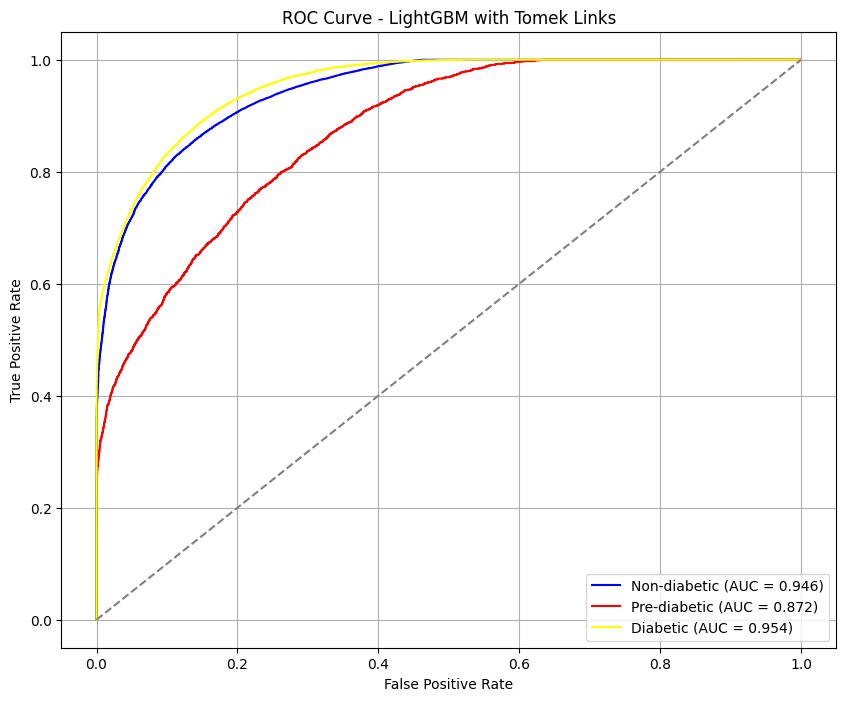

In [49]:
# Plot ROC and AUC of LightGBM model with Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=tomek_class_probabilities["LightGBM"],
    model_name="LightGBM with Tomek Links"
)

### **2.6 Edited Nearest Neighbors**

In [50]:
# Train and get evaluation results with the Edited Nearest Neighbors method
enn_evaluation_results, enn_class_probabilities, enn_models = train_evaluate_all_models(
    X_train=enn_X_train_scaled, 
    y_train=enn_y_train, 
    X_test=enn_X_test_scaled, 
    y_test=y_test, 
    method_name="Edited Nearest Neighbors"
)

2025-09-27 22:25:20,039 - [edited_nearest_neighbors.sgd_classifier] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-09-27 22:25:20,041 - [edited_nearest_neighbors.sgd_classifier] - INFO -   loss: log_loss
2025-09-27 22:25:20,042 - [edited_nearest_neighbors.sgd_classifier] - INFO -   penalty: l2
2025-09-27 22:25:20,043 - [edited_nearest_neighbors.sgd_classifier] - INFO -   alpha: 0.0001
2025-09-27 22:25:20,044 - [edited_nearest_neighbors.sgd_classifier] - INFO -   learning_rate: constant
2025-09-27 22:25:20,045 - [edited_nearest_neighbors.sgd_classifier] - INFO -   eta0: 0.01
2025-09-27 22:25:20,047 - [edited_nearest_neighbors.sgd_classifier] - INFO -   max_iter: 1000
2025-09-27 22:25:20,049 - [edited_nearest_neighbors.sgd_classifier] - INFO -   random_state: 42
2025-09-27 22:25:20,050 - [edited_nearest_neighbors.logistic_regression] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-09-27 22:25:20,051 - [edited_nearest_neighbors.logistic_regression] 

Training SGDClassifier on Edited Nearest Neighbors data...


2025-09-27 22:25:21,014 - [edited_nearest_neighbors.sgd_classifier] - INFO - Model training completed. Training samples: 254273
2025-09-27 22:25:21,015 - [edited_nearest_neighbors.sgd_classifier] - INFO - Number of iterations: 7
2025-09-27 22:25:21,026 - [edited_nearest_neighbors.sgd_classifier] - INFO - Predictions made for 89841 samples
2025-09-27 22:25:21,067 - [edited_nearest_neighbors.sgd_classifier] - INFO - Model Evaluation Results:
2025-09-27 22:25:21,068 - [edited_nearest_neighbors.sgd_classifier] - INFO - Accuracy: 0.8410
2025-09-27 22:25:21,069 - [edited_nearest_neighbors.sgd_classifier] - INFO - Precision: 0.5657
2025-09-27 22:25:21,070 - [edited_nearest_neighbors.sgd_classifier] - INFO - Recall: 0.4343
2025-09-27 22:25:21,070 - [edited_nearest_neighbors.sgd_classifier] - INFO - F1-Score: 0.4549
2025-09-27 22:25:21,114 - [edited_nearest_neighbors.sgd_classifier] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.84   

Training LogisticRegression on Edited Nearest Neighbors data...


2025-09-27 22:26:08,744 - [edited_nearest_neighbors.logistic_regression] - INFO - Model training completed. Training samples: 254273
2025-09-27 22:26:08,755 - [edited_nearest_neighbors.logistic_regression] - INFO - Predictions made for 89841 samples
2025-09-27 22:26:08,784 - [edited_nearest_neighbors.logistic_regression] - INFO - Model Evaluation Results:
2025-09-27 22:26:08,785 - [edited_nearest_neighbors.logistic_regression] - INFO - Accuracy: 0.8421
2025-09-27 22:26:08,786 - [edited_nearest_neighbors.logistic_regression] - INFO - Precision: 0.5624
2025-09-27 22:26:08,787 - [edited_nearest_neighbors.logistic_regression] - INFO - Recall: 0.4375
2025-09-27 22:26:08,787 - [edited_nearest_neighbors.logistic_regression] - INFO - F1-Score: 0.4584
2025-09-27 22:26:08,819 - [edited_nearest_neighbors.logistic_regression] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.99      0.91     70854
         1.0       0.00      0.00

...

2025-09-27 22:30:54,203 - [edited_nearest_neighbors.xgboost] - INFO - Model training completed. Training samples: 254273
2025-09-27 22:30:54,378 - [edited_nearest_neighbors.xgboost] - INFO - Predictions made for 89841 samples
2025-09-27 22:30:54,422 - [edited_nearest_neighbors.xgboost] - INFO - Model Evaluation Results:
2025-09-27 22:30:54,423 - [edited_nearest_neighbors.xgboost] - INFO - Accuracy: 0.8963
2025-09-27 22:30:54,424 - [edited_nearest_neighbors.xgboost] - INFO - Precision: 0.8345
2025-09-27 22:30:54,425 - [edited_nearest_neighbors.xgboost] - INFO - Recall: 0.6114
2025-09-27 22:30:54,426 - [edited_nearest_neighbors.xgboost] - INFO - F1-Score: 0.6789
2025-09-27 22:30:54,461 - [edited_nearest_neighbors.xgboost] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      1.00      0.94     70854
         1.0       0.67      0.28      0.39      2397
         2.0       0.94      0.56      0.70     16590

    accuracy        

Training LightGBM on Edited Nearest Neighbors data...
[LightGBM] [Info] Total Bins 467
[LightGBM] [Info] Number of data points in the train set: 254273, number of used features: 33
[LightGBM] [Info] Start training from score -0.150305
[LightGBM] [Info] Start training from score -3.278105
[LightGBM] [Info] Start training from score -2.284204


2025-09-27 22:31:17,086 - [edited_nearest_neighbors.lightgbm] - INFO - Model training completed. Training samples: 254273
2025-09-27 22:31:17,861 - [edited_nearest_neighbors.lightgbm] - INFO - Predictions made for 89841 samples
2025-09-27 22:31:17,902 - [edited_nearest_neighbors.lightgbm] - INFO - Model Evaluation Results:
2025-09-27 22:31:17,902 - [edited_nearest_neighbors.lightgbm] - INFO - Accuracy: 0.8960
2025-09-27 22:31:17,903 - [edited_nearest_neighbors.lightgbm] - INFO - Precision: 0.7853
2025-09-27 22:31:17,904 - [edited_nearest_neighbors.lightgbm] - INFO - Recall: 0.6222
2025-09-27 22:31:17,905 - [edited_nearest_neighbors.lightgbm] - INFO - F1-Score: 0.6784
2025-09-27 22:31:17,947 - [edited_nearest_neighbors.lightgbm] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.99      0.94     70854
         1.0       0.55      0.29      0.38      2397
         2.0       0.91      0.58      0.71     16590

    accuracy

[LightGBM] [Info] Total Bins 467
[LightGBM] [Info] Number of data points in the train set: 203418, number of used features: 33
[LightGBM] [Info] Start training from score -0.150306
[LightGBM] [Info] Start training from score -3.278077
[LightGBM] [Info] Start training from score -2.284212
[LightGBM] [Info] Total Bins 467
[LightGBM] [Info] Number of data points in the train set: 203418, number of used features: 33
[LightGBM] [Info] Start training from score -0.150306
[LightGBM] [Info] Start training from score -3.278077
[LightGBM] [Info] Start training from score -2.284212
[LightGBM] [Info] Total Bins 466
[LightGBM] [Info] Number of data points in the train set: 203418, number of used features: 33
[LightGBM] [Info] Start training from score -0.150306
[LightGBM] [Info] Start training from score -3.278077
[LightGBM] [Info] Start training from score -2.284212
[LightGBM] [Info] Total Bins 466
[LightGBM] [Info] Number of data points in the train set: 203419, number of used features: 33
[Light

2025-09-27 22:31:38,214 - [edited_nearest_neighbors.lightgbm] - INFO - Cross-validation results:
2025-09-27 22:31:38,215 - [edited_nearest_neighbors.lightgbm] - INFO - Mean accuracy: 0.9677 (+/- 0.0005)
2025-09-27 22:31:38,232 - [edited_nearest_neighbors.sgd_classifier] - INFO - Predictions made for 89841 samples
2025-09-27 22:31:38,263 - [edited_nearest_neighbors.sgd_classifier] - INFO - Probabilities predicted for 89841 samples
2025-09-27 22:31:38,479 - [edited_nearest_neighbors.logistic_regression] - INFO - Predictions made for 89841 samples
2025-09-27 22:31:38,503 - [edited_nearest_neighbors.logistic_regression] - INFO - Probabilities predicted for 89841 samples
2025-09-27 22:31:38,740 - [edited_nearest_neighbors.naive_bayes] - INFO - Predictions made for 89841 samples
2025-09-27 22:31:38,793 - [edited_nearest_neighbors.naive_bayes] - INFO - Probabilities predicted for 89841 samples
2025-09-27 22:31:40,442 - [edited_nearest_neighbors.random_forest] - INFO - Predictions made for 898

In [51]:
# The evaluation result of all models with the Edited Nearest Neighbors method
enn_evaluation_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2,CV Mean,CV Std
0,SGDClassifier,0.8410,0.8990,0.4343,0.4549,0.7804,0.8398,1.0000,0.8572,0.9940,0.0000,0.3089,0.9105,0.0000,0.4542,0.927200,0.000762
1,LogisticRegression,0.8421,0.8957,0.4375,0.4584,0.7878,0.8418,1.0000,0.8454,0.9928,0.0000,0.3197,0.9111,0.0000,0.4640,0.928152,0.000806
2,NaiveBayes,0.7313,0.4730,0.4892,0.4684,0.7616,0.8815,0.0509,0.4866,0.8094,0.1806,0.4775,0.8439,0.0795,0.4820,0.807817,0.002433
3,RandomForest,0.7972,0.6451,0.6412,0.5715,0.8865,0.9304,0.0915,0.9134,0.8724,0.5373,0.5139,0.9004,0.1564,0.6577,0.934979,0.000874
4,XGBoost,0.8963,0.8345,0.6114,0.6789,0.9153,0.8937,0.6707,0.9390,0.9954,0.2762,0.5627,0.9418,0.3913,0.7038,0.967354,0.000273
5,LightGBM,0.8960,0.7853,0.6222,0.6784,0.9169,0.9000,0.5468,0.9091,0.9893,0.2924,0.5847,0.9425,0.3811,0.7117,0.967673,0.000272


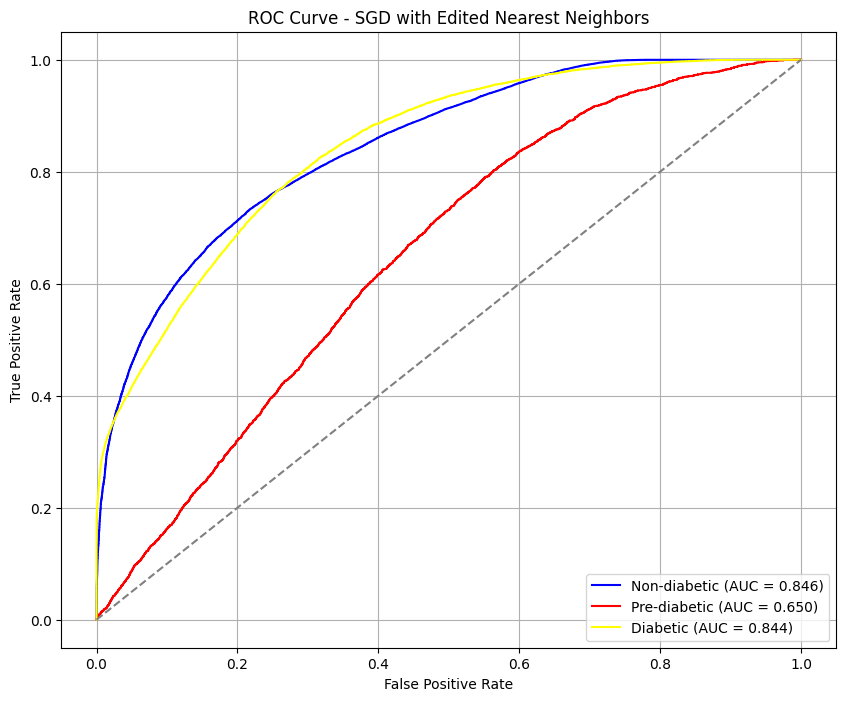

In [52]:
# Plot ROC and AUC of SGD model with Edited Nearest Neighbors method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=enn_class_probabilities["SGDClassifier"],
    model_name="SGD with Edited Nearest Neighbors"
)

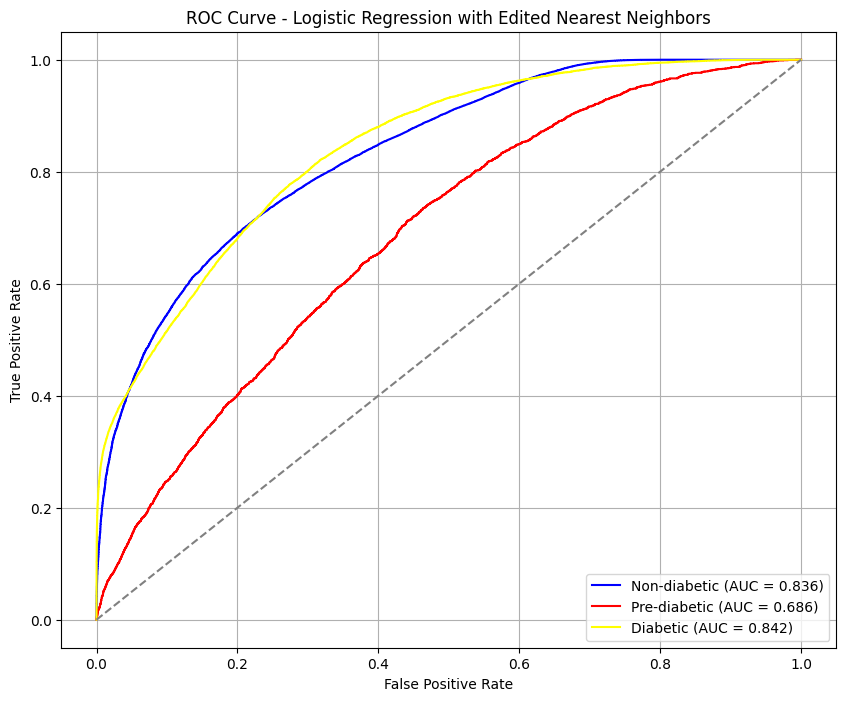

In [53]:
# Plot ROC and AUC of Logistic Regression model with Edited Nearest Neighbors method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=enn_class_probabilities["LogisticRegression"],
    model_name="Logistic Regression with Edited Nearest Neighbors"
)

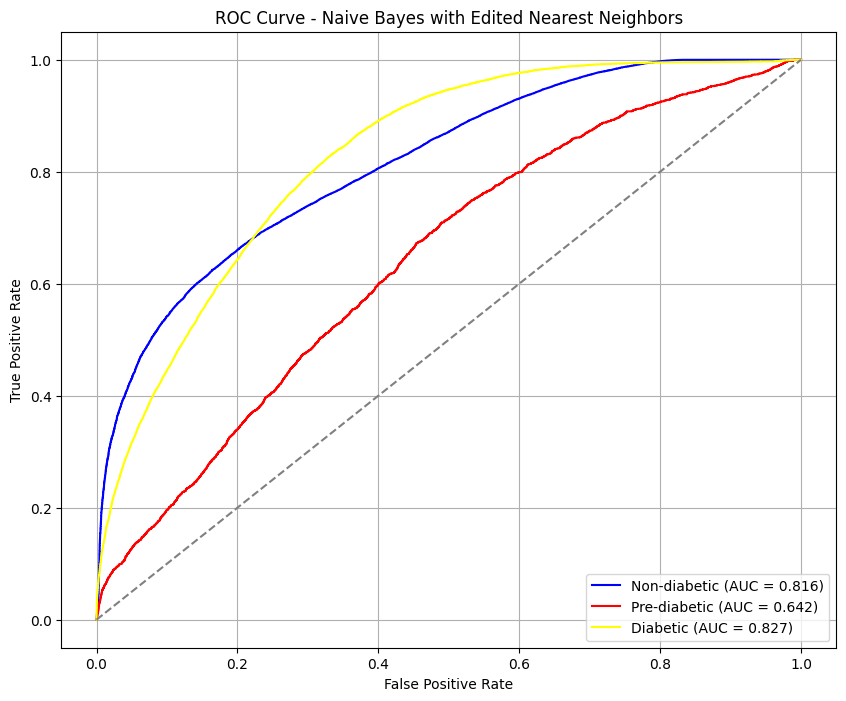

In [54]:
# Plot ROC and AUC of Naive Bayes model with Edited Nearest Neighbors method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=enn_class_probabilities["NaiveBayes"],
    model_name="Naive Bayes with Edited Nearest Neighbors"
)

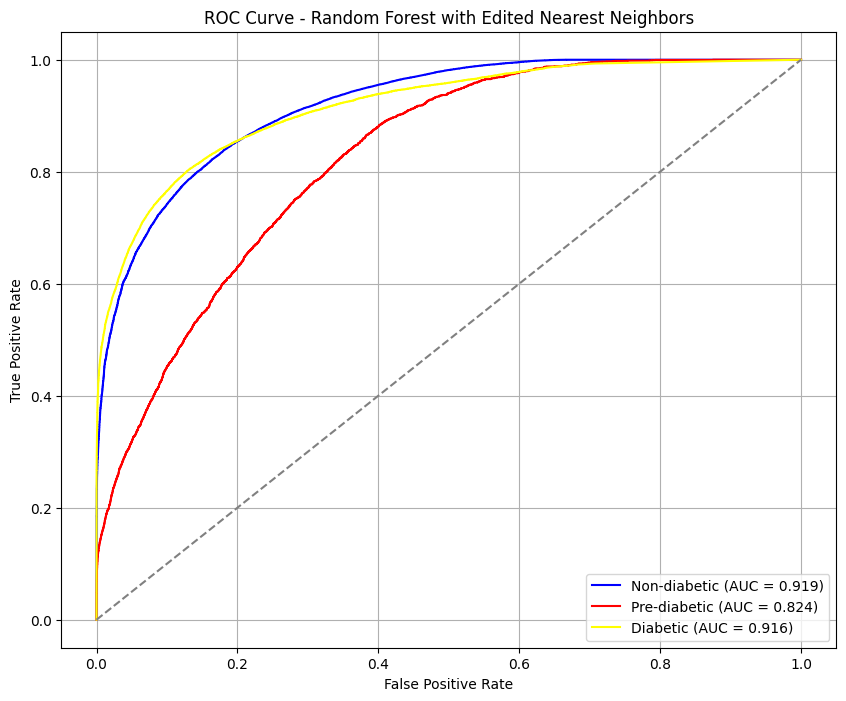

In [55]:
# Plot ROC and AUC of Random Forest model with Edited Nearest Neighbors method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=enn_class_probabilities["RandomForest"],
    model_name="Random Forest with Edited Nearest Neighbors"
)

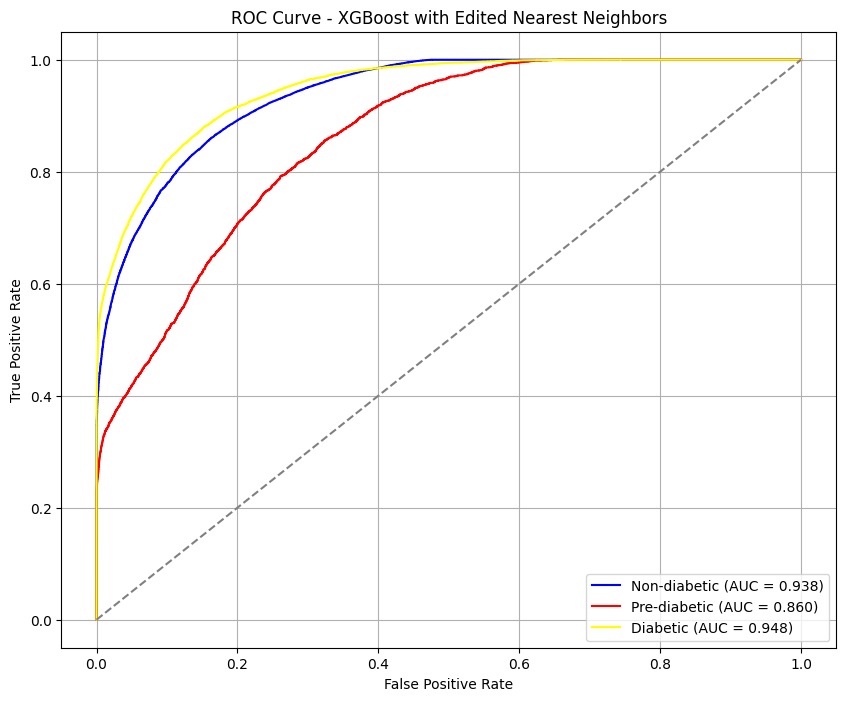

In [56]:
# Plot ROC and AUC of XGBoost model with Edited Nearest Neighbors method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=enn_class_probabilities["XGBoost"],
    model_name="XGBoost with Edited Nearest Neighbors"
)

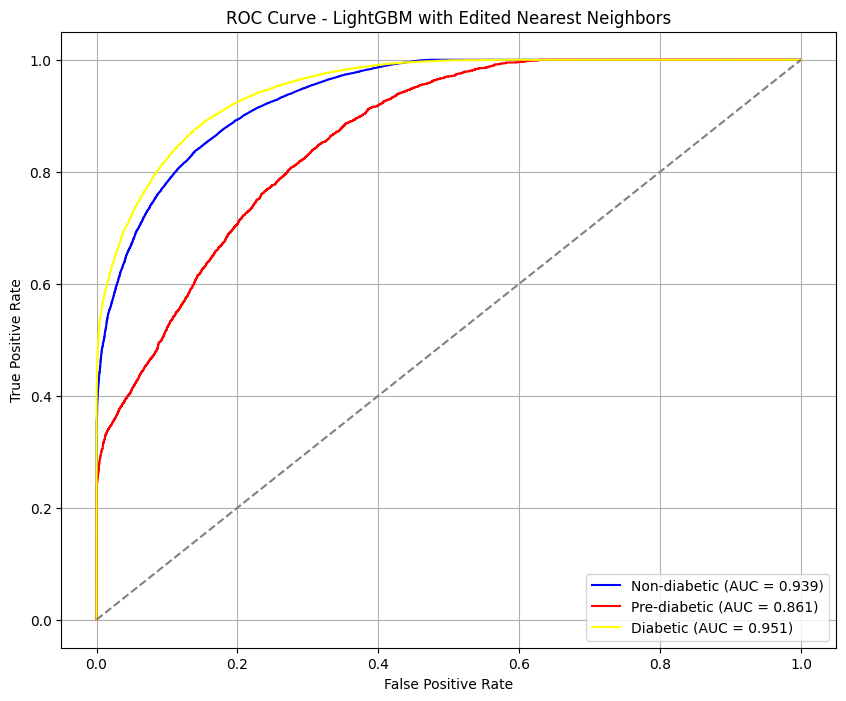

In [57]:
# Plot ROC and AUC of LightGBM model with Edited Nearest Neighbors method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=enn_class_probabilities["LightGBM"],
    model_name="LightGBM with Edited Nearest Neighbors"
)

### **2.7 SMOTE + Tomek Links**

In [58]:
# Train and get evaluation results with the SMOTE + Tomek Links method
smote_tomek_evaluation_results, smote_tomek_class_probabilities, smote_tomek_models = train_evaluate_all_models(
    X_train=smote_tomek_X_train_scaled,
    y_train=smote_tomek_y_train, 
    X_test=smote_tomek_X_test_scaled, 
    y_test=y_test, 
    method_name="SMOTE + Tomek Links"
)

2025-09-27 22:31:45,848 - [smote_+_tomek_links.sgd_classifier] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-09-27 22:31:45,849 - [smote_+_tomek_links.sgd_classifier] - INFO -   loss: log_loss
2025-09-27 22:31:45,850 - [smote_+_tomek_links.sgd_classifier] - INFO -   penalty: l2
2025-09-27 22:31:45,851 - [smote_+_tomek_links.sgd_classifier] - INFO -   alpha: 0.0001
2025-09-27 22:31:45,853 - [smote_+_tomek_links.sgd_classifier] - INFO -   learning_rate: constant
2025-09-27 22:31:45,854 - [smote_+_tomek_links.sgd_classifier] - INFO -   eta0: 0.01
2025-09-27 22:31:45,855 - [smote_+_tomek_links.sgd_classifier] - INFO -   max_iter: 1000
2025-09-27 22:31:45,856 - [smote_+_tomek_links.sgd_classifier] - INFO -   random_state: 42
2025-09-27 22:31:45,857 - [smote_+_tomek_links.logistic_regression] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-09-27 22:31:45,858 - [smote_+_tomek_links.logistic_regression] - INFO -   C: 1.0
2025-09-27 22:31:45,859 - [smote

Training SGDClassifier on SMOTE + Tomek Links data...


2025-09-27 22:31:47,496 - [smote_+_tomek_links.sgd_classifier] - INFO - Model training completed. Training samples: 425286
2025-09-27 22:31:47,497 - [smote_+_tomek_links.sgd_classifier] - INFO - Number of iterations: 7
2025-09-27 22:31:47,510 - [smote_+_tomek_links.sgd_classifier] - INFO - Predictions made for 89841 samples
2025-09-27 22:31:47,604 - [smote_+_tomek_links.sgd_classifier] - INFO - Model Evaluation Results:
2025-09-27 22:31:47,608 - [smote_+_tomek_links.sgd_classifier] - INFO - Accuracy: 0.8266
2025-09-27 22:31:47,609 - [smote_+_tomek_links.sgd_classifier] - INFO - Precision: 0.6020
2025-09-27 22:31:47,611 - [smote_+_tomek_links.sgd_classifier] - INFO - Recall: 0.4656
2025-09-27 22:31:47,611 - [smote_+_tomek_links.sgd_classifier] - INFO - F1-Score: 0.4740
2025-09-27 22:31:47,657 - [smote_+_tomek_links.sgd_classifier] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.94      0.90     70854
         1.0     

Training LogisticRegression on SMOTE + Tomek Links data...


2025-09-27 22:33:11,768 - [smote_+_tomek_links.logistic_regression] - INFO - Model training completed. Training samples: 425286
2025-09-27 22:33:11,790 - [smote_+_tomek_links.logistic_regression] - INFO - Predictions made for 89841 samples
2025-09-27 22:33:11,893 - [smote_+_tomek_links.logistic_regression] - INFO - Model Evaluation Results:
2025-09-27 22:33:11,897 - [smote_+_tomek_links.logistic_regression] - INFO - Accuracy: 0.8218
2025-09-27 22:33:11,898 - [smote_+_tomek_links.logistic_regression] - INFO - Precision: 0.5846
2025-09-27 22:33:11,903 - [smote_+_tomek_links.logistic_regression] - INFO - Recall: 0.4758
2025-09-27 22:33:11,904 - [smote_+_tomek_links.logistic_regression] - INFO - F1-Score: 0.4839
2025-09-27 22:33:11,996 - [smote_+_tomek_links.logistic_regression] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.93      0.90     70854
         1.0       0.31      0.01      0.03      2397
         2.0       

...

2025-09-27 22:46:48,604 - [smote_+_tomek_links.xgboost] - INFO - Model training completed. Training samples: 425286
2025-09-27 22:46:48,823 - [smote_+_tomek_links.xgboost] - INFO - Predictions made for 89841 samples
2025-09-27 22:46:48,860 - [smote_+_tomek_links.xgboost] - INFO - Model Evaluation Results:
2025-09-27 22:46:48,861 - [smote_+_tomek_links.xgboost] - INFO - Accuracy: 0.8998
2025-09-27 22:46:48,862 - [smote_+_tomek_links.xgboost] - INFO - Precision: 0.9087
2025-09-27 22:46:48,862 - [smote_+_tomek_links.xgboost] - INFO - Recall: 0.6251
2025-09-27 22:46:48,864 - [smote_+_tomek_links.xgboost] - INFO - F1-Score: 0.6883
2025-09-27 22:46:48,902 - [smote_+_tomek_links.xgboost] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.98      0.94     70854
         1.0       0.97      0.24      0.38      2397
         2.0       0.85      0.66      0.74     16590

    accuracy                           0.90     89841
   mac

Training LightGBM on SMOTE + Tomek Links data...
[LightGBM] [Info] Total Bins 8411
[LightGBM] [Info] Number of data points in the train set: 425286, number of used features: 33
[LightGBM] [Info] Start training from score -0.420160
[LightGBM] [Info] Start training from score -2.145008
[LightGBM] [Info] Start training from score -1.487258


2025-09-27 22:48:00,316 - [smote_+_tomek_links.lightgbm] - INFO - Model training completed. Training samples: 425286
2025-09-27 22:48:01,155 - [smote_+_tomek_links.lightgbm] - INFO - Predictions made for 89841 samples
2025-09-27 22:48:01,196 - [smote_+_tomek_links.lightgbm] - INFO - Model Evaluation Results:
2025-09-27 22:48:01,197 - [smote_+_tomek_links.lightgbm] - INFO - Accuracy: 0.9009
2025-09-27 22:48:01,198 - [smote_+_tomek_links.lightgbm] - INFO - Precision: 0.9113
2025-09-27 22:48:01,200 - [smote_+_tomek_links.lightgbm] - INFO - Recall: 0.6247
2025-09-27 22:48:01,201 - [smote_+_tomek_links.lightgbm] - INFO - F1-Score: 0.6902
2025-09-27 22:48:01,240 - [smote_+_tomek_links.lightgbm] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.98      0.94     70854
         1.0       0.97      0.24      0.39      2397
         2.0       0.86      0.65      0.74     16590

    accuracy                           0.90     8984

[LightGBM] [Info] Total Bins 8412
[LightGBM] [Info] Number of data points in the train set: 340228, number of used features: 33
[LightGBM] [Info] Start training from score -0.420160
[LightGBM] [Info] Start training from score -2.145021
[LightGBM] [Info] Start training from score -1.487253
[LightGBM] [Info] Total Bins 8412
[LightGBM] [Info] Number of data points in the train set: 340229, number of used features: 33
[LightGBM] [Info] Start training from score -0.420163
[LightGBM] [Info] Start training from score -2.144999
[LightGBM] [Info] Start training from score -1.487256
[LightGBM] [Info] Total Bins 8412
[LightGBM] [Info] Number of data points in the train set: 340229, number of used features: 33
[LightGBM] [Info] Start training from score -0.420163
[LightGBM] [Info] Start training from score -2.144999
[LightGBM] [Info] Start training from score -1.487256
[LightGBM] [Info] Total Bins 8410
[LightGBM] [Info] Number of data points in the train set: 340229, number of used features: 33
[L

2025-09-27 22:48:47,314 - [smote_+_tomek_links.lightgbm] - INFO - Cross-validation results:
2025-09-27 22:48:47,318 - [smote_+_tomek_links.lightgbm] - INFO - Mean accuracy: 0.8844 (+/- 0.0571)
2025-09-27 22:48:47,342 - [smote_+_tomek_links.sgd_classifier] - INFO - Predictions made for 89841 samples
2025-09-27 22:48:47,395 - [smote_+_tomek_links.sgd_classifier] - INFO - Probabilities predicted for 89841 samples
2025-09-27 22:48:47,652 - [smote_+_tomek_links.logistic_regression] - INFO - Predictions made for 89841 samples
2025-09-27 22:48:47,682 - [smote_+_tomek_links.logistic_regression] - INFO - Probabilities predicted for 89841 samples
2025-09-27 22:48:47,924 - [smote_+_tomek_links.naive_bayes] - INFO - Predictions made for 89841 samples
2025-09-27 22:48:47,987 - [smote_+_tomek_links.naive_bayes] - INFO - Probabilities predicted for 89841 samples
2025-09-27 22:48:50,140 - [smote_+_tomek_links.random_forest] - INFO - Predictions made for 89841 samples
2025-09-27 22:48:52,065 - [smote_+

In [59]:
# The evaluation result of all models with the SMOTE + Tomek Links method
smote_tomek_evaluation_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2,CV Mean,CV Std
0,SGDClassifier,0.8266,0.6020,0.4656,0.4740,0.7929,0.8607,0.3333,0.6120,0.9415,0.0004,0.4550,0.8993,0.0008,0.5219,0.725117,0.001009
1,LogisticRegression,0.8218,0.5846,0.4758,0.4839,0.7985,0.8663,0.3056,0.5819,0.9279,0.0138,0.4856,0.8961,0.0263,0.5294,0.726053,0.000535
2,NaiveBayes,0.7073,0.4682,0.5102,0.4690,0.7603,0.9021,0.0534,0.4489,0.7593,0.2149,0.5564,0.8246,0.0856,0.4969,0.651225,0.006434
3,RandomForest,0.8640,0.7209,0.6566,0.6642,0.9079,0.9403,0.5879,0.6345,0.8969,0.2624,0.8105,0.9181,0.3628,0.7118,0.857501,0.026309
4,XGBoost,0.8998,0.9087,0.6251,0.6883,0.9211,0.9085,0.9727,0.8450,0.9785,0.2378,0.6591,0.9422,0.3822,0.7406,0.872089,0.023197
5,LightGBM,0.9009,0.9113,0.6247,0.6902,0.9231,0.9070,0.9666,0.8603,0.9817,0.2416,0.6508,0.9429,0.3865,0.7410,0.884353,0.028564


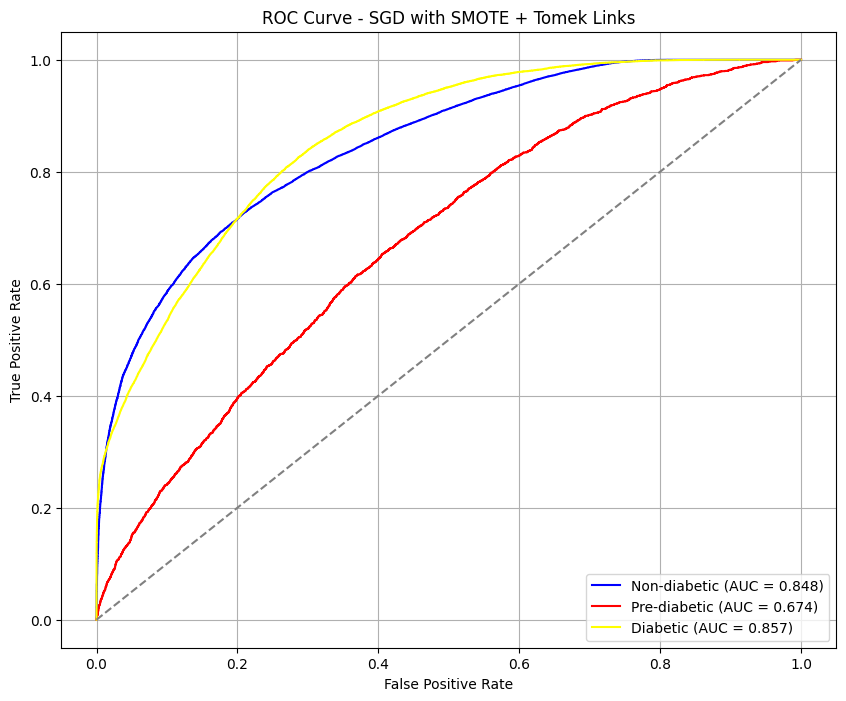

In [60]:
# Plot ROC and AUC of SGD model with SMOTE + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_tomek_class_probabilities["SGDClassifier"],
    model_name="SGD with SMOTE + Tomek Links"
)

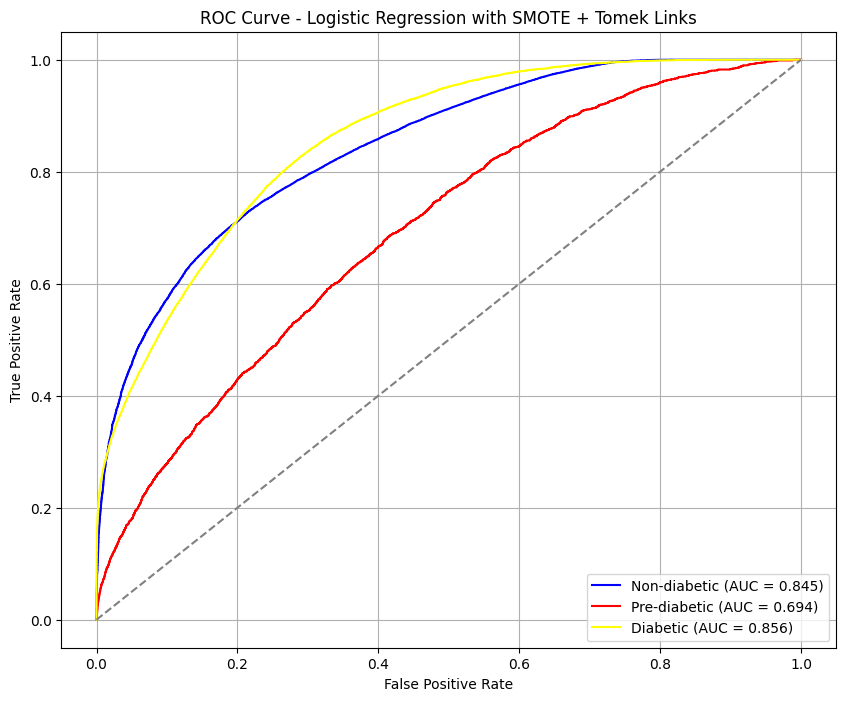

In [61]:
# Plot ROC and AUC of Logistic Regression model with SMOTE + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_tomek_class_probabilities["LogisticRegression"],
    model_name="Logistic Regression with SMOTE + Tomek Links"
)

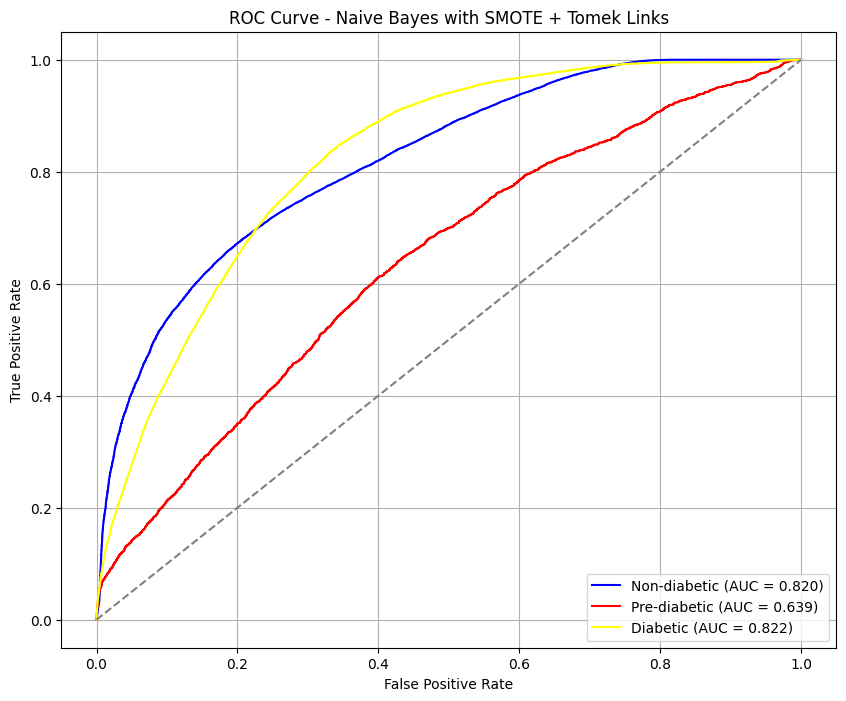

In [62]:
# Plot ROC and AUC of Naive Bayes model with SMOTE + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_tomek_class_probabilities["NaiveBayes"],
    model_name="Naive Bayes with SMOTE + Tomek Links"
)

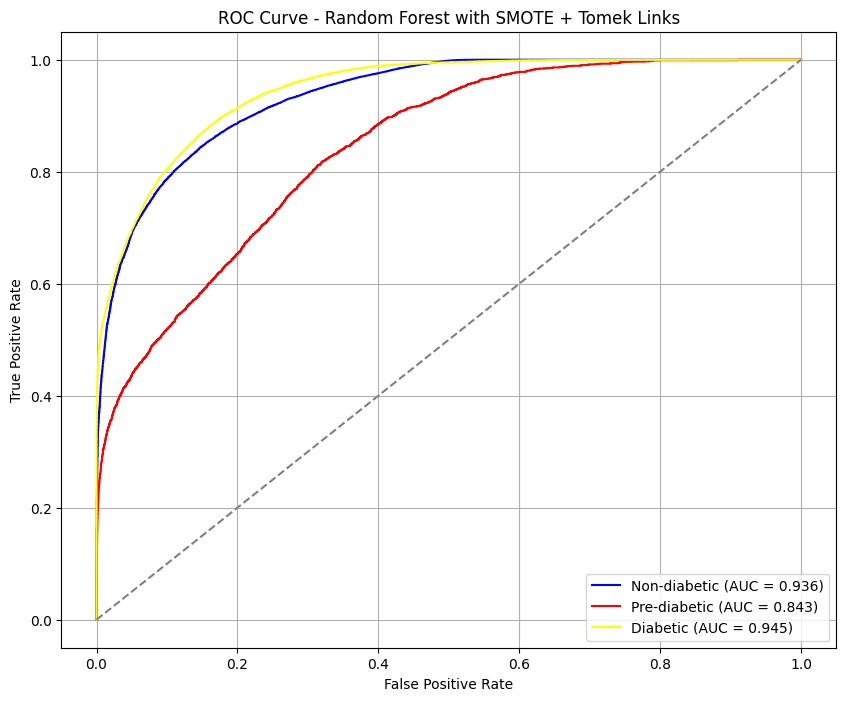

In [63]:
# Plot ROC and AUC of Random Forest model with SMOTE + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_tomek_class_probabilities["RandomForest"],
    model_name="Random Forest with SMOTE + Tomek Links"
)

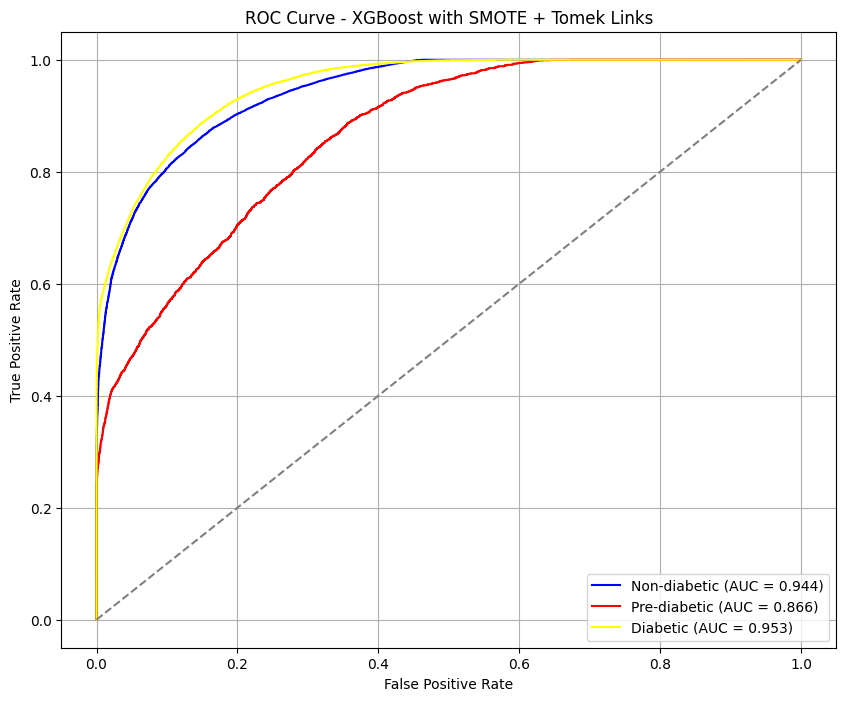

In [64]:
# Plot ROC and AUC of XGBoost model with SMOTE + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_tomek_class_probabilities["XGBoost"],
    model_name="XGBoost with SMOTE + Tomek Links"
)

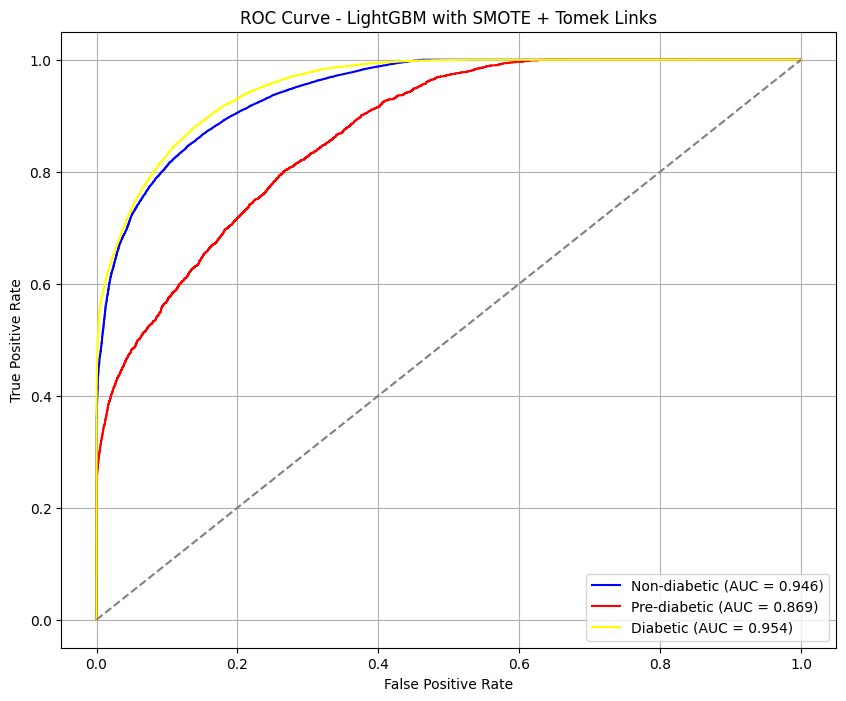

In [65]:
# Plot ROC and AUC of LightGBM model with SMOTE + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_tomek_class_probabilities["LightGBM"],
    model_name="LightGBM with SMOTE + Tomek Links"
)

### **2.8 SMOTE + ENN**

In [66]:
# Train and get evaluation results with the SMOTE + ENN method
smote_enn_evaluation_results, smote_enn_class_probabilities, smote_enn_models = train_evaluate_all_models(
    X_train=smote_enn_X_train_scaled,
    y_train=smote_enn_y_train, 
    X_test=smote_enn_X_test_scaled, 
    y_test=y_test, 
    method_name="SMOTE + ENN"
)

2025-09-27 22:48:56,520 - [smote_+_enn.sgd_classifier] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-09-27 22:48:56,520 - [smote_+_enn.sgd_classifier] - INFO -   loss: log_loss
2025-09-27 22:48:56,521 - [smote_+_enn.sgd_classifier] - INFO -   penalty: l2
2025-09-27 22:48:56,522 - [smote_+_enn.sgd_classifier] - INFO -   alpha: 0.0001
2025-09-27 22:48:56,523 - [smote_+_enn.sgd_classifier] - INFO -   learning_rate: constant
2025-09-27 22:48:56,523 - [smote_+_enn.sgd_classifier] - INFO -   eta0: 0.01
2025-09-27 22:48:56,524 - [smote_+_enn.sgd_classifier] - INFO -   max_iter: 1000
2025-09-27 22:48:56,525 - [smote_+_enn.sgd_classifier] - INFO -   random_state: 42
2025-09-27 22:48:56,526 - [smote_+_enn.logistic_regression] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-09-27 22:48:56,527 - [smote_+_enn.logistic_regression] - INFO -   C: 1.0
2025-09-27 22:48:56,528 - [smote_+_enn.logistic_regression] - INFO -   penalty: l2
2025-09-27 22:48:56,529 - [sm

Training SGDClassifier on SMOTE + ENN data...


2025-09-27 22:48:57,740 - [smote_+_enn.sgd_classifier] - INFO - Model training completed. Training samples: 305489
2025-09-27 22:48:57,741 - [smote_+_enn.sgd_classifier] - INFO - Number of iterations: 7
2025-09-27 22:48:57,754 - [smote_+_enn.sgd_classifier] - INFO - Predictions made for 89841 samples
2025-09-27 22:48:57,801 - [smote_+_enn.sgd_classifier] - INFO - Model Evaluation Results:
2025-09-27 22:48:57,802 - [smote_+_enn.sgd_classifier] - INFO - Accuracy: 0.7926
2025-09-27 22:48:57,803 - [smote_+_enn.sgd_classifier] - INFO - Precision: 0.5532
2025-09-27 22:48:57,804 - [smote_+_enn.sgd_classifier] - INFO - Recall: 0.4683
2025-09-27 22:48:57,804 - [smote_+_enn.sgd_classifier] - INFO - F1-Score: 0.4785
2025-09-27 22:48:57,849 - [smote_+_enn.sgd_classifier] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.92      0.89     70854
         1.0       0.05      0.14      0.07      2397
         2.0       0.74      0.35  

Training LogisticRegression on SMOTE + ENN data...


2025-09-27 22:49:55,597 - [smote_+_enn.logistic_regression] - INFO - Model training completed. Training samples: 305489
2025-09-27 22:49:55,610 - [smote_+_enn.logistic_regression] - INFO - Predictions made for 89841 samples
2025-09-27 22:49:55,651 - [smote_+_enn.logistic_regression] - INFO - Model Evaluation Results:
2025-09-27 22:49:55,653 - [smote_+_enn.logistic_regression] - INFO - Accuracy: 0.8127
2025-09-27 22:49:55,654 - [smote_+_enn.logistic_regression] - INFO - Precision: 0.5143
2025-09-27 22:49:55,656 - [smote_+_enn.logistic_regression] - INFO - Recall: 0.4843
2025-09-27 22:49:55,658 - [smote_+_enn.logistic_regression] - INFO - F1-Score: 0.4964
2025-09-27 22:49:55,702 - [smote_+_enn.logistic_regression] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.92      0.89     70854
         1.0       0.08      0.06      0.07      2397
         2.0       0.59      0.47      0.53     16590

    accuracy                

...

2025-09-27 22:57:10,239 - [smote_+_enn.xgboost] - INFO - Model training completed. Training samples: 305489
2025-09-27 22:57:10,413 - [smote_+_enn.xgboost] - INFO - Predictions made for 89841 samples
2025-09-27 22:57:10,452 - [smote_+_enn.xgboost] - INFO - Model Evaluation Results:
2025-09-27 22:57:10,453 - [smote_+_enn.xgboost] - INFO - Accuracy: 0.8888
2025-09-27 22:57:10,454 - [smote_+_enn.xgboost] - INFO - Precision: 0.7671
2025-09-27 22:57:10,455 - [smote_+_enn.xgboost] - INFO - Recall: 0.6453
2025-09-27 22:57:10,457 - [smote_+_enn.xgboost] - INFO - F1-Score: 0.6828
2025-09-27 22:57:10,495 - [smote_+_enn.xgboost] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.95      0.94     70854
         1.0       0.62      0.27      0.38      2397
         2.0       0.76      0.71      0.73     16590

    accuracy                           0.89     89841
   macro avg       0.77      0.65      0.68     89841
weighted avg    

Training LightGBM on SMOTE + ENN data...
[LightGBM] [Info] Total Bins 8411
[LightGBM] [Info] Number of data points in the train set: 305489, number of used features: 33
[LightGBM] [Info] Start training from score -0.401879
[LightGBM] [Info] Start training from score -1.913764
[LightGBM] [Info] Start training from score -1.696009


2025-09-27 22:57:46,893 - [smote_+_enn.lightgbm] - INFO - Model training completed. Training samples: 305489
2025-09-27 22:57:47,808 - [smote_+_enn.lightgbm] - INFO - Predictions made for 89841 samples
2025-09-27 22:57:47,846 - [smote_+_enn.lightgbm] - INFO - Model Evaluation Results:
2025-09-27 22:57:47,846 - [smote_+_enn.lightgbm] - INFO - Accuracy: 0.8931
2025-09-27 22:57:47,847 - [smote_+_enn.lightgbm] - INFO - Precision: 0.7997
2025-09-27 22:57:47,848 - [smote_+_enn.lightgbm] - INFO - Recall: 0.6493
2025-09-27 22:57:47,849 - [smote_+_enn.lightgbm] - INFO - F1-Score: 0.6922
2025-09-27 22:57:47,888 - [smote_+_enn.lightgbm] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94     70854
         1.0       0.71      0.27      0.40      2397
         2.0       0.77      0.72      0.74     16590

    accuracy                           0.89     89841
   macro avg       0.80      0.65      0.69     89841
weighted

[LightGBM] [Info] Total Bins 8413
[LightGBM] [Info] Number of data points in the train set: 244391, number of used features: 33
[LightGBM] [Info] Start training from score -0.401883
[LightGBM] [Info] Start training from score -1.913752
[LightGBM] [Info] Start training from score -1.696003
[LightGBM] [Info] Total Bins 8412
[LightGBM] [Info] Number of data points in the train set: 244391, number of used features: 33
[LightGBM] [Info] Start training from score -0.401877
[LightGBM] [Info] Start training from score -1.913779
[LightGBM] [Info] Start training from score -1.696003
[LightGBM] [Info] Total Bins 8412
[LightGBM] [Info] Number of data points in the train set: 244391, number of used features: 33
[LightGBM] [Info] Start training from score -0.401877
[LightGBM] [Info] Start training from score -1.913779
[LightGBM] [Info] Start training from score -1.696003
[LightGBM] [Info] Total Bins 8410
[LightGBM] [Info] Number of data points in the train set: 244391, number of used features: 33
[L

2025-09-27 22:58:22,399 - [smote_+_enn.lightgbm] - INFO - Cross-validation results:
2025-09-27 22:58:22,401 - [smote_+_enn.lightgbm] - INFO - Mean accuracy: 0.9360 (+/- 0.0581)
2025-09-27 22:58:22,418 - [smote_+_enn.sgd_classifier] - INFO - Predictions made for 89841 samples
2025-09-27 22:58:22,441 - [smote_+_enn.sgd_classifier] - INFO - Probabilities predicted for 89841 samples
2025-09-27 22:58:22,737 - [smote_+_enn.logistic_regression] - INFO - Predictions made for 89841 samples
2025-09-27 22:58:22,766 - [smote_+_enn.logistic_regression] - INFO - Probabilities predicted for 89841 samples
2025-09-27 22:58:23,021 - [smote_+_enn.naive_bayes] - INFO - Predictions made for 89841 samples
2025-09-27 22:58:23,072 - [smote_+_enn.naive_bayes] - INFO - Probabilities predicted for 89841 samples
2025-09-27 22:58:24,779 - [smote_+_enn.random_forest] - INFO - Predictions made for 89841 samples
2025-09-27 22:58:26,243 - [smote_+_enn.random_forest] - INFO - Probabilities predicted for 89841 samples
2

In [67]:
# The evaluation result of all models with the SMOTE + ENN method
smote_enn_evaluation_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2,CV Mean,CV Std
0,SGDClassifier,0.7926,0.5532,0.4683,0.4785,0.7874,0.8676,0.0476,0.7445,0.9195,0.1402,0.3451,0.8928,0.0711,0.4716,0.761068,0.008032
1,LogisticRegression,0.8127,0.5143,0.4843,0.4964,0.7944,0.8701,0.0786,0.5942,0.9178,0.0630,0.4720,0.8933,0.0699,0.5261,0.764276,0.009324
2,NaiveBayes,0.6720,0.4759,0.5135,0.4580,0.7602,0.9144,0.0475,0.4656,0.7238,0.3141,0.5027,0.8080,0.0825,0.4834,0.697452,0.010421
3,RandomForest,0.8468,0.6042,0.6583,0.6263,0.8948,0.9358,0.2252,0.6518,0.8852,0.3325,0.7572,0.9098,0.2685,0.7005,0.927608,0.025792
4,XGBoost,0.8888,0.7671,0.6453,0.6828,0.9149,0.9210,0.6239,0.7563,0.9509,0.2720,0.7129,0.9357,0.3788,0.7340,0.925863,0.026095
5,LightGBM,0.8931,0.7997,0.6493,0.6922,0.9192,0.9217,0.7086,0.7688,0.9551,0.2749,0.7179,0.9381,0.3962,0.7425,0.936037,0.029046


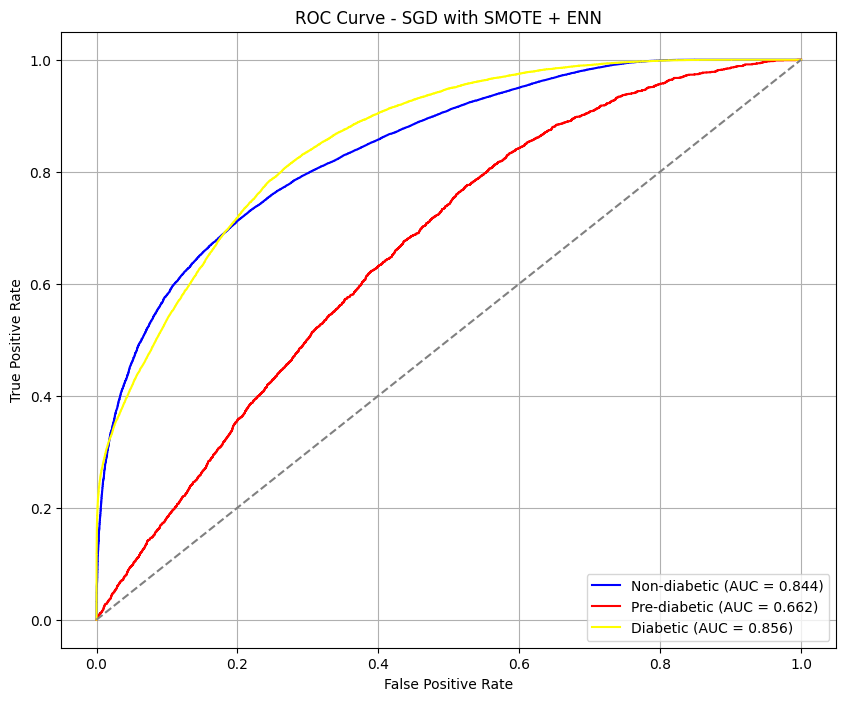

In [68]:
# Plot ROC and AUC of SGD Classifier model with SMOTE + ENN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_enn_class_probabilities["SGDClassifier"],
    model_name="SGD with SMOTE + ENN"
)

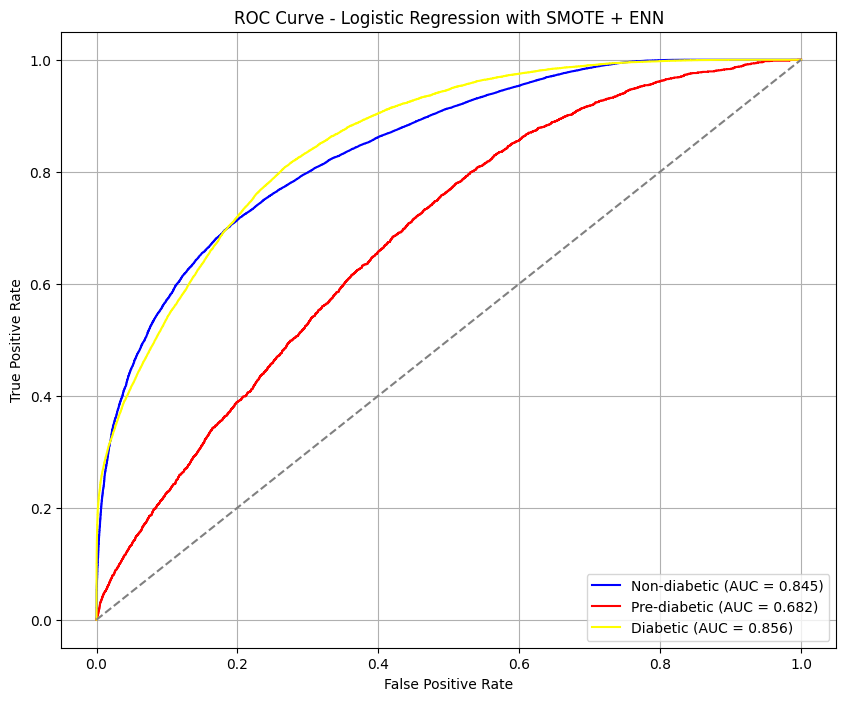

In [69]:
# Plot ROC and AUC of Logistic Regression model with SMOTE + ENN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_enn_class_probabilities["LogisticRegression"],
    model_name="Logistic Regression with SMOTE + ENN"
)

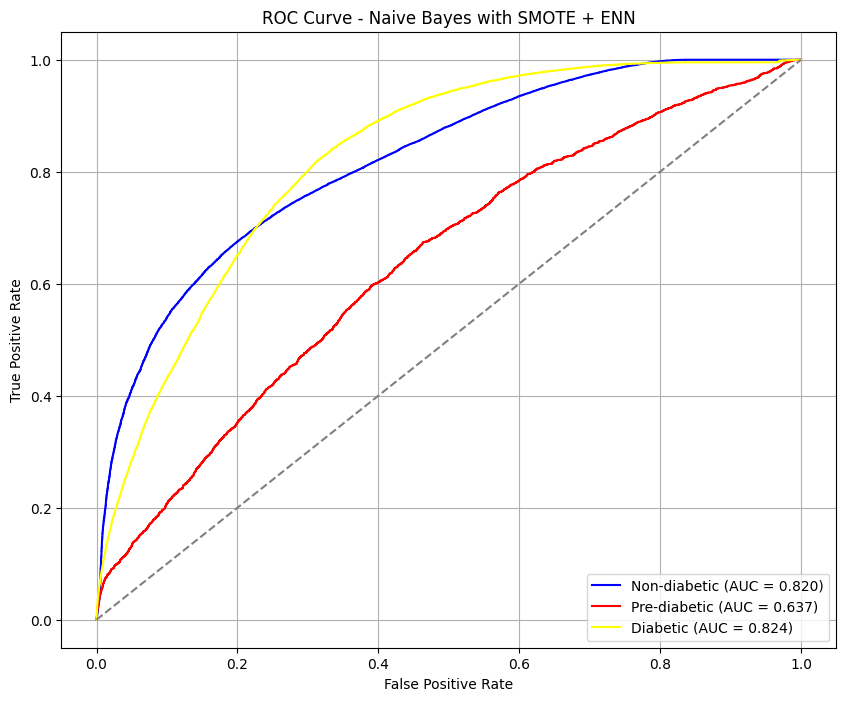

In [70]:
# Plot ROC and AUC of Naive Bayes model with SMOTE + ENN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_enn_class_probabilities["NaiveBayes"],
    model_name="Naive Bayes with SMOTE + ENN"
)

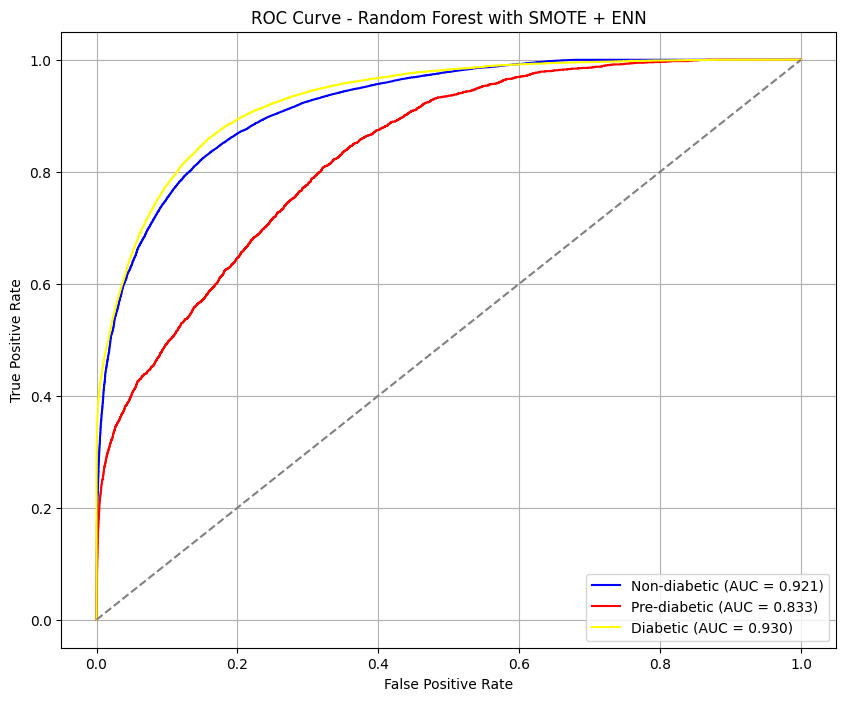

In [71]:
# Plot ROC and AUC of Random Forest model with SMOTE + ENN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_enn_class_probabilities["RandomForest"],
    model_name="Random Forest with SMOTE + ENN"
)

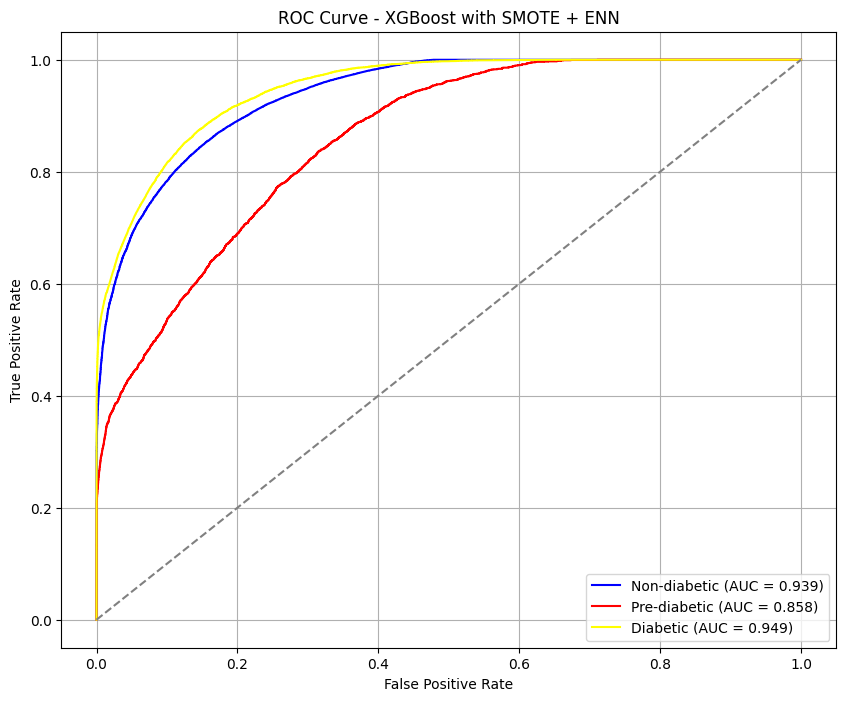

In [72]:
# Plot ROC and AUC of XGBoost model with SMOTE + ENN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_enn_class_probabilities["XGBoost"],
    model_name="XGBoost with SMOTE + ENN"
)

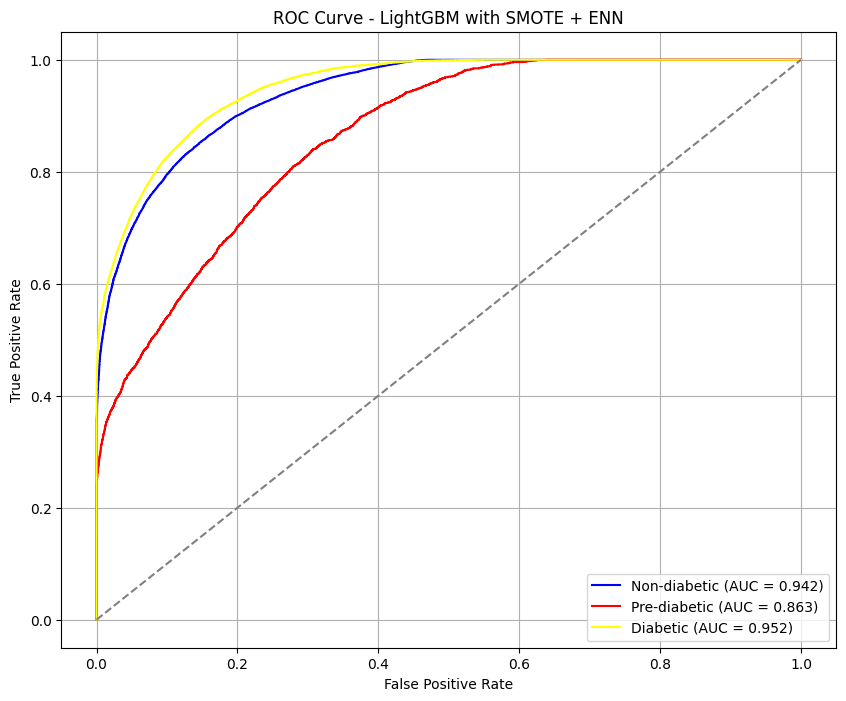

In [73]:
# Plot ROC and AUC of LightGBM model with SMOTE + ENN method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=smote_enn_class_probabilities["LightGBM"],
    model_name="LightGBM with SMOTE + ENN"
)

### **2.9 ADASYN + Tomek Links**

In [74]:
# Train and get evaluation results with the ADASYN + Tomek Links method
adasyn_tomek_evaluation_results, adasyn_tomek_class_probabilities, adasyn_tomek_models = train_evaluate_all_models(
    X_train=adasyn_tomek_X_train_scaled,
    y_train=adasyn_tomek_y_train, 
    X_test=adasyn_tomek_X_test_scaled, 
    y_test=y_test, 
    method_name="ADASYN + Tomek Links"
)

2025-09-27 22:58:30,737 - [adasyn_+_tomek_links.sgd_classifier] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-09-27 22:58:30,738 - [adasyn_+_tomek_links.sgd_classifier] - INFO -   loss: log_loss
2025-09-27 22:58:30,739 - [adasyn_+_tomek_links.sgd_classifier] - INFO -   penalty: l2
2025-09-27 22:58:30,740 - [adasyn_+_tomek_links.sgd_classifier] - INFO -   alpha: 0.0001
2025-09-27 22:58:30,741 - [adasyn_+_tomek_links.sgd_classifier] - INFO -   learning_rate: constant
2025-09-27 22:58:30,742 - [adasyn_+_tomek_links.sgd_classifier] - INFO -   eta0: 0.01
2025-09-27 22:58:30,743 - [adasyn_+_tomek_links.sgd_classifier] - INFO -   max_iter: 1000
2025-09-27 22:58:30,743 - [adasyn_+_tomek_links.sgd_classifier] - INFO -   random_state: 42
2025-09-27 22:58:30,745 - [adasyn_+_tomek_links.logistic_regression] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-09-27 22:58:30,746 - [adasyn_+_tomek_links.logistic_regression] - INFO -   C: 1.0
2025-09-27 22:58:30,74

Training SGDClassifier on ADASYN + Tomek Links data...


2025-09-27 22:58:32,473 - [adasyn_+_tomek_links.sgd_classifier] - INFO - Model training completed. Training samples: 425160
2025-09-27 22:58:32,474 - [adasyn_+_tomek_links.sgd_classifier] - INFO - Number of iterations: 7
2025-09-27 22:58:32,488 - [adasyn_+_tomek_links.sgd_classifier] - INFO - Predictions made for 89841 samples
2025-09-27 22:58:32,594 - [adasyn_+_tomek_links.sgd_classifier] - INFO - Model Evaluation Results:
2025-09-27 22:58:32,599 - [adasyn_+_tomek_links.sgd_classifier] - INFO - Accuracy: 0.8005
2025-09-27 22:58:32,600 - [adasyn_+_tomek_links.sgd_classifier] - INFO - Precision: 0.5427
2025-09-27 22:58:32,601 - [adasyn_+_tomek_links.sgd_classifier] - INFO - Recall: 0.4894
2025-09-27 22:58:32,602 - [adasyn_+_tomek_links.sgd_classifier] - INFO - F1-Score: 0.4762
2025-09-27 22:58:32,693 - [adasyn_+_tomek_links.sgd_classifier] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.88      0.88     70854
        

Training LogisticRegression on ADASYN + Tomek Links data...


2025-09-27 22:59:51,685 - [adasyn_+_tomek_links.logistic_regression] - INFO - Model training completed. Training samples: 425160
2025-09-27 22:59:51,694 - [adasyn_+_tomek_links.logistic_regression] - INFO - Predictions made for 89841 samples
2025-09-27 22:59:51,726 - [adasyn_+_tomek_links.logistic_regression] - INFO - Model Evaluation Results:
2025-09-27 22:59:51,727 - [adasyn_+_tomek_links.logistic_regression] - INFO - Accuracy: 0.8177
2025-09-27 22:59:51,728 - [adasyn_+_tomek_links.logistic_regression] - INFO - Precision: 0.5728
2025-09-27 22:59:51,729 - [adasyn_+_tomek_links.logistic_regression] - INFO - Recall: 0.4766
2025-09-27 22:59:51,730 - [adasyn_+_tomek_links.logistic_regression] - INFO - F1-Score: 0.4795
2025-09-27 22:59:51,764 - [adasyn_+_tomek_links.logistic_regression] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.92      0.89     70854
         1.0       0.29      0.01      0.01      2397
         2.

...

2025-09-27 23:10:24,755 - [adasyn_+_tomek_links.xgboost] - INFO - Model training completed. Training samples: 425160
2025-09-27 23:10:24,944 - [adasyn_+_tomek_links.xgboost] - INFO - Predictions made for 89841 samples
2025-09-27 23:10:24,988 - [adasyn_+_tomek_links.xgboost] - INFO - Model Evaluation Results:
2025-09-27 23:10:24,989 - [adasyn_+_tomek_links.xgboost] - INFO - Accuracy: 0.8988
2025-09-27 23:10:24,990 - [adasyn_+_tomek_links.xgboost] - INFO - Precision: 0.8931
2025-09-27 23:10:24,992 - [adasyn_+_tomek_links.xgboost] - INFO - Recall: 0.6278
2025-09-27 23:10:24,993 - [adasyn_+_tomek_links.xgboost] - INFO - F1-Score: 0.6879
2025-09-27 23:10:25,031 - [adasyn_+_tomek_links.xgboost] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.97      0.94     70854
         1.0       0.94      0.24      0.38      2397
         2.0       0.83      0.67      0.74     16590

    accuracy                           0.90     8984

Training LightGBM on ADASYN + Tomek Links data...
[LightGBM] [Info] Total Bins 8357
[LightGBM] [Info] Number of data points in the train set: 425160, number of used features: 33
[LightGBM] [Info] Start training from score -0.412991
[LightGBM] [Info] Start training from score -2.153447
[LightGBM] [Info] Start training from score -1.503961


2025-09-27 23:11:20,237 - [adasyn_+_tomek_links.lightgbm] - INFO - Model training completed. Training samples: 425160
2025-09-27 23:11:21,170 - [adasyn_+_tomek_links.lightgbm] - INFO - Predictions made for 89841 samples
2025-09-27 23:11:21,209 - [adasyn_+_tomek_links.lightgbm] - INFO - Model Evaluation Results:
2025-09-27 23:11:21,210 - [adasyn_+_tomek_links.lightgbm] - INFO - Accuracy: 0.9011
2025-09-27 23:11:21,211 - [adasyn_+_tomek_links.lightgbm] - INFO - Precision: 0.9167
2025-09-27 23:11:21,212 - [adasyn_+_tomek_links.lightgbm] - INFO - Recall: 0.6247
2025-09-27 23:11:21,213 - [adasyn_+_tomek_links.lightgbm] - INFO - F1-Score: 0.6902
2025-09-27 23:11:21,260 - [adasyn_+_tomek_links.lightgbm] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.98      0.94     70854
         1.0       0.98      0.24      0.39      2397
         2.0       0.86      0.65      0.74     16590

    accuracy                           0.90 

[LightGBM] [Info] Total Bins 8380
[LightGBM] [Info] Number of data points in the train set: 340128, number of used features: 33
[LightGBM] [Info] Start training from score -0.412991
[LightGBM] [Info] Start training from score -2.153426
[LightGBM] [Info] Start training from score -1.503972
[LightGBM] [Info] Total Bins 8366
[LightGBM] [Info] Number of data points in the train set: 340128, number of used features: 33
[LightGBM] [Info] Start training from score -0.412991
[LightGBM] [Info] Start training from score -2.153452
[LightGBM] [Info] Start training from score -1.503958
[LightGBM] [Info] Total Bins 8360
[LightGBM] [Info] Number of data points in the train set: 340128, number of used features: 33
[LightGBM] [Info] Start training from score -0.412991
[LightGBM] [Info] Start training from score -2.153452
[LightGBM] [Info] Start training from score -1.503958
[LightGBM] [Info] Total Bins 8347
[LightGBM] [Info] Number of data points in the train set: 340128, number of used features: 33
[L

2025-09-27 23:12:05,389 - [adasyn_+_tomek_links.lightgbm] - INFO - Cross-validation results:
2025-09-27 23:12:05,390 - [adasyn_+_tomek_links.lightgbm] - INFO - Mean accuracy: 0.8698 (+/- 0.0478)
2025-09-27 23:12:05,406 - [adasyn_+_tomek_links.sgd_classifier] - INFO - Predictions made for 89841 samples
2025-09-27 23:12:05,437 - [adasyn_+_tomek_links.sgd_classifier] - INFO - Probabilities predicted for 89841 samples
2025-09-27 23:12:05,647 - [adasyn_+_tomek_links.logistic_regression] - INFO - Predictions made for 89841 samples
2025-09-27 23:12:05,681 - [adasyn_+_tomek_links.logistic_regression] - INFO - Probabilities predicted for 89841 samples
2025-09-27 23:12:05,957 - [adasyn_+_tomek_links.naive_bayes] - INFO - Predictions made for 89841 samples
2025-09-27 23:12:06,011 - [adasyn_+_tomek_links.naive_bayes] - INFO - Probabilities predicted for 89841 samples
2025-09-27 23:12:07,900 - [adasyn_+_tomek_links.random_forest] - INFO - Predictions made for 89841 samples
2025-09-27 23:12:09,559 -

In [75]:
# The evaluation result of all models with the ADASYN + Tomek Links method
adasyn_tomek_evaluation_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2,CV Mean,CV Std
0,SGDClassifier,0.8005,0.5427,0.4894,0.4762,0.7853,0.8817,0.2414,0.5050,0.8772,0.0029,0.5881,0.8794,0.0058,0.5434,0.704765,0.022425
1,LogisticRegression,0.8177,0.5728,0.4766,0.4795,0.7973,0.8683,0.2857,0.5644,0.9185,0.0067,0.5046,0.8927,0.0130,0.5328,0.704768,0.022645
2,NaiveBayes,0.6799,0.4669,0.5136,0.4605,0.7561,0.9184,0.0476,0.4347,0.7191,0.2466,0.5750,0.8066,0.0798,0.4951,0.619896,0.023890
3,RandomForest,0.8516,0.7076,0.6567,0.6536,0.9077,0.9471,0.5789,0.5969,0.8741,0.2541,0.8418,0.9092,0.3531,0.6985,0.829911,0.034283
4,XGBoost,0.8988,0.8931,0.6278,0.6879,0.9209,0.9108,0.9393,0.8293,0.9748,0.2390,0.6696,0.9417,0.3811,0.7409,0.853563,0.022012
5,LightGBM,0.9011,0.9167,0.6247,0.6902,0.9233,0.9072,0.9829,0.8601,0.9817,0.2399,0.6524,0.9430,0.3856,0.7420,0.869755,0.023912


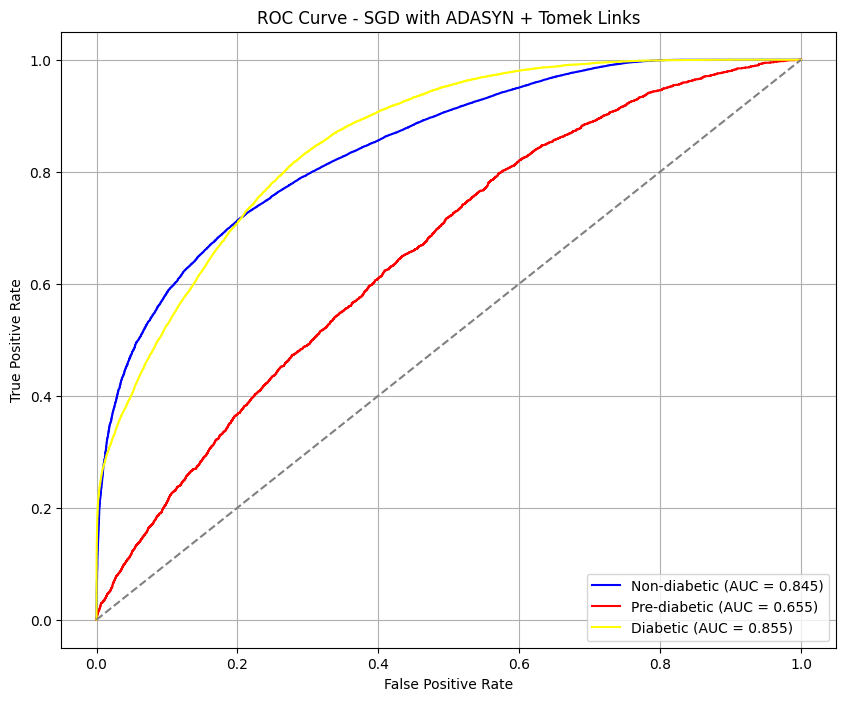

In [76]:
# Plot ROC and AUC of SGD Classifier model with ADASYN + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_tomek_class_probabilities["SGDClassifier"],
    model_name="SGD with ADASYN + Tomek Links"
)

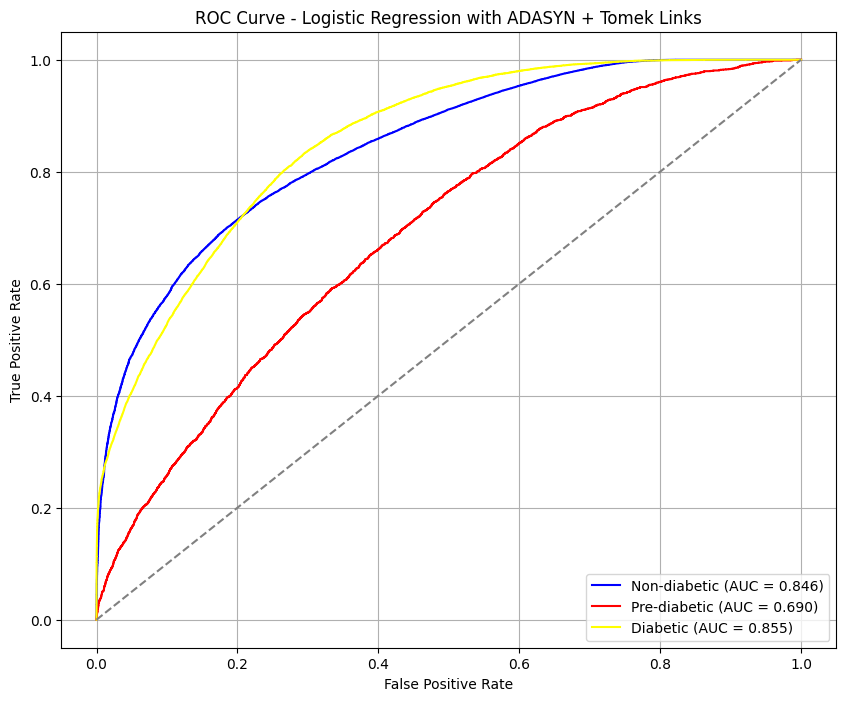

In [77]:
# Plot ROC and AUC of Logistic Regression model with ADASYN + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_tomek_class_probabilities["LogisticRegression"],
    model_name="Logistic Regression with ADASYN + Tomek Links"
)

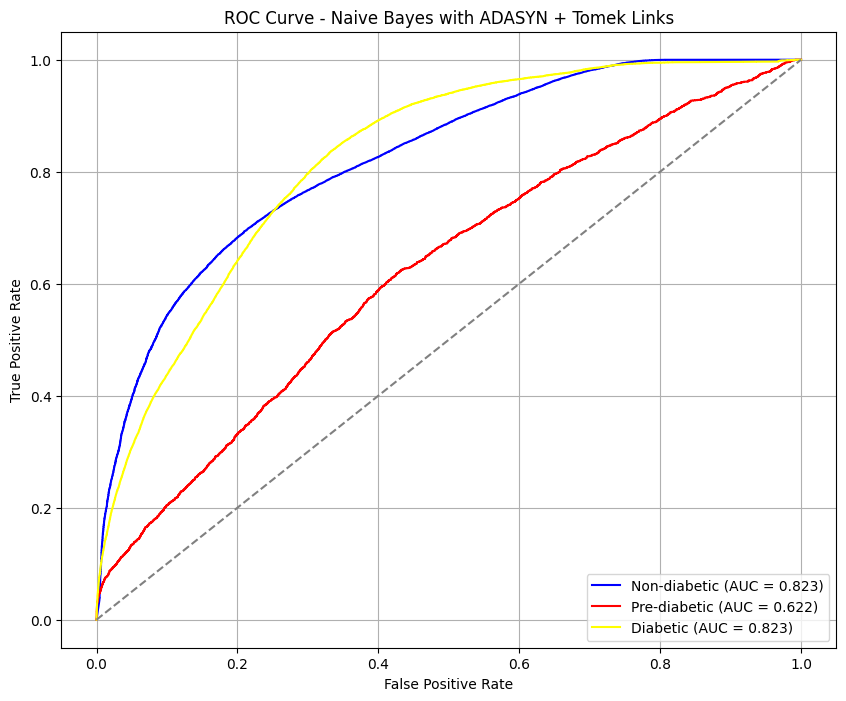

In [78]:
# Plot ROC and AUC of Naive Bayes model with ADASYN + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_tomek_class_probabilities["NaiveBayes"],
    model_name="Naive Bayes with ADASYN + Tomek Links"
)

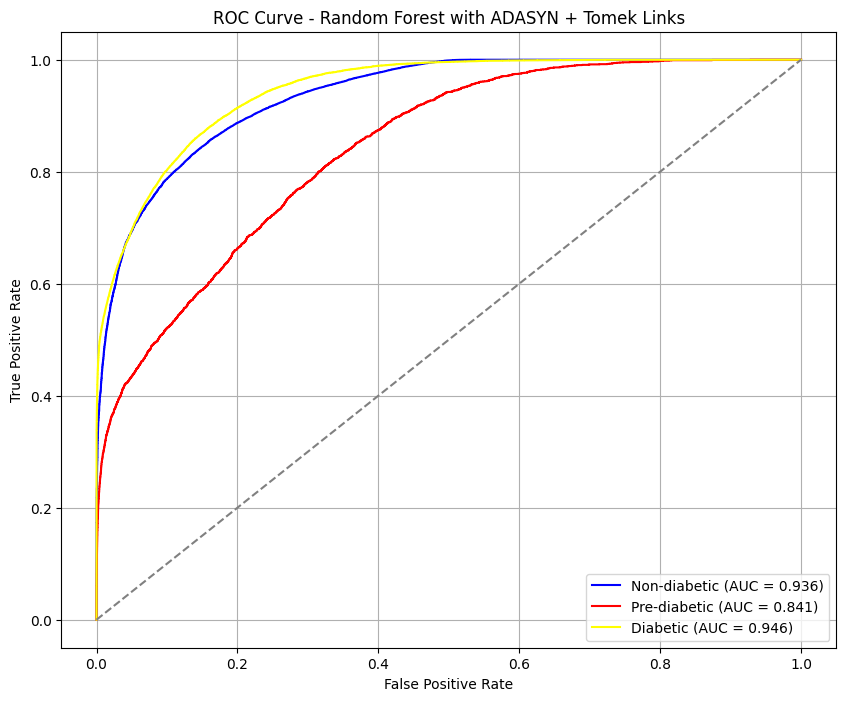

In [79]:
# Plot ROC and AUC of Random Forest model with ADASYN + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_tomek_class_probabilities["RandomForest"],
    model_name="Random Forest with ADASYN + Tomek Links"
)

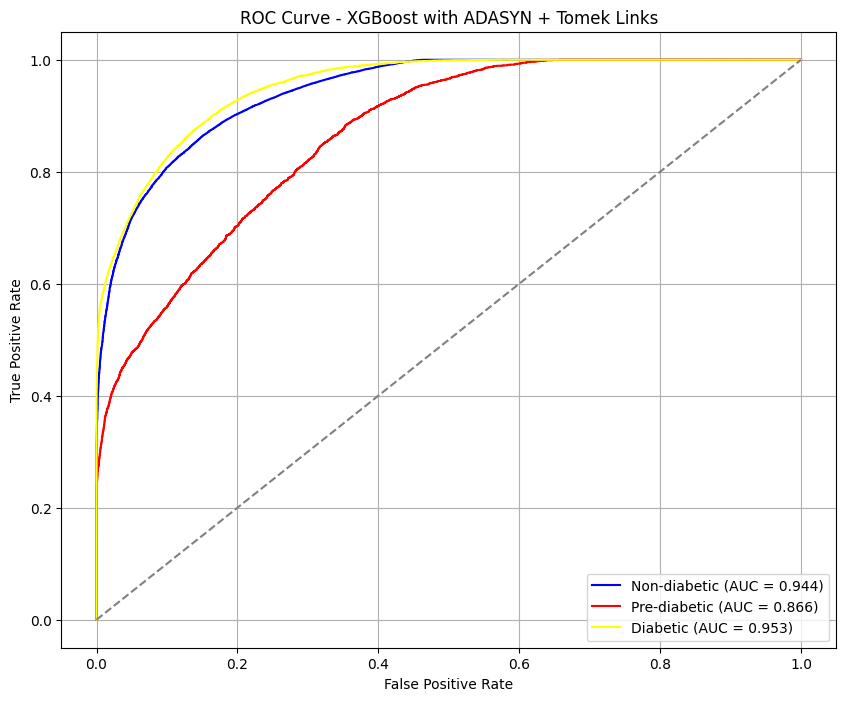

In [80]:
# Plot ROC and AUC of XGBoost model with ADASYN + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_tomek_class_probabilities["XGBoost"],
    model_name="XGBoost with ADASYN + Tomek Links"
)

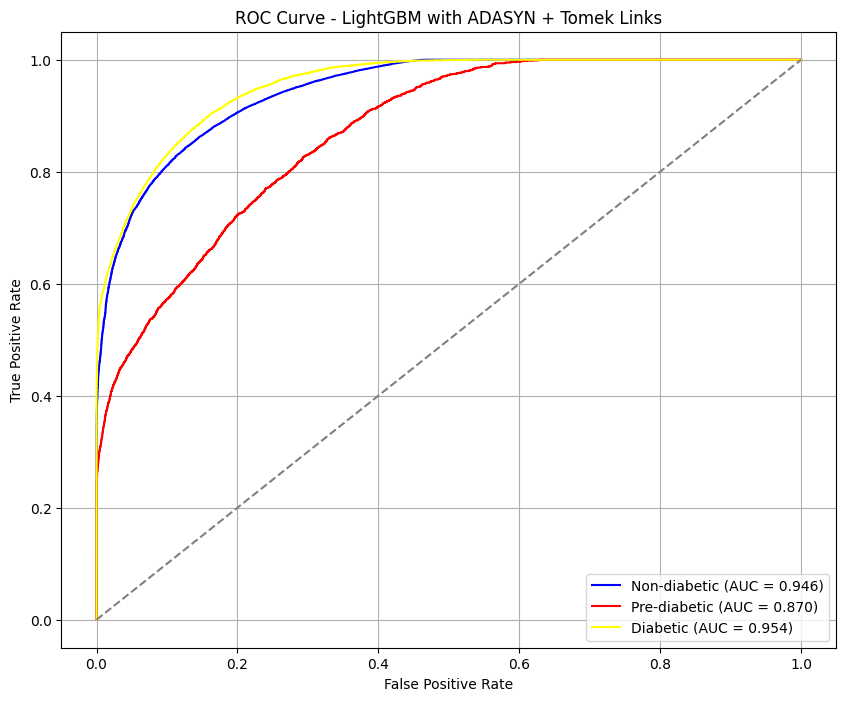

In [81]:
# Plot ROC and AUC of LightGBM model with ADASYN + Tomek Links method
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=adasyn_tomek_class_probabilities["LightGBM"],
    model_name="LightGBM with ADASYN + Tomek Links"
)

## **3. Performance visualization**


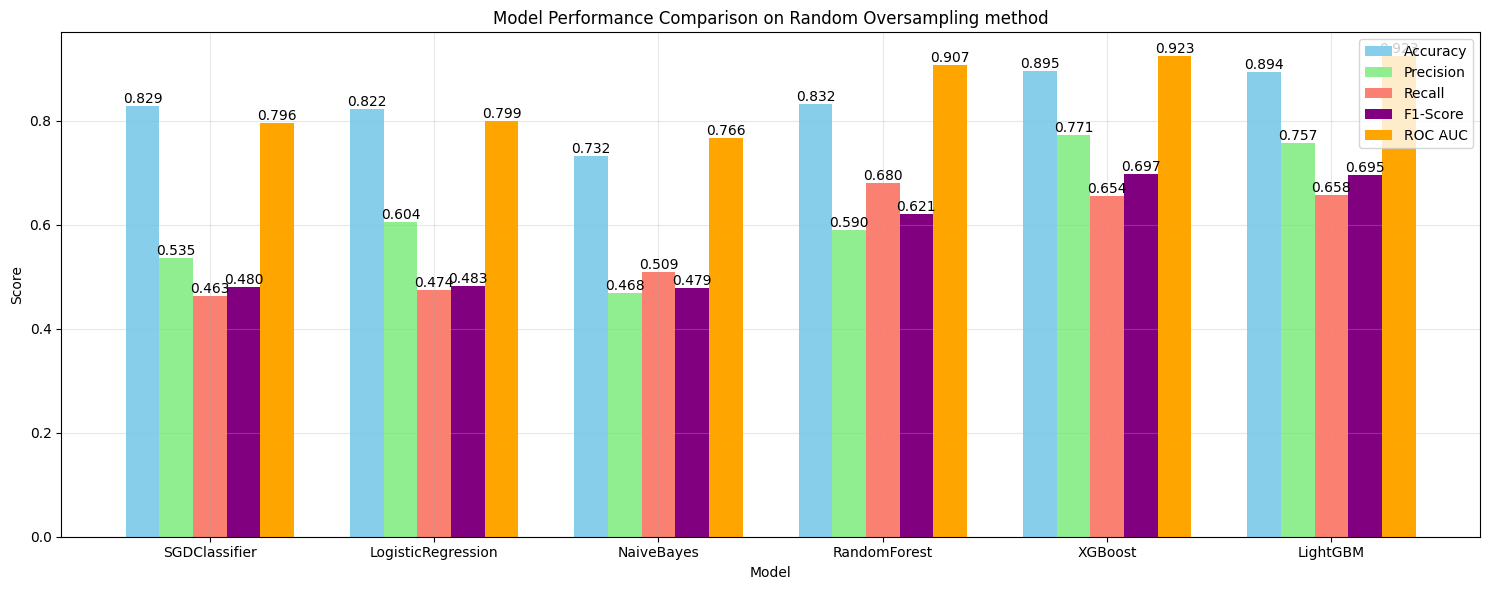

In [82]:
# Plot comprehensive comparison of models with Random Oversampling
plot_compare_models(comparison_df=ros_evaluation_results, title="Model Performance Comparison on Random Oversampling method")

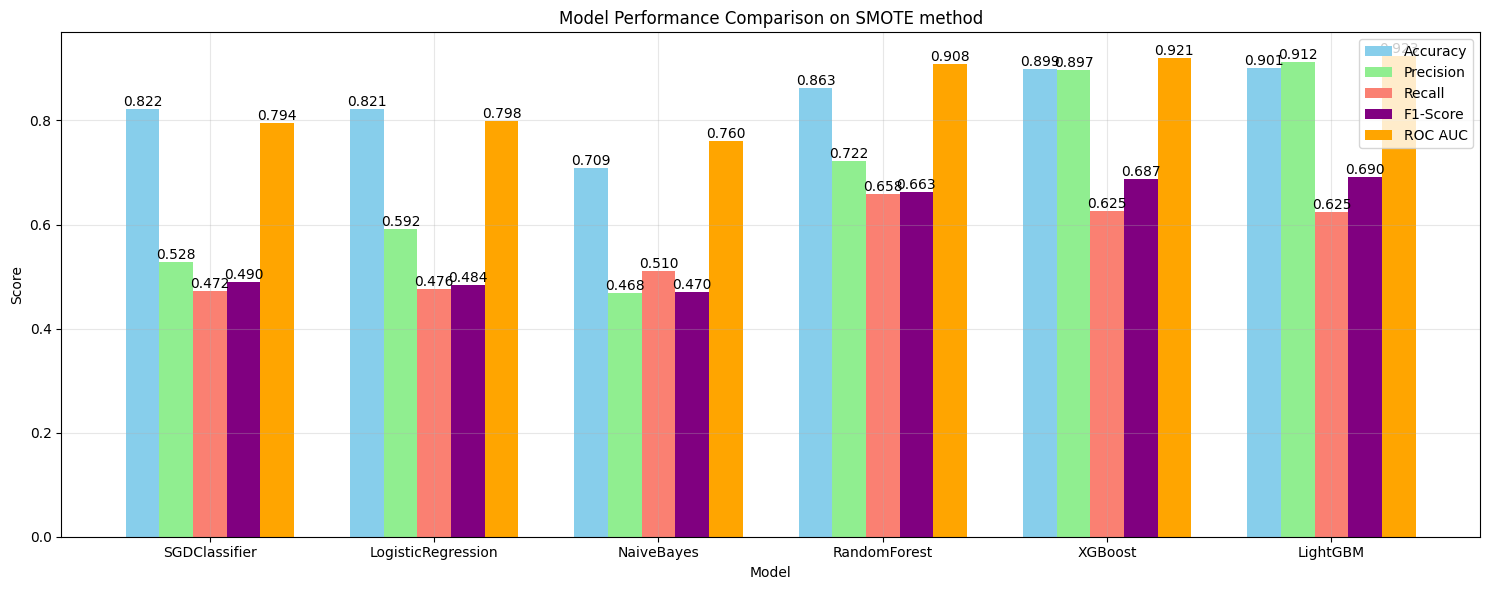

In [83]:
# Plot comprehensive comparison of models with SMOTE
plot_compare_models(comparison_df=smote_evaluation_results, title="Model Performance Comparison on SMOTE method")

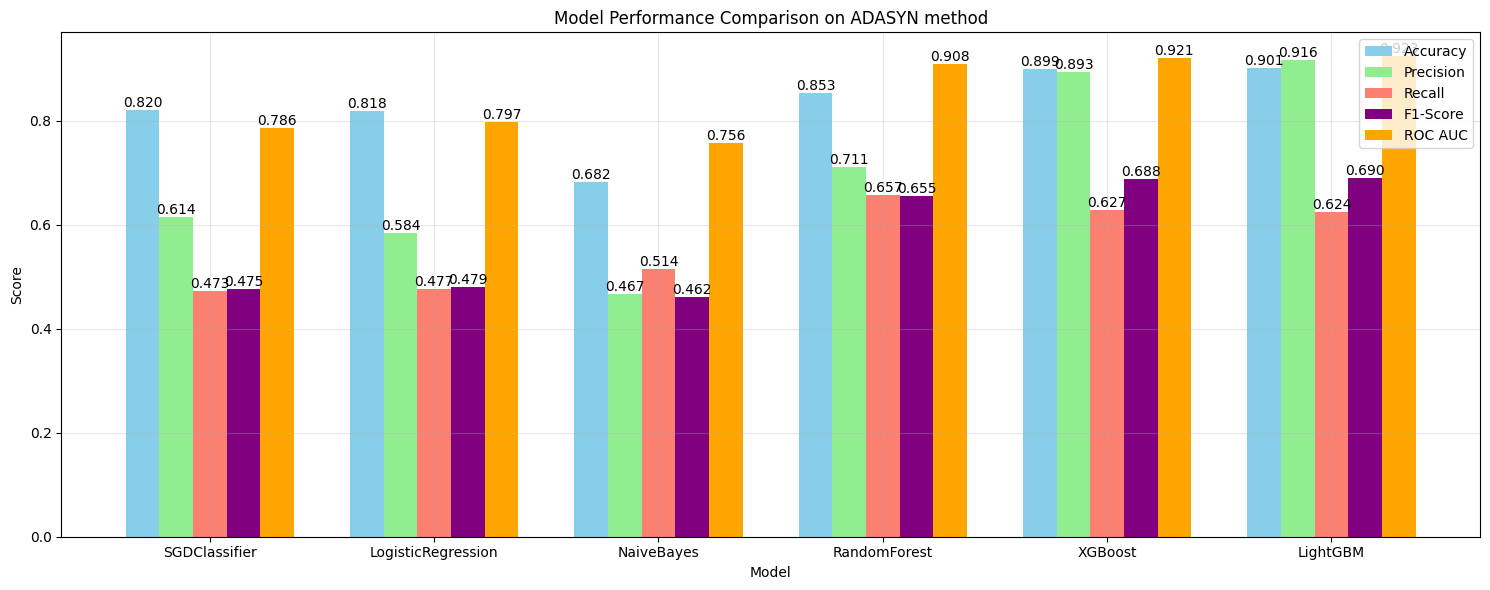

In [84]:
# Plot comprehensive comparison of models with ADASYN
plot_compare_models(comparison_df=adasyn_evaluation_results, title="Model Performance Comparison on ADASYN method")

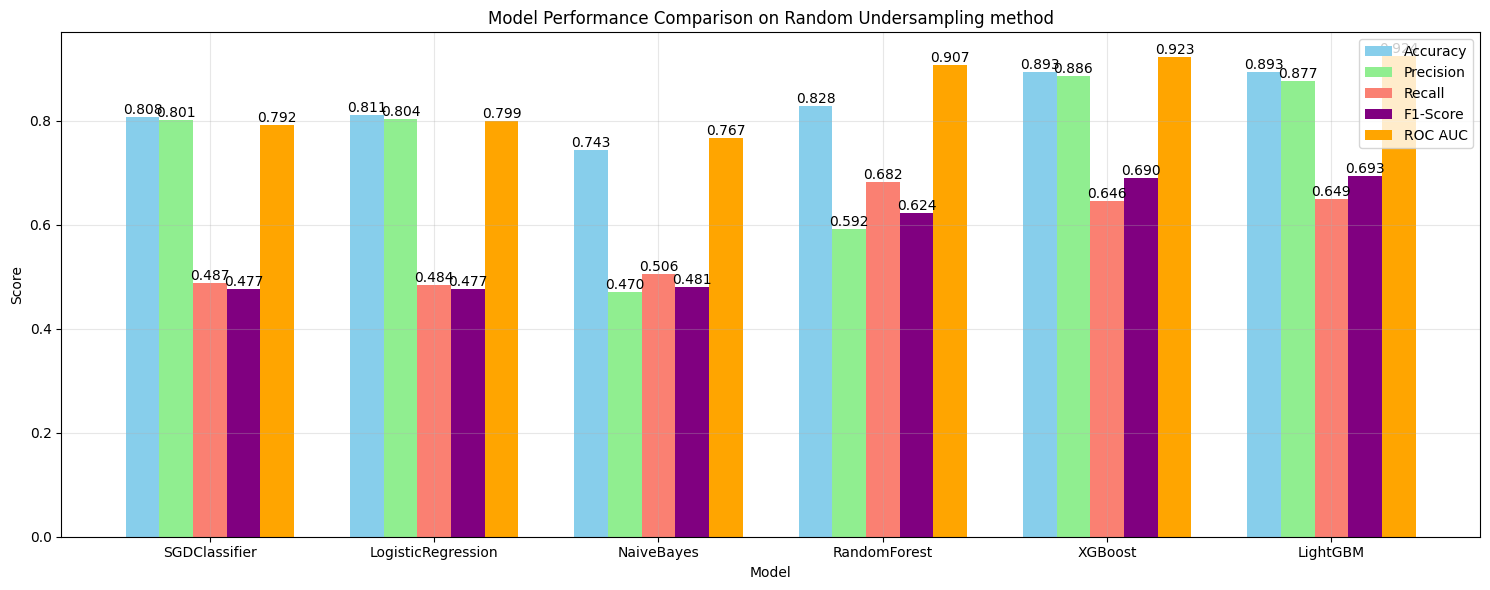

In [85]:
# Plot comprehensive comparison of models with Random Under Sampling
plot_compare_models(comparison_df=rus_evaluation_results, title="Model Performance Comparison on Random Undersampling method")

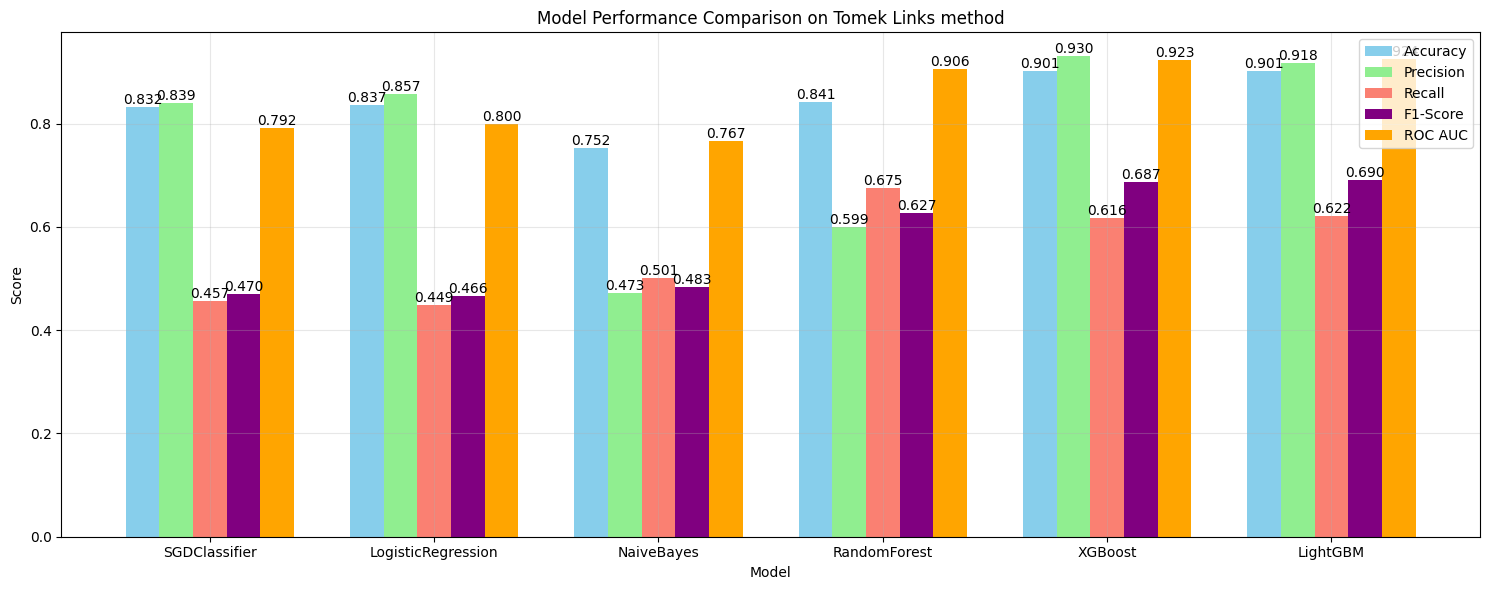

In [86]:
# Plot comprehensive comparison of models with Tomek Links
plot_compare_models(comparison_df=tomek_evaluation_results, title="Model Performance Comparison on Tomek Links method")

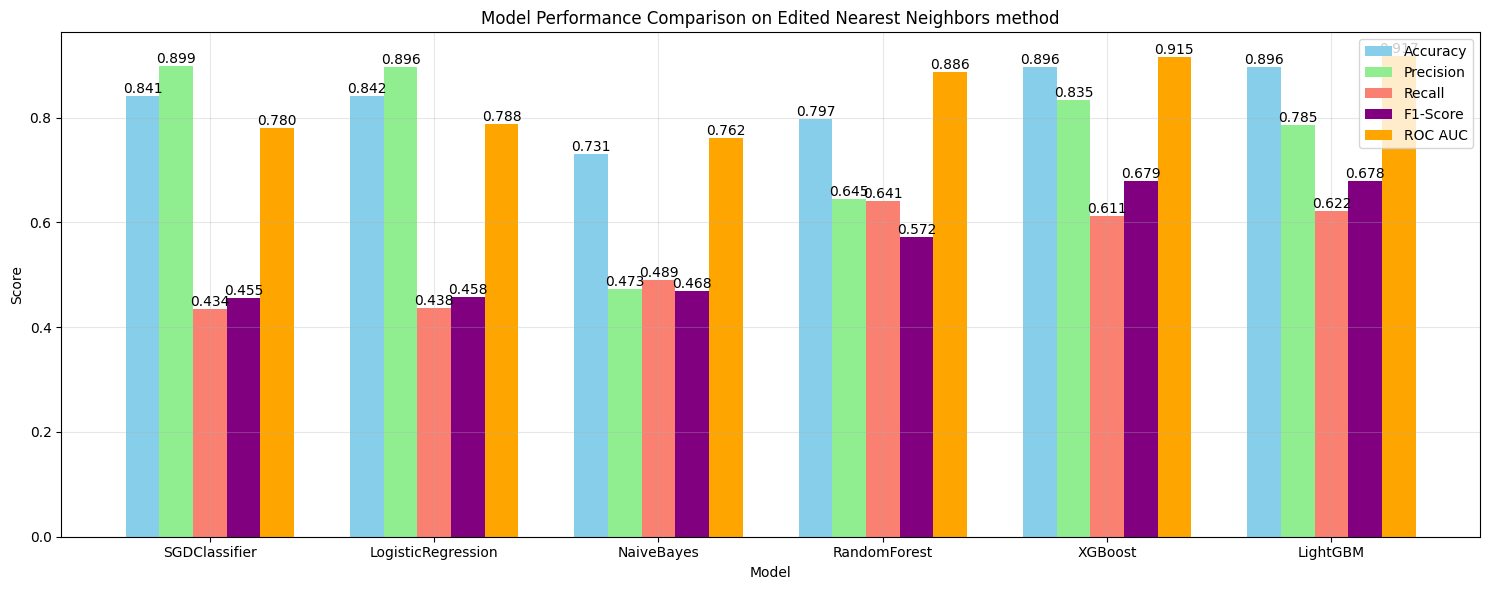

In [87]:
# Plot comprehensive comparison of models with Edited Nearest Neighbors
plot_compare_models(comparison_df=enn_evaluation_results, title="Model Performance Comparison on Edited Nearest Neighbors method")

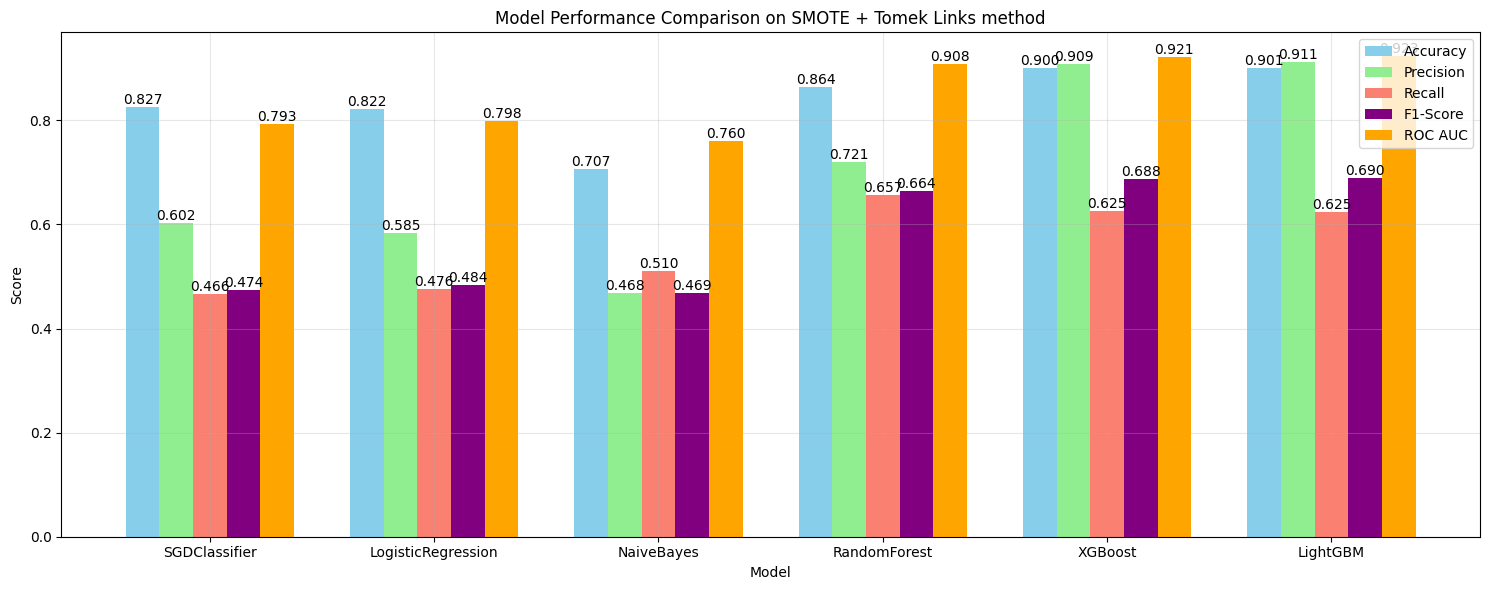

In [88]:
# Plot comprehensive comparison of models with SMOTE + Tomek Links
plot_compare_models(comparison_df=smote_tomek_evaluation_results, title="Model Performance Comparison on SMOTE + Tomek Links method")

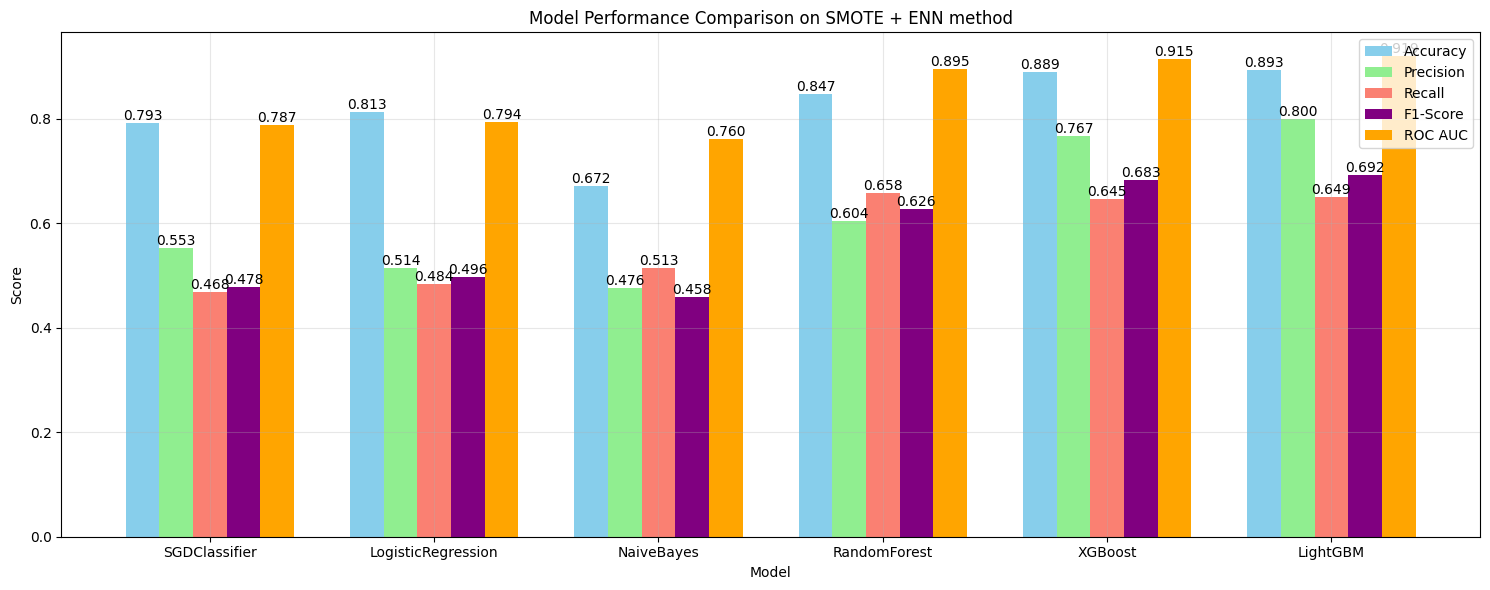

In [89]:
# Plot comprehensive comparison of models with SMOTE + ENN
plot_compare_models(comparison_df=smote_enn_evaluation_results, title="Model Performance Comparison on SMOTE + ENN method")

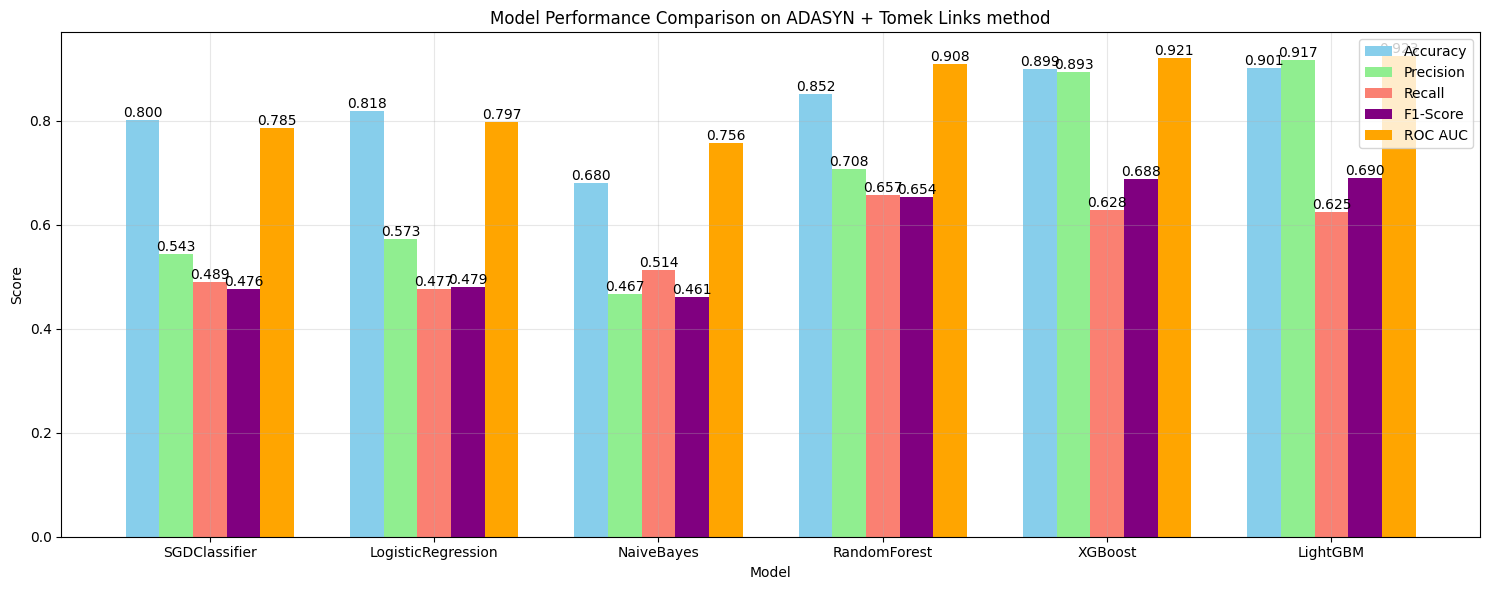

In [90]:
# Plot comprehensive comparison of models with ADASYN + Tomek Links
plot_compare_models(comparison_df=adasyn_tomek_evaluation_results, title="Model Performance Comparison on ADASYN + Tomek Links method")

## **4. Comprehensive evaluation**

In [91]:
ros_evaluation_results["Method"] = "Random Oversampling"
smote_evaluation_results["Method"] = "SMOTE"
rus_evaluation_results["Method"] = "Random Undersampling"
tomek_evaluation_results["Method"] = "Tomek Links"
smote_tomek_evaluation_results["Method"] = "SMOTE + Tomek Links"
smote_enn_evaluation_results["Method"] = "SMOTE + ENN"

comparison_df = pd.concat([
    ros_evaluation_results,
    smote_evaluation_results,
    rus_evaluation_results,
    tomek_evaluation_results,
    smote_tomek_evaluation_results,
    smote_enn_evaluation_results
], ignore_index=True)

In [92]:
best_accuracy = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
best_f1      = comparison_df.loc[comparison_df['F1-Score'].idxmax()]
best_recall  = comparison_df.loc[comparison_df['Recall'].idxmax()]
best_precision = comparison_df.loc[comparison_df['Precision'].idxmax()]

In [93]:
best_overall = comparison_df.loc[comparison_df['F1-Score'].idxmax()]
print(f"RECOMMENDED MODEL: {best_overall['Model']} with {best_overall['Method']}")
print(f" - Accuracy: {best_overall['Accuracy']:.4f}")
print(f" - Precision: {best_overall['Precision']:.4f}")
print(f" - Recall: {best_overall['Recall']:.4f}")
print(f" - F1-Score: {best_overall['F1-Score']:.4f}")

RECOMMENDED MODEL: XGBoost with Random Oversampling
 - Accuracy: 0.8947
 - Precision: 0.7715
 - Recall: 0.6542
 - F1-Score: 0.6969


In [94]:
print(f"Best Accuracy: {best_accuracy['Model']} with {best_accuracy['Method']} - {best_accuracy['Accuracy']:.4f}")
print(f"Best F1-Score: {best_f1['Model']} with {best_f1['Method']} - {best_f1['F1-Score']:.4f}")
print(f"Best Recall: {best_recall['Model']} with {best_recall['Method']} - {best_recall['Recall']:.4f}")
print(f"Best Precision: {best_precision['Model']} with {best_precision['Method']} - {best_precision['Precision']:.4f}")

Best Accuracy: XGBoost with Tomek Links - 0.9012
Best F1-Score: XGBoost with Random Oversampling - 0.6969
Best Recall: RandomForest with Random Undersampling - 0.6821
Best Precision: XGBoost with Tomek Links - 0.9300


## **5. Save the best models**

In [99]:
# Save the scaler and model have the best accuracy
save_data(
    path=BEST_ACCURACY_MODEL_SCALER_FILE_PATH,
    data=tomek_scaler
)
tomek_models["XGBoost"].save_model(model_path=BEST_ACCURACY_MODEL_FILE_PATH)

2025-09-27 23:37:04,677 - [tomek_links.xgboost] - INFO - Model saved successfully to: .../artifacts/models/best_accuracy_model.pkl


In [100]:
# Save the scaler and model have the best F1-score
save_data(
    path=BEST_F1_MODEL_SCALER_FILE_PATH,
    data=ros_scaler
)
ros_models["XGBoost"].save_model(model_path=BEST_F1_MODEL_FILE_PATH)

2025-09-27 23:37:15,771 - [random_oversampling.xgboost] - INFO - Model saved successfully to: .../artifacts/models/best_f1_model.pkl


In [101]:
# Save the scaler and model have the best recall
save_data(
    path=BEST_RECALL_MODEL_SCALER_FILE_PATH,
    data=rus_scaler
)
rus_models["RandomForest"].save_model(model_path=BEST_RECALL_MODEL_FILE_PATH)

2025-09-27 23:37:23,389 - [random_undersampling.random_forest] - INFO - Model saved successfully to: .../artifacts/models/best_recall_model.pkl


In [102]:
# Save the scaler and model have the best precision
save_data(
    path=BEST_PRECISION_MODEL_SCALER_FILE_PATH,
    data=tomek_scaler
)
tomek_models["XGBoost"].save_model(model_path=BEST_PRECISION_MODEL_FILE_PATH)

2025-09-27 23:37:38,370 - [tomek_links.xgboost] - INFO - Model saved successfully to: .../artifacts/models/best_precision_model.pkl
